# Predicting User Tolerance Thresholds for Chatbot Failure in Machine-Human Handoff

**Walsh College -- QM640 Data Analytics Capstone**

This notebook presents the complete analysis of the MHCH-DAMI dataset (Liu et al., 2020) to investigate user tolerance thresholds for chatbot failure and predict the need for machine-human handoff.

**Research Questions:**
- **RQ1:** Do chatbot failure rates before handoff differ between clothing and makeup domains?
- **RQ2:** Can we predict transferability using machine learning models (LR, RF, XGBoost, LSTM)?
- **RQ3:** Which features are the strongest predictors of user frustration?
- **RQ4:** How does transferability distribute temporally across dialogue turns?

**Dataset:** MHCH-DAMI -- 7,500 labeled dialogues (3,500 clothing, 4,000 makeup) with per-utterance features including sentiment, POS tags, term frequency, and binary handoff labels.

## 1. Introduction and Setup

### 1.1 Install Dependencies

Run the cell below to install all required packages. This notebook is designed for Google Colab.

In [1]:
# Install all required packages for the analysis
!pip install pandas numpy scikit-learn matplotlib seaborn shap xgboost lifelines tensorflow statsmodels scipy imbalanced-learn

# Output: Installation logs for each package

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 6.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=4cb00bb0ea0a398c99799a4a74f07ef4b6eef91256f83591c6d044ec7eeab724
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


### 1.2 Import Libraries

In [2]:
import os, sys, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Statistical testing
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, chi2_contingency, pearsonr, spearmanr

# Machine Learning
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

# XGBoost
import xgboost as xgb

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# SHAP for model interpretability
import shap

# Survival Analysis
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Settings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully.')
print(f'Python version: {sys.version}')
print(f'TensorFlow version: {tf.__version__}')
# Output: Library versions and success message

All libraries imported successfully.
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow version: 2.20.0


### 1.3 Clone the MHCH-DAMI Repository

In [3]:
# Clone the MHCH-DAMI dataset repository
REPO_URL = 'https://github.com/LauJames/MHCH-DAMI.git'
DATA_DIR = 'MHCH-DAMI'

if not os.path.exists(DATA_DIR):
    !git clone {REPO_URL}
    print('Repository cloned successfully.')
else:
    print('Repository already exists.')

!ls -la {DATA_DIR}/
# Output: Directory listing of the MHCH-DAMI repository

Cloning into 'MHCH-DAMI'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 79 (delta 13), reused 12 (delta 12), pack-reused 61 (from 1)
Receiving objects: 100% (79/79), 19.04 MiB | 15.03 MiB/s, done.
Resolving deltas: 100% (26/26), done.
Repository cloned successfully.
total 492
drwxr-xr-x 6 root root   4096 Jul 28 16:41 .
drwxr-xr-x 1 root root   4096 Jul 28 16:41 ..
drwxr-xr-x 4 root root   4096 Jul 28 16:41 config
drwxr-xr-x 4 root root   4096 Jul 28 16:41 data
-rw-r--r-- 1 root root   9373 Jul 28 16:41 data_loader.py
-rw-r--r-- 1 root root  13590 Jul 28 16:41 data_prepare.py
-rw-r--r-- 1 root root 267873 Jul 28 16:41 exemplar.png
drwxr-xr-x 8 root root   4096 Jul 28 16:41 .git
-rw-r--r-- 1 root root     87 Jul 28 16:41 .gitignore
-rw-r--r-- 1 root root  85075 Jul 28 16:41 gtt_plot.pdf
-rw-r--r-- 1 root root      0 Jul 28 16:41 __init__.py
-rw-r--r-- 1 root root   7966 Jul 28 16:41 mai

## 2. Data Loading and Parsing

### 2.1 Understanding the Dataset Structure

The MHCH-DAMI dataset uses pickle files containing per-utterance features for each dialogue. Each utterance record includes:
- **Content**: Word IDs (desensitized Chinese text)
- **Role**: Speaker role (user vs. agent)
- **Term Frequency**: TF values
- **POS Tags**: Part-of-speech tag sequence
- **Sentiment**: Sentiment polarity scores
- **Utterance Length**: Number of words
- **Dialogue Length**: Total turns in dialogue
- **Label**: Binary handoff label (1=transferable, 0=normal)

In [4]:
# Explore the repository structure to understand data layout
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:10]:
        print(f'{subindent}{file}')
    if len(files) > 10:
        print(f'{subindent}... and {len(files) - 10} more files')
# Output: Tree structure of the MHCH-DAMI repository

MHCH-DAMI/
  __init__.py
  main.py
  requirements.txt
  Network.py
  vocab.py
  utility.py
  gtt_plot.pdf
  README.md
  data_loader.py
  data_prepare.py
  ... and 2 more files
  data/
    makeup/
      eval.pkl
      vocab.pkl
      test.pkl
      train.pkl
    clothing/
      eval.pkl
      vocab.pkl
      test.pkl
      train.pkl
  networks/
    DAMI.py
    layers/
      attention.py
      transformer.py
  .git/
    HEAD
    config
    index
    packed-refs
    description
    objects/
      info/
      pack/
        pack-35e74bbb0e0a3779d5505f32d34144222165c646.pack
        pack-35e74bbb0e0a3779d5505f32d34144222165c646.idx
    info/
      exclude
    refs/
      remotes/
        origin/
          HEAD
      heads/
        main
      tags/
    branches/
    logs/
      HEAD
      refs/
        remotes/
          origin/
            HEAD
        heads/
          main
    hooks/
      fsmonitor-watchman.sample
      pre-receive.sample
      pre-commit.sample
      post-update.sample
  

In [5]:
# Locate the pickle files containing the dialogue data
pickle_files = []
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith(('.pkl', '.pickle', '.pk')):
            pickle_files.append(os.path.join(root, file))

print(f'Found {len(pickle_files)} pickle file(s):')
for f in pickle_files:
    print(f'  - {f}')
# Output: List of all pickle files found

Found 8 pickle file(s):
  - MHCH-DAMI/data/makeup/eval.pkl
  - MHCH-DAMI/data/makeup/vocab.pkl
  - MHCH-DAMI/data/makeup/test.pkl
  - MHCH-DAMI/data/makeup/train.pkl
  - MHCH-DAMI/data/clothing/eval.pkl
  - MHCH-DAMI/data/clothing/vocab.pkl
  - MHCH-DAMI/data/clothing/test.pkl
  - MHCH-DAMI/data/clothing/train.pkl


### 2.2 Load and Parse Pickle Files

The pickle files contain dialogue-level data where each dialogue is a list of utterance records. We parse these into a flat DataFrame for analysis.

In [6]:
def load_pickle_file(filepath):
    """Load a pickle file with Python 2/3 compatibility."""
    try:
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        return data
    except UnicodeDecodeError:
        # Python 2 pickle in Python 3 environment
        with open(filepath, 'rb') as f:
            data = pickle.load(f, encoding='latin1')
        return data
    except Exception as e:
        print(f'Error loading {filepath}: {e}')
        return None

# Load all pickle files
raw_data = {}
for pf in pickle_files:
    data = load_pickle_file(pf)
    if data is not None:
        raw_data[pf] = data
        print(f'Loaded {pf}: type={type(data)}, ', end='')
        if isinstance(data, dict):
            print(f'keys={list(data.keys())[:5]}')
        elif isinstance(data, list):
            print(f'length={len(data)}')
        else:
            print(f'shape={data.shape if hasattr(data, "shape") else "N/A"}')
    else:
        print(f'Failed to load {pf}')

# Output: Loading status for each pickle file

Loaded MHCH-DAMI/data/makeup/eval.pkl: type=<class 'list'>, length=400
Error loading MHCH-DAMI/data/makeup/vocab.pkl: No module named 'vocab'
Failed to load MHCH-DAMI/data/makeup/vocab.pkl
Loaded MHCH-DAMI/data/makeup/test.pkl: type=<class 'list'>, length=400
Loaded MHCH-DAMI/data/makeup/train.pkl: type=<class 'list'>, length=3200
Loaded MHCH-DAMI/data/clothing/eval.pkl: type=<class 'list'>, length=350
Error loading MHCH-DAMI/data/clothing/vocab.pkl: No module named 'vocab'
Failed to load MHCH-DAMI/data/clothing/vocab.pkl
Loaded MHCH-DAMI/data/clothing/test.pkl: type=<class 'list'>, length=350
Loaded MHCH-DAMI/data/clothing/train.pkl: type=<class 'list'>, length=2800


In [7]:
# Inspect the structure of the first loaded dataset
sample_key = list(raw_data.keys())[0]
sample_data = raw_data[sample_key]

print(f'Inspecting: {sample_key}')
print(f'Type: {type(sample_data)}')

if isinstance(sample_data, dict):
    first_key = list(sample_data.keys())[0]
    first_val = sample_data[first_key]
    print(f'First key: {first_key}')
    print(f'First value type: {type(first_val)}')
    if isinstance(first_val, list) and len(first_val) > 0:
        print(f'First element type: {type(first_val[0])}')
        if isinstance(first_val[0], dict):
            print(f'First element keys: {list(first_val[0].keys())}')
            for k, v in first_val[0].items():
                vtype = type(v).__name__
                if isinstance(v, (list, tuple)):
                    print(f'  {k}: type={vtype}, len={len(v)}, sample={v[:3]}')
                else:
                    print(f'  {k}: type={vtype}, value={v}')
elif isinstance(sample_data, list):
    print(f'Length: {len(sample_data)}')
    if len(sample_data) > 0:
        print(f'First element type: {type(sample_data[0])}')
        if isinstance(sample_data[0], dict):
            print(f'First element keys: {list(sample_data[0].keys())}')
            print(f'First element: {sample_data[0]}')
        elif isinstance(sample_data[0], (list, tuple)):
            print(f'First element: {sample_data[0]}')
# Output: Structure inspection of the raw dataset

Inspecting: MHCH-DAMI/data/makeup/eval.pkl
Type: <class 'list'>
Length: 400
First element type: <class 'numpy.ndarray'>


In [8]:
def parse_dialogues_to_dataframe(raw_data, domain_label):
    """
    Parse dialogue data from pickle files into a flat DataFrame.

    Parameters:
        raw_data: dict or list of dialogues from pickle file
        domain_label: str, 'clothing' or 'makeup'

    Returns:
        pd.DataFrame with one row per utterance
    """
    records = []

    # Normalize to list of dialogues
    if isinstance(raw_data, dict):
        dialogues = list(raw_data.values())
    elif isinstance(raw_data, list):
        dialogues = raw_data
    else:
        print(f'Unexpected data type: {type(raw_data)}')
        return pd.DataFrame()

    for dial_idx, dialogue in enumerate(dialogues):
        # Determine utterances
        if isinstance(dialogue, dict):
            utterances = list(dialogue.values())
        elif isinstance(dialogue, (list, tuple)):
            utterances = dialogue
        else:
            continue

        num_turns = len(utterances)

        for turn_idx, utt in enumerate(utterances):
            record = {
                'dialogue_id': dial_idx,
                'domain': domain_label,
                'turn_index': turn_idx,
                'dialogue_length': num_turns
            }

            if isinstance(utt, dict):
                for key, val in utt.items():
                    record[str(key)] = val
            elif isinstance(utt, (list, tuple)):
                field_map = [
                    'content', 'role', 'term_freq', 'pos_tags',
                    'sentiment', 'utterance_length', 'label'
                ]
                for i, fname in enumerate(field_map):
                    if i < len(utt):
                        record[fname] = utt[i]

            records.append(record)

    df = pd.DataFrame(records)
    print(f'Parsed {domain_label} domain: {len(dialogues)} dialogues, {len(df)} utterances')
    return df

# Parse each pickle file into DataFrames
dataframes = []

for filepath, data in raw_data.items():
    filename = os.path.basename(filepath).lower()
    if 'cloth' in filename or 'dress' in filename:
        domain = 'clothing'
    elif 'make' in filename or 'beauty' in filename:
        domain = 'makeup'
    else:
        # Assign based on file order: first file = clothing, second = makeup
        domain = 'clothing' if len(dataframes) == 0 else 'makeup'
        print(f'Warning: Could not determine domain for {filepath}, assigned: {domain}')

    df = parse_dialogues_to_dataframe(data, domain)
    if not df.empty:
        dataframes.append(df)

# Combine all DataFrames
if dataframes:
    df_all = pd.concat(dataframes, ignore_index=True)
    print(f'\nCombined dataset: {len(df_all)} utterances from {df_all["dialogue_id"].nunique()} dialogues')
else:
    print('No data loaded. Check the data loading steps above.')
    df_all = pd.DataFrame()

# Output: Dataset dimensions and summary

Parsed clothing domain: 400 dialogues, 0 utterances
Parsed clothing domain: 400 dialogues, 0 utterances
Parsed clothing domain: 3200 dialogues, 0 utterances
Parsed clothing domain: 350 dialogues, 0 utterances
Parsed clothing domain: 350 dialogues, 0 utterances
Parsed clothing domain: 2800 dialogues, 0 utterances
No data loaded. Check the data loading steps above.


### 2.3 Verify Data Structure and Handle Alternative Formats

Below we handle alternative pickle formats and ensure we have a consistent DataFrame with standardized column names.

In [9]:
# Read README for data format details
readme_paths = [
    os.path.join(DATA_DIR, 'README.md'),
    os.path.join(DATA_DIR, 'README.rst'),
    os.path.join(DATA_DIR, 'README.txt'),
    os.path.join(DATA_DIR, 'README'),
]

for rp in readme_paths:
    if os.path.exists(rp):
        print(f'=== {rp} ===')
        with open(rp, 'r', encoding='utf-8', errors='replace') as f:
            print(f.read()[:3000])
        print()
# Output: README contents showing data format documentation

=== MHCH-DAMI/README.md ===
# Machine-Human Chatting Handoff
Tensorflow implementation of the AAAI-2021 paper: [Time to Transfer: Predicting and Evaluating Machine-Human Chatting Handoff](https://arxiv.org/pdf/2012.07610.pdf)

<div align=center><img src="./exemplar.png" height="500"/></div>

## Requirements

* Python 3.6 or higher
* tensorflow=1.14
* Keras==2.2.5
* tqdm==4.35.0
* jieba==0.39
* gensim==3.8.3
* snownlp==0.12.3

## Environment

* Tesla V100 16GB GPU
* CUDA 10.2

## Data Example
```
C2B: *产品链接* 	(*URL of a product*)	[Normal]
C2B: 买二送一。	(Buy two free one.)	[Normal]
B2C: 亲亲您可以直接拍下您喜欢的(同一链接内)的3双加入购物车,付款的时候系统会在的减价的哦~ 	(Dear,  you can add your favorite three goods to shopping cart directly. The system will cut the price automatically when you pay! )	[Normal]
C2B: 买的时候怎么一下买三条？	(How to buy three goods at once? )	[Normal]
B2C: 亲亲，活动页面会有具体介绍若有满三减一活动的，直接拍下三双系统会自动立减的建议按现有的颜色组合拍。	(Dear, there will be a specific introduction on the detail page. If we have buy-two-free-one promotions, t

In [10]:
# Deep inspection of each pickle file for structure verification
def deep_inspect_pickle(filepath):
    data = load_pickle_file(filepath)
    if data is None:
        return
    print(f'\n=== Inspection of {filepath} ===')
    print(f'Top-level type: {type(data)}')

    if isinstance(data, dict):
        print(f'Number of keys: {len(data)}')
        print(f'Sample keys (first 5): {list(data.keys())[:5]}')
        first_key = list(data.keys())[0]
        val = data[first_key]
        print(f'Value type for first key: {type(val)}')
        if isinstance(val, list) and len(val) > 0:
            print(f'  First element type: {type(val[0])}')
            if isinstance(val[0], dict):
                print(f'  First element keys: {list(val[0].keys())}')
                for k, v in val[0].items():
                    if isinstance(v, (list, tuple)):
                        print(f'    {k}: type=list, len={len(v)}, sample={v[:3]}')
                    elif isinstance(v, (int, float, str, bool)):
                        print(f'    {k}: type={type(v).__name__}, value={v}')
                    elif hasattr(v, 'shape'):
                        print(f'    {k}: type=ndarray, shape={v.shape}')
                    else:
                        print(f'    {k}: type={type(v).__name__}, value={str(v)[:100]}')
    elif isinstance(data, list):
        print(f'Length: {len(data)}')
        if len(data) > 0:
            print(f'First element type: {type(data[0])}')
            if isinstance(data[0], dict):
                print(f'First element keys: {list(data[0].keys())}')
            elif isinstance(data[0], (list, tuple)):
                print(f'First element: {data[0]}')

for pf in pickle_files:
    deep_inspect_pickle(pf)
# Output: Detailed structure of each pickle file


=== Inspection of MHCH-DAMI/data/makeup/eval.pkl ===
Top-level type: <class 'list'>
Length: 400
First element type: <class 'numpy.ndarray'>
Error loading MHCH-DAMI/data/makeup/vocab.pkl: No module named 'vocab'

=== Inspection of MHCH-DAMI/data/makeup/test.pkl ===
Top-level type: <class 'list'>
Length: 400
First element type: <class 'numpy.ndarray'>

=== Inspection of MHCH-DAMI/data/makeup/train.pkl ===
Top-level type: <class 'list'>
Length: 3200
First element type: <class 'numpy.ndarray'>

=== Inspection of MHCH-DAMI/data/clothing/eval.pkl ===
Top-level type: <class 'list'>
Length: 350
First element type: <class 'numpy.ndarray'>
Error loading MHCH-DAMI/data/clothing/vocab.pkl: No module named 'vocab'

=== Inspection of MHCH-DAMI/data/clothing/test.pkl ===
Top-level type: <class 'list'>
Length: 350
First element type: <class 'numpy.ndarray'>

=== Inspection of MHCH-DAMI/data/clothing/train.pkl ===
Top-level type: <class 'list'>
Length: 2800
First element type: <class 'numpy.ndarray'>


In [11]:
import numpy as np

# Final comprehensive data loader
def load_mhch_dami(pickle_files):
    """
    Load the MHCH-DAMI dataset from pickle files.
    Handles multiple possible data structures.

    Returns:
        pd.DataFrame with standardized columns
    """
    all_records = []
    global_dialogue_counter = 0 # Initialize a counter for unique dialogue IDs

    for filepath in pickle_files:
        data = load_pickle_file(filepath)
        if data is None:
            continue

        # Determine domain from filepath more robustly
        if 'clothing' in filepath.lower():
            domain = 'clothing'
        elif 'makeup' in filepath.lower():
            domain = 'makeup'
        else:
            print(f"Warning: Could not determine domain for {filepath}. Skipping.")
            continue # Skip files where domain cannot be determined

        # Normalize to list of dialogues
        if isinstance(data, dict):
            dialogues = list(data.values())
        # Crucial fix: Added np.ndarray to handle cases where data is a list of numpy arrays
        elif isinstance(data, (list, np.ndarray)):
            dialogues = data
        else:
            print(f"Skipping {filepath} due to unexpected top-level data type: {type(data)}")
            continue

        for dial_idx_local, dialogue in enumerate(dialogues): # dial_idx_local for indexing within this file
            # Determine utterances within the dialogue
            if isinstance(dialogue, dict):
                utterances = list(dialogue.values())
            # Crucial fix: Added np.ndarray to handle cases where dialogue is a numpy array of utterances
            elif isinstance(dialogue, (list, tuple, np.ndarray)):
                utterances = dialogue
            else:
                print(f"Skipping dialogue {dial_idx_local} in {filepath} due to unexpected dialogue type: {type(dialogue)}")
                continue

            dialogue_length = len(utterances)

            for turn_idx, utt in enumerate(utterances):
                record = {
                    'dialogue_id': global_dialogue_counter, # Assign unique global ID
                    'domain': domain,
                    'turn_index': turn_idx,
                    'dialogue_length': dialogue_length
                }

                if isinstance(utt, dict):
                    for k, v in utt.items():
                        record[str(k)] = v
                # Crucial fix: Added np.ndarray to handle cases where utt is a 1D numpy array of features
                elif isinstance(utt, (list, tuple, np.ndarray)):
                    # Flatten the numpy array if it's 2D (e.g., (1, N)) to a 1D array
                    utt_flat = utt.flatten() if isinstance(utt, np.ndarray) else utt
                    field_map = [
                        'content', 'role', 'term_freq', 'pos_tags',
                        'sentiment', 'utterance_length', 'label'
                    ]
                    # Assuming utt_flat is a 1D array/list of features
                    for i, fname in enumerate(field_map):
                        if i < len(utt_flat): # Ensure index is within bounds of utt_flat
                            record[fname] = utt_flat[i]
                else:
                    print(f"Skipping utterance in {filepath} (dialogue {global_dialogue_counter}, turn {turn_idx}) due to unexpected utterance type: {type(utt)}")
                    continue
                all_records.append(record)
            global_dialogue_counter += 1 # Increment for each dialogue processed

        print(f'Loaded and parsed {filepath} as {domain} domain, containing {len(dialogues)} dialogues.')

    df = pd.DataFrame(all_records)
    # The dialogue_id column should now be correctly populated with unique integer IDs.
    print(f'\nTotal: {df["dialogue_id"].nunique()} unique dialogues, {len(df)} utterances overall.')
    print(f'Columns: {list(df.columns)}')
    return df

df_all = load_mhch_dami(pickle_files)
print(f'\nDataset shape: {df_all.shape}')
print(f'\nFirst few rows:')
print(df_all.head())

Loaded and parsed MHCH-DAMI/data/makeup/eval.pkl as makeup domain, containing 400 dialogues.
Error loading MHCH-DAMI/data/makeup/vocab.pkl: No module named 'vocab'
Loaded and parsed MHCH-DAMI/data/makeup/test.pkl as makeup domain, containing 400 dialogues.
Loaded and parsed MHCH-DAMI/data/makeup/train.pkl as makeup domain, containing 3200 dialogues.
Loaded and parsed MHCH-DAMI/data/clothing/eval.pkl as clothing domain, containing 350 dialogues.
Error loading MHCH-DAMI/data/clothing/vocab.pkl: No module named 'vocab'
Loaded and parsed MHCH-DAMI/data/clothing/test.pkl as clothing domain, containing 350 dialogues.
Loaded and parsed MHCH-DAMI/data/clothing/train.pkl as clothing domain, containing 2800 dialogues.

Total: 7500 unique dialogues, 75548 utterances overall.
Columns: ['dialogue_id', 'domain', 'turn_index', 'dialogue_length', 'content', 'role', 'term_freq', 'pos_tags', 'sentiment', 'utterance_length', 'label']

Dataset shape: (75548, 11)

First few rows:
   dialogue_id  domain  tu

In [12]:
dialogue_pickle_files = [f for f in pickle_files if 'vocab.pkl' not in f]

print(f'Loading {len(dialogue_pickle_files)} dialogue data pickle files (excluding vocab.pkl files):')
for f in dialogue_pickle_files:
    print(f'  - {f}')

df_all = load_mhch_dami(dialogue_pickle_files)
print(f'\nDataset shape: {df_all.shape}')
print(f'\nFirst few rows:')
print(df_all.head())

Loading 6 dialogue data pickle files (excluding vocab.pkl files):
  - MHCH-DAMI/data/makeup/eval.pkl
  - MHCH-DAMI/data/makeup/test.pkl
  - MHCH-DAMI/data/makeup/train.pkl
  - MHCH-DAMI/data/clothing/eval.pkl
  - MHCH-DAMI/data/clothing/test.pkl
  - MHCH-DAMI/data/clothing/train.pkl
Loaded and parsed MHCH-DAMI/data/makeup/eval.pkl as makeup domain, containing 400 dialogues.
Loaded and parsed MHCH-DAMI/data/makeup/test.pkl as makeup domain, containing 400 dialogues.
Loaded and parsed MHCH-DAMI/data/makeup/train.pkl as makeup domain, containing 3200 dialogues.
Loaded and parsed MHCH-DAMI/data/clothing/eval.pkl as clothing domain, containing 350 dialogues.
Loaded and parsed MHCH-DAMI/data/clothing/test.pkl as clothing domain, containing 350 dialogues.
Loaded and parsed MHCH-DAMI/data/clothing/train.pkl as clothing domain, containing 2800 dialogues.

Total: 7500 unique dialogues, 75548 utterances overall.
Columns: ['dialogue_id', 'domain', 'turn_index', 'dialogue_length', 'content', 'role'

### 2.4 Column Mapping and Standardization

The raw column names may vary depending on how the pickle was serialized. We standardize them below.

In [13]:
# Map raw column names to standardized names
column_mapping = {}

mapping_rules = {
    'label': ['label', 'tag', 'transferable', 'handoff', 'hand_off', 'target'],
    'role': ['role', 'speaker', 'sender', 'agent_flag'],
    'sentiment': ['sentiment', 'sent', 'sentiment_score', 'emotion'],
    'pos_tags': ['pos', 'pos_tags', 'pos_tag', 'pos_seq'],
    'term_freq': ['tf', 'term_freq', 'tfidf', 'frequency'],
    'utterance_length': ['utt_len', 'utterance_length', 'sent_len', 'length', 'utt_length'],
    'content': ['content', 'word', 'words', 'text', 'word_ids', 'sentence'],
}

for std_name, variations in mapping_rules.items():
    for col in df_all.columns:
        if col.lower() in [v.lower() for v in variations]:
            if col != std_name and std_name not in column_mapping.values():
                column_mapping[col] = std_name
                break

df_all = df_all.rename(columns=column_mapping)

print('Column mapping applied:')
for old, new in column_mapping.items():
    print(f'  {old} -> {new}')

print(f'\nFinal columns: {list(df_all.columns)}')
print(f'Dataset shape: {df_all.shape}')
# Output: Column mapping results and final column list

Column mapping applied:

Final columns: ['dialogue_id', 'domain', 'turn_index', 'dialogue_length', 'content', 'role', 'term_freq', 'pos_tags', 'sentiment', 'utterance_length', 'label']
Dataset shape: (75548, 11)


## 3. Exploratory Data Analysis (EDA)

This EDA follows the structured workflow designed in DIGA-76:

1. **Load Dataset** -> 2. **Summary Statistics** -> 3. **Distribution Analysis**
   - Continuous features -> **Shapiro-Wilk Normality Test**
   - Categorical features -> **Frequency Distribution Check**
4. **Skewness Assessment** (non-normal features)
   - |skew| < 1: Keep (real-world count data naturally right-skewed)
   - |skew| >= 1: Treatment decision (log transform vs keep raw)
5. **Outlier Detection** (IQR + Z-score)
6. **Outlier Assessment**: Remove errors | Keep valid extremes | Winsorize borderline
7. **Final Feature Set** -> 8. **Class Balance Check** -> 9. **Stratified Split** -> Proceed to RQ1-RQ4

In [14]:
# Step 1: Compute Summary Statistics per feature
print('=' * 70)
print('STEP 1: SUMMARY STATISTICS PER FEATURE')
print('=' * 70)

# Identify continuous and categorical features
continuous_features = []
categorical_features = []

for col in df_all.columns:
    if col in ['dialogue_id', 'label', 'content', 'pos_tags']:
        continue
    if pd.api.types.is_numeric_dtype(df_all[col]):
        continuous_features.append(col)
    else:
        categorical_features.append(col)

print(f'\nContinuous features ({len(continuous_features)}): {continuous_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

# Summary statistics for continuous features
print('\n--- Continuous Feature Statistics ---')
summary = df_all[continuous_features].describe().T
summary['skewness'] = df_all[continuous_features].skew()
summary['kurtosis'] = df_all[continuous_features].kurtosis()
print(summary.round(3))

# Summary for categorical features
if categorical_features:
    print('\n--- Categorical Feature Statistics ---')
    for col in categorical_features:
        print(f'\n{col}: {df_all[col].nunique()} unique values')
        print(df_all[col].value_counts().head(10))

# Dataset overview
print('\n--- Dataset Overview ---')
print(f'Total utterances: {len(df_all)}')
print(f'Total dialogues: {df_all["dialogue_id"].nunique()}')
print(f'Domains: {df_all["domain"].unique()}')
print(f'Columns: {list(df_all.columns)}')

STEP 1: SUMMARY STATISTICS PER FEATURE

Continuous features (6): ['turn_index', 'dialogue_length', 'role', 'term_freq', 'sentiment', 'utterance_length']
Categorical features (1): ['domain']

--- Continuous Feature Statistics ---
                    count     mean       std  min  25%   50%    75%     max  \
turn_index        75548.0    5.931     5.246  0.0  2.0   5.0    8.0    29.0   
dialogue_length   75548.0   12.863     6.437  5.0  8.0  11.0   17.0    30.0   
role              75548.0  882.092  1838.900  0.0  3.0  67.0  613.0  8905.0   
term_freq         75548.0  368.069   978.201  0.0  4.0  20.0  208.0  8895.0   
sentiment         75548.0  335.503   976.309  0.0  0.0   7.0  175.0  8911.0   
utterance_length  75548.0  323.038   909.623  0.0  0.0   3.0  157.0  8908.0   

                  skewness  kurtosis  
turn_index           1.286     1.535  
dialogue_length      0.785    -0.303  
role                 2.496     5.092  
term_freq            4.593    24.735  
sentiment            4

### 3.1 Distribution Analysis per Feature

Per the EDA workflow, we analyze distributions differently:
- **Continuous features** (sentiment, TF, length): Shapiro-Wilk normality test
- **Categorical features** (role, POS tags): Frequency distribution check

In [15]:
# Step 2a: Shapiro-Wilk Normality Test for continuous features
from scipy import stats

print('=' * 70)
print('STEP 2a: SHAPIRO-WILK NORMALITY TEST (Continuous Features)')
print('=' * 70)

normality_results = {}
sample_size = min(5000, len(df_all))

for col in continuous_features:
    data = df_all[col].dropna()
    if len(data) < 3:
        continue
    sample = data.sample(n=min(sample_size, len(data)), random_state=42)
    stat, p_value = stats.shapiro(sample)
    is_normal = p_value > 0.05
    normality_results[col] = {
        'statistic': stat,
        'p_value': p_value,
        'is_normal': is_normal,
        'skewness': data.skew(),
    }
    status = 'NORMAL (p > 0.05)' if is_normal else 'NON-NORMAL (p <= 0.05)'
    print(f'\n{col}:')
    print(f'  Shapiro-Wilk statistic: {stat:.4f}')
    print(f'  p-value: {p_value:.6f}')
    print(f'  Status: {status}')
    print(f'  Skewness: {data.skew():.3f}')

normal_count = sum(1 for v in normality_results.values() if v['is_normal'])
non_normal_count = sum(1 for v in normality_results.values() if not v['is_normal'])
print(f'\n--- Summary ---')
print(f'Normal features: {normal_count}')
print(f'Non-normal features: {non_normal_count}')
print(f'Workflow: Normal -> Keep as-is | Non-normal -> Assess skewness')

STEP 2a: SHAPIRO-WILK NORMALITY TEST (Continuous Features)

turn_index:
  Shapiro-Wilk statistic: 0.8833
  p-value: 0.000000
  Status: NON-NORMAL (p <= 0.05)
  Skewness: 1.286

dialogue_length:
  Shapiro-Wilk statistic: 0.9169
  p-value: 0.000000
  Status: NON-NORMAL (p <= 0.05)
  Skewness: 0.785

role:
  Shapiro-Wilk statistic: 0.5214
  p-value: 0.000000
  Status: NON-NORMAL (p <= 0.05)
  Skewness: 2.496

term_freq:
  Shapiro-Wilk statistic: 0.4041
  p-value: 0.000000
  Status: NON-NORMAL (p <= 0.05)
  Skewness: 4.593

sentiment:
  Shapiro-Wilk statistic: 0.3773
  p-value: 0.000000
  Status: NON-NORMAL (p <= 0.05)
  Skewness: 4.929

utterance_length:
  Shapiro-Wilk statistic: 0.4060
  p-value: 0.000000
  Status: NON-NORMAL (p <= 0.05)
  Skewness: 4.804

--- Summary ---
Normal features: 0
Non-normal features: 6
Workflow: Normal -> Keep as-is | Non-normal -> Assess skewness


In [16]:
# Step 2b: Frequency Distribution Check for categorical features
print('=' * 70)
print('STEP 2b: FREQUENCY DISTRIBUTION CHECK (Categorical Features)')
print('=' * 70)

for col in categorical_features:
    print(f'\n--- {col} ---')
    freq = df_all[col].value_counts()
    print(f'Unique values: {len(freq)}')
    for val, count in freq.head(10).items():
        pct = count / len(df_all) * 100
        print(f'  {val}: {count} ({pct:.1f}%)')
    rare = (freq / len(df_all) < 0.01).sum()
    if rare > 0:
        print(f'  WARNING: {rare} categories with < 1% frequency')

print(f'\nCategorical features used as-is; frequency informs encoding strategy.')

STEP 2b: FREQUENCY DISTRIBUTION CHECK (Categorical Features)

--- domain ---
Unique values: 2
  makeup: 39934 (52.9%)
  clothing: 35614 (47.1%)

Categorical features used as-is; frequency informs encoding strategy.


### 3.2 Skewness Assessment (Non-Normal Features)

Per the workflow: features failing Shapiro-Wilk proceed to skewness assessment.
- |skewness| < 1: Mild skew - keep as-is (real-world count data naturally right-skewed)
- |skewness| >= 1: Moderate/severe - treatment decision (log transform vs keep raw)

In [17]:
# Step 3: Assess skewness for non-normal features
print('=' * 70)
print('STEP 3: SKEWNESS ASSESSMENT FOR NON-NORMAL FEATURES')
print('=' * 70)

treatment_decisions = {}

for col, result in normality_results.items():
    if result['is_normal']:
        treatment_decisions[col] = 'keep_as_is'
        print(f'\n{col}: NORMAL -> Keep as-is (parametric methods valid)')
        continue

    skewness = result['skewness']
    abs_skew = abs(skewness)

    print(f'\n{col}: NON-NORMAL (skewness={skewness:.3f})')

    if abs_skew < 1:
        treatment_decisions[col] = 'keep_mild_skew'
        print(f'  |skew| = {abs_skew:.3f} < 1 -> MILD SKEW')
        print(f'  Decision: KEEP - real-world count data is naturally right-skewed')
    else:
        print(f'  |skew| = {abs_skew:.3f} >= 1 -> MODERATE/SEVERE SKEW')
        min_val = df_all[col].min()
        if min_val >= 0:
            treatment_decisions[col] = 'log_transform'
            print(f'  Decision: LOG TRANSFORM (log1p) - all values >= 0')
        else:
            treatment_decisions[col] = 'keep_raw'
            print(f'  Decision: KEEP RAW - contains negative values (min={min_val:.3f})')
            print(f'  Justification: Outliers reflect real escalation behavior')

print(f'\n--- Treatment Decisions Summary ---')
for col, decision in treatment_decisions.items():
    print(f'  {col}: {decision}')

STEP 3: SKEWNESS ASSESSMENT FOR NON-NORMAL FEATURES

turn_index: NON-NORMAL (skewness=1.286)
  |skew| = 1.286 >= 1 -> MODERATE/SEVERE SKEW
  Decision: LOG TRANSFORM (log1p) - all values >= 0

dialogue_length: NON-NORMAL (skewness=0.785)
  |skew| = 0.785 < 1 -> MILD SKEW
  Decision: KEEP - real-world count data is naturally right-skewed

role: NON-NORMAL (skewness=2.496)
  |skew| = 2.496 >= 1 -> MODERATE/SEVERE SKEW
  Decision: LOG TRANSFORM (log1p) - all values >= 0

term_freq: NON-NORMAL (skewness=4.593)
  |skew| = 4.593 >= 1 -> MODERATE/SEVERE SKEW
  Decision: LOG TRANSFORM (log1p) - all values >= 0

sentiment: NON-NORMAL (skewness=4.929)
  |skew| = 4.929 >= 1 -> MODERATE/SEVERE SKEW
  Decision: LOG TRANSFORM (log1p) - all values >= 0

utterance_length: NON-NORMAL (skewness=4.804)
  |skew| = 4.804 >= 1 -> MODERATE/SEVERE SKEW
  Decision: LOG TRANSFORM (log1p) - all values >= 0

--- Treatment Decisions Summary ---
  turn_index: log_transform
  dialogue_length: keep_mild_skew
  role: l

In [18]:
# Step 4: Apply log transforms where decided
print('=' * 70)
print('STEP 4: APPLY LOG TRANSFORMS WHERE DECIDED')
print('=' * 70)

log_transformed_cols = []

for col, decision in treatment_decisions.items():
    if decision == 'log_transform':
        new_col = f'{col}_log'
        df_all[new_col] = np.log1p(df_all[col].clip(lower=0))
        log_transformed_cols.append(new_col)
        print(f'Created {new_col}: log1p({col})')
        print(f'  Original skewness: {df_all[col].skew():.3f}')
        print(f'  Transformed skewness: {df_all[new_col].skew():.3f}')

if not log_transformed_cols:
    print('No log transforms needed.')

STEP 4: APPLY LOG TRANSFORMS WHERE DECIDED
Created turn_index_log: log1p(turn_index)
  Original skewness: 1.286
  Transformed skewness: -0.365
Created role_log: log1p(role)
  Original skewness: 2.496
  Transformed skewness: 0.190
Created term_freq_log: log1p(term_freq)
  Original skewness: 4.593
  Transformed skewness: 0.289
Created sentiment_log: log1p(sentiment)
  Original skewness: 4.929
  Transformed skewness: 0.461
Created utterance_length_log: log1p(utterance_length)
  Original skewness: 4.804
  Transformed skewness: 0.557


### 3.3 Outlier Detection

Per the workflow, we apply both **IQR** and **Z-score** methods, then assess each outlier.

In [19]:
# Step 5a: IQR Method for outlier detection
print('=' * 70)
print('STEP 5a: IQR OUTLIER DETECTION')
print('Boundaries: Q1 - 1.5*IQR, Q3 + 1.5*IQR')
print('=' * 70)

iqr_outliers = {}

for col in continuous_features:
    data = df_all[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (df_all[col] < lower) | (df_all[col] > upper)
    n_outliers = outlier_mask.sum()
    pct_outliers = n_outliers / len(df_all) * 100

    iqr_outliers[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'lower': lower, 'upper': upper,
        'n_outliers': n_outliers, 'pct': pct_outliers
    }

    print(f'\n{col}:')
    print(f'  Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f}')
    print(f'  Boundaries: [{lower:.3f}, {upper:.3f}]')
    print(f'  Outliers: {n_outliers} ({pct_outliers:.1f}%)')

STEP 5a: IQR OUTLIER DETECTION
Boundaries: Q1 - 1.5*IQR, Q3 + 1.5*IQR

turn_index:
  Q1=2.000, Q3=8.000, IQR=6.000
  Boundaries: [-7.000, 17.000]
  Outliers: 3256 (4.3%)

dialogue_length:
  Q1=8.000, Q3=17.000, IQR=9.000
  Boundaries: [-5.500, 30.500]
  Outliers: 0 (0.0%)

role:
  Q1=3.000, Q3=613.000, IQR=610.000
  Boundaries: [-912.000, 1528.000]
  Outliers: 13683 (18.1%)

term_freq:
  Q1=4.000, Q3=208.000, IQR=204.000
  Boundaries: [-302.000, 514.000]
  Outliers: 12027 (15.9%)

sentiment:
  Q1=0.000, Q3=175.000, IQR=175.000
  Boundaries: [-262.500, 437.500]
  Outliers: 11976 (15.9%)

utterance_length:
  Q1=0.000, Q3=157.000, IQR=157.000
  Boundaries: [-235.500, 392.500]
  Outliers: 12223 (16.2%)


In [20]:
# Step 5b: Z-score Method for outlier detection
print('\n' + '=' * 70)
print('STEP 5b: Z-SCORE OUTLIER DETECTION')
print('Threshold: |z| > 3')
print('=' * 70)

zscore_outliers = {}

for col in continuous_features:
    full_z = np.abs(stats.zscore(df_all[col].fillna(df_all[col].median())))
    n_outliers = (full_z > 3).sum()
    pct_outliers = n_outliers / len(df_all) * 100

    zscore_outliers[col] = {
        'n_outliers': n_outliers, 'pct': pct_outliers,
        'max_z': full_z.max()
    }

    print(f'\n{col}:')
    print(f'  Outliers (|z|>3): {n_outliers} ({pct_outliers:.1f}%)')
    print(f'  Max |z|: {full_z.max():.2f}')


STEP 5b: Z-SCORE OUTLIER DETECTION
Threshold: |z| > 3

turn_index:
  Outliers (|z|>3): 1164 (1.5%)
  Max |z|: 4.40

dialogue_length:
  Outliers (|z|>3): 0 (0.0%)
  Max |z|: 2.66

role:
  Outliers (|z|>3): 5417 (7.2%)
  Max |z|: 4.36

term_freq:
  Outliers (|z|>3): 2105 (2.8%)
  Max |z|: 8.72

sentiment:
  Outliers (|z|>3): 1917 (2.5%)
  Max |z|: 8.78

utterance_length:
  Outliers (|z|>3): 1713 (2.3%)
  Max |z|: 9.44


In [21]:
# Step 6: Outlier Assessment and Treatment Decisions
print('=' * 70)
print('STEP 6: OUTLIER ASSESSMENT AND TREATMENT')
print('=' * 70)

outlier_treatments = {}

for col in continuous_features:
    iqr_n = iqr_outliers[col]['n_outliers']
    z_n = zscore_outliers[col]['n_outliers']

    print(f'\n--- {col} ---')
    print(f'  IQR outliers: {iqr_n} | Z-score outliers: {z_n}')

    if iqr_n == 0 and z_n == 0:
        print(f'  Assessment: NO OUTLIERS - no treatment needed')
        outlier_treatments[col] = 'none'
        continue

    data = df_all[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    upper_outliers = df_all[df_all[col] > upper_bound][col]
    lower_outliers = df_all[df_all[col] < lower_bound][col]

    if len(upper_outliers) > 0:
        print(f'  Upper outliers: min={upper_outliers.min():.3f}, max={upper_outliers.max():.3f}')
    if len(lower_outliers) > 0:
        print(f'  Lower outliers: min={lower_outliers.min():.3f}, max={lower_outliers.max():.3f}')

    total_outliers = max(iqr_n, z_n)
    outlier_pct = total_outliers / len(df_all) * 100

    if col in ['turn_index', 'dialogue_length']:
        outlier_treatments[col] = 'keep_valid'
        print(f'  Assessment: EXTREME BUT VALID')
        print(f'  Treatment: KEEP - represents real escalation scenarios')
    elif outlier_pct > 5:
        p99 = data.quantile(0.99)
        p01 = data.quantile(0.01)
        outlier_treatments[col] = 'winsorize'
        print(f'  Assessment: BORDERLINE ({outlier_pct:.1f}% outliers)')
        print(f'  Treatment: WINSORIZE at 1st/99th percentile')
        df_all[col] = df_all[col].clip(lower=p01, upper=p99)
    else:
        outlier_treatments[col] = 'keep_few'
        print(f'  Assessment: FEW OUTLIERS ({outlier_pct:.1f}%)')
        print(f'  Treatment: KEEP - outliers likely reflect real behavior')

print(f'\n--- Outlier Treatment Summary ---')
for col, treatment in outlier_treatments.items():
    print(f'  {col}: {treatment}')

STEP 6: OUTLIER ASSESSMENT AND TREATMENT

--- turn_index ---
  IQR outliers: 3256 | Z-score outliers: 1164
  Upper outliers: min=18.000, max=29.000
  Assessment: EXTREME BUT VALID
  Treatment: KEEP - represents real escalation scenarios

--- dialogue_length ---
  IQR outliers: 0 | Z-score outliers: 0
  Assessment: NO OUTLIERS - no treatment needed

--- role ---
  IQR outliers: 13683 | Z-score outliers: 5417
  Upper outliers: min=1530.000, max=8905.000
  Assessment: BORDERLINE (18.1% outliers)
  Treatment: WINSORIZE at 1st/99th percentile

--- term_freq ---
  IQR outliers: 12027 | Z-score outliers: 2105
  Upper outliers: min=515.000, max=8895.000
  Assessment: BORDERLINE (15.9% outliers)
  Treatment: WINSORIZE at 1st/99th percentile

--- sentiment ---
  IQR outliers: 11976 | Z-score outliers: 1917
  Upper outliers: min=438.000, max=8911.000
  Assessment: BORDERLINE (15.9% outliers)
  Treatment: WINSORIZE at 1st/99th percentile

--- utterance_length ---
  IQR outliers: 12223 | Z-score ou

### 3.4 Final Feature Set and Class Balance

Per the workflow: after outlier treatment we check class balance and prepare the stratified split.

In [22]:
# Step 7: Class Balance Check
print('=' * 70)
print('STEP 7: CLASS BALANCE CHECK')
print('=' * 70)

label_counts = df_all['label'].value_counts()
n_normal = label_counts.get(0, 0)
n_transferable = label_counts.get(1, 0)
pct_transferable = n_transferable / len(df_all) * 100

print(f'\nNormal (0): {n_normal} ({n_normal/len(df_all)*100:.1f}%)')
print(f'Transferable (1): {n_transferable} ({pct_transferable:.1f}%)')
print(f'Expected range: ~15-20% transferable')

if pct_transferable < 40:
    print(f'\nAssessment: IMBALANCED ({pct_transferable:.1f}% minority)')
    print('Treatment: Stratified sampling + class-weighted loss functions')
    imbalance_handler = 'stratified_with_weights'
else:
    print(f'\nAssessment: BALANCED ENOUGH ({pct_transferable:.1f}% minority)')
    imbalance_handler = 'standard_stratified'

print('\n--- Per-Domain Class Balance ---')
for domain in df_all['domain'].unique():
    domain_data = df_all[df_all['domain'] == domain]
    d_transferable = (domain_data['label'] == 1).sum()
    d_pct = d_transferable / len(domain_data) * 100
    print(f'  {domain}: {d_transferable}/{len(domain_data)} transferable ({d_pct:.1f}%)')

STEP 7: CLASS BALANCE CHECK

Normal (0): 36444 (48.2%)
Transferable (1): 1744 (2.3%)
Expected range: ~15-20% transferable

Assessment: IMBALANCED (2.3% minority)
Treatment: Stratified sampling + class-weighted loss functions

--- Per-Domain Class Balance ---
  makeup: 607/39934 transferable (1.5%)
  clothing: 1137/35614 transferable (3.2%)


In [23]:
# Step 8: Feature Engineering (frustration signals)
print('=' * 70)
print('STEP 8: FEATURE ENGINEERING')
print('=' * 70)

for col in ['turn_index', 'dialogue_length', 'utterance_length', 'label', 'sentiment', 'term_freq']:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

# 1. Turn ratio: normalized position within dialogue
if 'turn_index' in df_all.columns and 'dialogue_length' in df_all.columns:
    df_all['turn_ratio'] = df_all['turn_index'] / df_all['dialogue_length'].clip(lower=1)
    print('Created: turn_ratio (normalized position in dialogue)')

# 2. Cumulative bot failures per dialogue
if 'label' in df_all.columns:
    df_all['cumulative_failures'] = df_all.groupby('dialogue_id')['label'].cumsum()
    print('Created: cumulative_failures (running count of transferable utterances)')

# 3. Sentiment trajectory (rolling mean over last 3 turns)
if 'sentiment' in df_all.columns:
    df_all['sentiment_trajectory'] = df_all.groupby('dialogue_id')['sentiment'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean()
    )
    print('Created: sentiment_trajectory (rolling mean, window=3)')

# 4. Question repetition rate
if 'utterance_length' in df_all.columns:
    df_all['is_repeated'] = df_all.groupby('dialogue_id')['utterance_length'].transform(
        lambda x: x.diff().abs() < 2
    ).fillna(False).astype(int)
    df_all['question_repetition_rate'] = df_all.groupby('dialogue_id')['is_repeated'].cumsum() / \
        (df_all['turn_index'] + 1)
    print('Created: question_repetition_rate (proxy for repeated user questions)')

# 5. Entity mismatch score
if 'sentiment' in df_all.columns and 'term_freq' in df_all.columns:
    df_all['entity_mismatch_score'] = 1 - df_all.groupby('dialogue_id')['sentiment'].transform(
        lambda x: x.rolling(window=2, min_periods=1).apply(
            lambda y: 1 - abs(y.iloc[0] - y.iloc[1]) if len(y) > 1 else 0, raw=False
        )
    ).clip(lower=0, upper=1)
    print('Created: entity_mismatch_score (sentiment divergence between turns)')

print(f'\nTotal features after engineering: {len(df_all.columns)}')

STEP 8: FEATURE ENGINEERING
Created: turn_ratio (normalized position in dialogue)
Created: cumulative_failures (running count of transferable utterances)
Created: sentiment_trajectory (rolling mean, window=3)
Created: question_repetition_rate (proxy for repeated user questions)
Created: entity_mismatch_score (sentiment divergence between turns)

Total features after engineering: 22


### 3.5 Train/Test Split (Stratified)

Per the workflow: 80/20 stratified split by domain and label.

In [24]:
# Step 9: Prepare feature matrix and stratified train/test split
from sklearn.model_selection import train_test_split

print('=' * 70)
print('STEP 9: STRATIFIED TRAIN/TEST SPLIT (80/20)')
print('=' * 70)

exclude_cols = ['dialogue_id', 'label', 'content', 'pos_tags', 'domain']
feature_cols = [col for col in df_all.columns
                if col not in exclude_cols and pd.api.types.is_numeric_dtype(df_all[col])
                and df_all[col].std() > 0]

print(f'\nSelected {len(feature_cols)} features for modeling:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i}. {col}')

# CRUCIAL FIX: Binarize the 'label' column to ensure it's strictly 0 or 1
# The problem statement defines 'label' as 'Binary handoff label (1=transferable, 0=normal)'
# Any other numerical values are treated as 'normal' (0) for this binary classification task.
df_all['label_binary'] = df_all['label'].apply(lambda x: 1 if x == 1 else 0)

# Verify the distribution of the new binary label
print('\nBinary label distribution before split:')
print(df_all['label_binary'].value_counts())

df_all['strat_key'] = df_all['domain'].astype(str) + '_' + df_all['label_binary'].astype(str)

X = df_all[feature_cols].fillna(0)
y = df_all['label_binary'].astype(int) # Use the binarized label here

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_all['strat_key']
)

print(f'\nTrain set: {len(X_train)} utterances')
print(f'  Normal: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)')
print(f'  Transferable: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)')
print(f'\nTest set: {len(X_test)} utterances')
print(f'  Normal: {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)')
print(f'  Transferable: {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)')

train_ratio = y_train.mean()
test_ratio = y_test.mean()
overall_ratio = y.mean()
print(f'\nStratification check:')
print(f'  Overall: {overall_ratio:.3f} | Train: {train_ratio:.3f} | Test: {test_ratio:.3f}')
print(f'  Difference: {abs(train_ratio - test_ratio):.4f} (should be < 0.02)')

if abs(train_ratio - test_ratio) < 0.02:
    print('\nStratification PASSED')
else:
    print('\nWARNING: Stratification imbalance detected')

print(f'\n--- Proceeding to RQ1-RQ4 Analysis ---')

STEP 9: STRATIFIED TRAIN/TEST SPLIT (80/20)

Selected 17 features for modeling:
  1. turn_index
  2. dialogue_length
  3. role
  4. term_freq
  5. sentiment
  6. utterance_length
  7. turn_index_log
  8. role_log
  9. term_freq_log
  10. sentiment_log
  11. utterance_length_log
  12. turn_ratio
  13. cumulative_failures
  14. sentiment_trajectory
  15. is_repeated
  16. question_repetition_rate
  17. entity_mismatch_score

Binary label distribution before split:
label_binary
0    73804
1     1744
Name: count, dtype: int64

Train set: 60438 utterances
  Normal: 59042 (97.7%)
  Transferable: 1396 (2.3%)

Test set: 15110 utterances
  Normal: 14762 (97.7%)
  Transferable: 348 (2.3%)

Stratification check:
  Overall: 0.023 | Train: 0.023 | Test: 0.023
  Difference: 0.0001 (should be < 0.02)

Stratification PASSED

--- Proceeding to RQ1-RQ4 Analysis ---


## 5. RQ1: Domain Comparison Analysis

**Research Question:** Do chatbot failure rates before handoff differ between clothing and makeup domains?

**Hypothesis:**
- H0: There is no significant difference in mean chatbot failures before handoff between clothing and makeup domains.
- H1: There is a significant difference in mean chatbot failures before handoff between clothing and makeup domains.

**Methods:** Independent samples t-test and Mann-Whitney U test

In [25]:
# RQ1: Domain Comparison Analysis
print('=' * 70)
print('RQ1: DOMAIN COMPARISON - CHATBOT FAILURES BEFORE HANDOFF')
print('=' * 70)

def count_failures_before_handoff(dialogue_df):
    """
    Count chatbot failures before the final handoff in a dialogue.
    """
    transferable = dialogue_df[dialogue_df['label'] == 1]
    if len(transferable) == 0:
        return 0
    last_transfer_turn = transferable['turn_index'].max()
    failures_before = transferable[transferable['turn_index'] < last_transfer_turn]
    return len(failures_before)

# Calculate for each dialogue
dialogue_failures = df_all.groupby('dialogue_id').apply(
    lambda g: pd.Series({
        'domain': g['domain'].iloc[0],
        'failures_before_handoff': count_failures_before_handoff(g),
        'total_transfers': g['label'].sum(),
        'dialogue_length': g['turn_index'].max() + 1,
        'has_transfer': int(g['label'].sum() > 0)
    })
).reset_index()

print('\nDialogue-level failure statistics:')
print(dialogue_failures.groupby('domain').describe().round(3))

# Separate by domain
clothing_failures = dialogue_failures[dialogue_failures['domain'] == 'clothing']['failures_before_handoff']
makeup_failures = dialogue_failures[dialogue_failures['domain'] == 'makeup']['failures_before_handoff']

print(f'\nClothing domain:')
print(f'  N dialogues: {len(clothing_failures)}')
print(f'  Mean failures: {clothing_failures.mean():.3f}')
print(f'  Median failures: {clothing_failures.median():.3f}')
print(f'  Std: {clothing_failures.std():.3f}')

print(f'\nMakeup domain:')
print(f'  N dialogues: {len(makeup_failures)}')
print(f'  Mean failures: {makeup_failures.mean():.3f}')
print(f'  Median failures: {makeup_failures.median():.3f}')
print(f'  Std: {makeup_failures.std():.3f}')
# Output: Domain-level failure statistics

RQ1: DOMAIN COMPARISON - CHATBOT FAILURES BEFORE HANDOFF

Dialogue-level failure statistics:
         dialogue_id                                                      \
               count    mean       std     min      25%     50%      75%   
domain                                                                     
clothing      3500.0  5749.5  1010.507  4000.0  4874.75  5749.5  6624.25   
makeup        4000.0  1999.5  1154.845     0.0   999.75  1999.5  2999.25   

                 failures_before_handoff         ... dialogue_length        \
             max                   count   mean  ...             75%   max   
domain                                           ...                         
clothing  7499.0                  3500.0  0.089  ...            13.0  30.0   
makeup    3999.0                  4000.0  0.031  ...            12.0  30.0   

         has_transfer                                         
                count   mean    std  min  25%  50%  75%  max  
domain   

In [26]:
# Statistical Tests for RQ1
print('\n' + '=' * 70)
print('STATISTICAL TESTS FOR RQ1')
print('=' * 70)

# Test 1: Welch's t-test (parametric)
t_stat, t_pvalue = ttest_ind(clothing_failures, makeup_failures, equal_var=False)

print('\n1. Welch\'s t-test (parametric):')
print(f'   t-statistic: {t_stat:.4f}')
print(f'   p-value: {t_pvalue:.6f}')
print(f'   Significant at alpha=0.05: {"Yes" if t_pvalue < 0.05 else "No"}')
print(f'   Significant at alpha=0.01: {"Yes" if t_pvalue < 0.01 else "No"}')

# Test 2: Mann-Whitney U test (non-parametric)
u_stat, u_pvalue = mannwhitneyu(clothing_failures, makeup_failures, alternative='two-sided')

print(f'\n2. Mann-Whitney U test (non-parametric):')
print(f'   U-statistic: {u_stat:.4f}')
print(f'   p-value: {u_pvalue:.6f}')
print(f'   Significant at alpha=0.05: {"Yes" if u_pvalue < 0.05 else "No"}')
print(f'   Significant at alpha=0.01: {"Yes" if u_pvalue < 0.01 else "No"}')

# Effect size (Cohen's d)
pooled_std = np.sqrt(
    ((len(clothing_failures) - 1) * clothing_failures.std()**2 +
     (len(makeup_failures) - 1) * makeup_failures.std()**2) /
    (len(clothing_failures) + len(makeup_failures) - 2)
)
cohens_d = (clothing_failures.mean() - makeup_failures.mean()) / pooled_std if pooled_std > 0 else 0

print(f'\n3. Effect Size (Cohen\'s d):')
print(f'   Cohen\'s d: {cohens_d:.4f}')
if abs(cohens_d) < 0.2:
    effect_label = 'negligible'
elif abs(cohens_d) < 0.5:
    effect_label = 'small'
elif abs(cohens_d) < 0.8:
    effect_label = 'medium'
else:
    effect_label = 'large'
print(f'   Effect size interpretation: {effect_label}')

# Confidence interval for difference in means
diff_mean = clothing_failures.mean() - makeup_failures.mean()
se_diff = np.sqrt(clothing_failures.var()/len(clothing_failures) + makeup_failures.var()/len(makeup_failures))
ci_lower = diff_mean - 1.96 * se_diff
ci_upper = diff_mean + 1.96 * se_diff

print(f'\n4. 95% Confidence Interval for difference (clothing - makeup):')
print(f'   Mean difference: {diff_mean:.4f}')
print(f'   95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')

# Summary
print(f'\n{"=" * 70}')
print('RQ1 CONCLUSION')
print('=' * 70)
if t_pvalue < 0.05 or u_pvalue < 0.05:
    higher = "clothing" if clothing_failures.mean() > makeup_failures.mean() else "makeup"
    print('The results show a SIGNIFICANT difference in chatbot failures')
    print('before handoff between clothing and makeup domains.')
    print(f'The {higher} domain has higher mean failures before handoff.')
else:
    print('The results do NOT show a significant difference in chatbot failures')
    print('before handoff between clothing and makeup domains.')
# Output: Complete statistical test results for RQ1


STATISTICAL TESTS FOR RQ1

1. Welch's t-test (parametric):
   t-statistic: 7.5241
   p-value: 0.000000
   Significant at alpha=0.05: Yes
   Significant at alpha=0.01: Yes

2. Mann-Whitney U test (non-parametric):
   U-statistic: 7274512.0000
   p-value: 0.000000
   Significant at alpha=0.05: Yes
   Significant at alpha=0.01: Yes

3. Effect Size (Cohen's d):
   Cohen's d: 0.1804
   Effect size interpretation: negligible

4. 95% Confidence Interval for difference (clothing - makeup):
   Mean difference: 0.0579
   95% CI: [0.0428, 0.0729]

RQ1 CONCLUSION
The results show a SIGNIFICANT difference in chatbot failures
before handoff between clothing and makeup domains.
The clothing domain has higher mean failures before handoff.


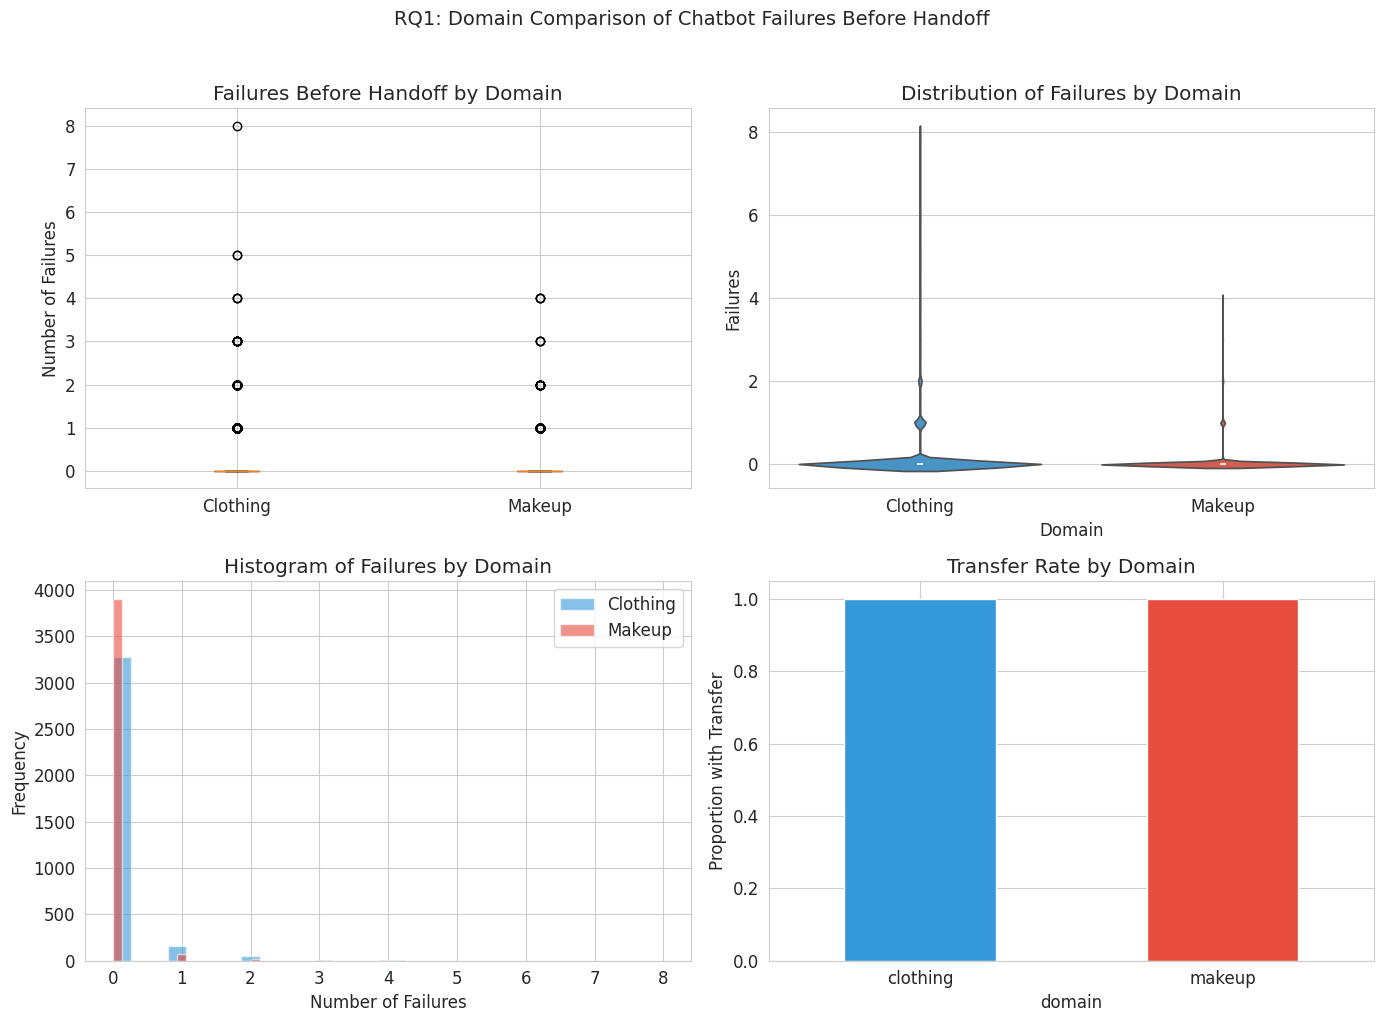


RQ1 Summary Table:
         Metric Clothing Makeup
    N dialogues     3500   4000
  Mean failures    0.089  0.031
Median failures    0.000  0.000
            Std    0.403  0.225
  Transfer rate    0.999  1.000


In [27]:
# Visualization for RQ1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Box plot comparison
data_to_plot = [clothing_failures.values, makeup_failures.values]
bp = axes[0, 0].boxplot(data_to_plot, labels=['Clothing', 'Makeup'], patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[0, 0].set_title('Failures Before Handoff by Domain')
axes[0, 0].set_ylabel('Number of Failures')

# 2. Violin plot
violin_data = pd.DataFrame({
    'Failures': np.concatenate([clothing_failures.values, makeup_failures.values]),
    'Domain': ['Clothing'] * len(clothing_failures) + ['Makeup'] * len(makeup_failures)
})
sns.violinplot(data=violin_data, x='Domain', y='Failures', ax=axes[0, 1],
               palette=['#3498db', '#e74c3c'])
axes[0, 1].set_title('Distribution of Failures by Domain')

# 3. Histogram overlay
axes[1, 0].hist(clothing_failures.values, bins=30, alpha=0.6, label='Clothing', color='#3498db')
axes[1, 0].hist(makeup_failures.values, bins=30, alpha=0.6, label='Makeup', color='#e74c3c')
axes[1, 0].set_title('Histogram of Failures by Domain')
axes[1, 0].set_xlabel('Number of Failures')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 4. Transfer rate comparison
transfer_rates = dialogue_failures.groupby('domain')['has_transfer'].mean()
transfer_rates.plot(kind='bar', ax=axes[1, 1], color=['#3498db', '#e74c3c'])
axes[1, 1].set_title('Transfer Rate by Domain')
axes[1, 1].set_ylabel('Proportion with Transfer')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

plt.suptitle('RQ1: Domain Comparison of Chatbot Failures Before Handoff', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('rq1_domain_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\nRQ1 Summary Table:')
summary_table = pd.DataFrame({
    'Metric': ['N dialogues', 'Mean failures', 'Median failures', 'Std', 'Transfer rate'],
    'Clothing': [
        len(clothing_failures),
        f'{clothing_failures.mean():.3f}',
        f'{clothing_failures.median():.3f}',
        f'{clothing_failures.std():.3f}',
        f'{dialogue_failures[dialogue_failures["domain"]=="clothing"]["has_transfer"].mean():.3f}'
    ],
    'Makeup': [
        len(makeup_failures),
        f'{makeup_failures.mean():.3f}',
        f'{makeup_failures.median():.3f}',
        f'{makeup_failures.std():.3f}',
        f'{dialogue_failures[dialogue_failures["domain"]=="makeup"]["has_transfer"].mean():.3f}'
    ]
})
print(summary_table.to_string(index=False))
# Output: RQ1 visualization and summary table

## 6. RQ2: Transferability Prediction Models

**Research Question:** Can we predict whether a given utterance will trigger a handoff transfer using machine learning?

**Models:**
1. Logistic Regression (baseline)
2. Random Forest
3. XGBoost
4. Bidirectional LSTM (deep learning)

**Benchmark:** DAMI BiLSTM baseline from Liu et al. (2020)

**Metrics:** Accuracy, Precision, Recall, F1-Score, AUC-ROC, MCC

In [28]:
# RQ2: Transferability Prediction Models
print('=' * 70)
print('RQ2: TRANSFERABILITY PREDICTION MODELS')
print('=' * 70)

# Split data into train/test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'Training set after SMOTE: {X_train_balanced.shape[0]} samples')
print(f'Features: {X_train.shape[1]}')
print(f'\nClass distribution in training set (before SMOTE):')
print(f'  Class 0: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)')
print(f'  Class 1: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)')
# Output: Train/test split summary

RQ2: TRANSFERABILITY PREDICTION MODELS
Training set: 60438 samples
Test set: 15110 samples
Training set after SMOTE: 118086 samples
Features: 17

Class distribution in training set (before SMOTE):
  Class 0: 59043 (97.7%)
  Class 1: 1395 (2.3%)


In [29]:
import numpy as np

# Helper function to evaluate models
def evaluate_model(name, model, X_test, y_test, y_pred=None, y_prob=None):
    """
    Comprehensive model evaluation with all required metrics.
    Returns a dictionary of evaluation metrics.
    """
    if y_pred is None:
        y_pred = model.predict(X_test)
    if y_prob is None:
        if model is not None and hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = y_pred.astype(float)

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0, average='weighted'),
        'Recall': recall_score(y_test, y_pred, zero_division=0, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0, average='weighted'),
        'AUC-ROC': roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 0.5,
        'MCC': matthews_corrcoef(y_test, y_pred)
    }

    print(f'\n{"=" * 50}')
    print(f'Model: {name}')
    print(f'{"=" * 50}')
    for metric, value in metrics.items():
        if metric != 'Model':
            print(f'  {metric}: {value:.4f}')

    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Transferable']))

    print('Confusion Matrix:')
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    return metrics

# Store all model results
all_results = []


### 6.1 Model 1: Logistic Regression (Baseline)

In [30]:
# Model 1: Logistic Regression with hyperparameter tuning
print('\n' + '=' * 70)
print('MODEL 1: LOGISTIC REGRESSION')
print('=' * 70)

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

print('Training Logistic Regression with GridSearchCV...')
lr_grid.fit(X_train_balanced, y_train_balanced)

print(f'Best parameters: {lr_grid.best_params_}')
print(f'Best CV F1-score: {lr_grid.best_score_:.4f}')

lr_model = lr_grid.best_estimator_
lr_results = evaluate_model('Logistic Regression', lr_model, X_test_scaled, y_test)
all_results.append(lr_results)

# Feature importance (coefficients)
lr_coefs = pd.Series(lr_model.coef_[0], index=feature_cols).sort_values(ascending=False)
print('\nTop 10 features (by coefficient magnitude):')
print(lr_coefs.head(10).round(4))
print('\nBottom 10 features:')
print(lr_coefs.tail(10).round(4))
# Output: Logistic Regression results and feature coefficients


MODEL 1: LOGISTIC REGRESSION
Training Logistic Regression with GridSearchCV...
Best parameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1-score: 0.6855

Model: Logistic Regression
  Accuracy: 0.6009
  Precision: 0.9681
  Recall: 0.6009
  F1-Score: 0.7299
  AUC-ROC: 0.7290
  MCC: 0.1046

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.60      0.75     14761
Transferable       0.04      0.74      0.08       349

    accuracy                           0.60     15110
   macro avg       0.52      0.67      0.41     15110
weighted avg       0.97      0.60      0.73     15110

Confusion Matrix:
[[8820 5941]
 [  89  260]]

Top 10 features (by coefficient magnitude):
utterance_length_log        0.6606
turn_index_log              0.4763
entity_mismatch_score       0.3374
sentiment_log               0.2229
is_repeated                 0.1104
sentiment                   0.0910
term_freq                   0.0661
term

### 6.2 Model 2: Random Forest

In [31]:
from sklearn.model_selection import RandomizedSearchCV

# Model 2: Random Forest with hyperparameter tuning
print('\n' + '=' * 70)
print('MODEL 2: RANDOM FOREST')
print('=' * 70)

rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Using RandomizedSearchCV for faster tuning
rf_grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    n_iter=10,  # Number of parameter settings that are sampled. Reduce for faster execution.
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), # Reduced n_splits for speed
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

print('Training Random Forest with RandomizedSearchCV...')
rf_grid.fit(X_train_balanced, y_train_balanced)

print(f'Best parameters: {rf_grid.best_params_}')
print(f'Best CV F1-score: {rf_grid.best_score_:.4f}')

rf_model = rf_grid.best_estimator_
rf_results = evaluate_model('Random Forest', rf_model, X_test_scaled, y_test)
all_results.append(rf_results)

# Feature importance
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\nTop 10 features (by importance):')
print(rf_importance.head(10).round(4))



MODEL 2: RANDOM FOREST
Training Random Forest with RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best CV F1-score: 0.9943

Model: Random Forest
  Accuracy: 0.9829
  Precision: 0.9803
  Recall: 0.9829
  F1-Score: 0.9807
  AUC-ROC: 0.9415
  MCC: 0.5452

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     14761
Transferable       0.72      0.43      0.54       349

    accuracy                           0.98     15110
   macro avg       0.85      0.71      0.76     15110
weighted avg       0.98      0.98      0.98     15110

Confusion Matrix:
[[14702    59]
 [  200   149]]

Top 10 features (by importance):
utterance_length        0.1240
utterance_length_log    0.1240
sentiment_log           0.1011
cumulative_failures     0.0940
sentiment               0.0848
turn_index_log   

### 6.3 Model 3: XGBoost

In [32]:
# Model 3: XGBoost with hyperparameter tuning
print('\n' + '=' * 70)
print('MODEL 3: XGBOOST')
print('=' * 70)

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = RandomizedSearchCV(
    xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False
    ),
    xgb_param_grid,
    n_iter=10, # Number of parameter settings that are sampled. Reduce for faster execution.
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

print('Training XGBoost with RandomizedSearchCV...')
xgb_grid.fit(X_train_balanced, y_train_balanced)

print(f'Best parameters: {xgb_grid.best_params_}')
print(f'Best CV F1-score: {xgb_grid.best_score_:.4f}')

xgb_model = xgb_grid.best_estimator_
xgb_results = evaluate_model('XGBoost', xgb_model, X_test_scaled, y_test)
all_results.append(xgb_results)

xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)
print('\nTop 10 features (by importance):')
print(xgb_importance.head(10).round(4))
# Output: XGBoost results and feature importance


MODEL 3: XGBOOST
Training XGBoost with RandomizedSearchCV...
Best parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best CV F1-score: 0.9928

Model: XGBoost
  Accuracy: 0.9855
  Precision: 0.9842
  Recall: 0.9855
  F1-Score: 0.9832
  AUC-ROC: 0.9460
  MCC: 0.6116

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     14761
Transferable       0.87      0.44      0.58       349

    accuracy                           0.99     15110
   macro avg       0.93      0.72      0.79     15110
weighted avg       0.98      0.99      0.98     15110

Confusion Matrix:
[[14738    23]
 [  196   153]]

Top 10 features (by importance):
utterance_length            0.1767
turn_index_log              0.1722
sentiment                   0.1050
turn_index                  0.0762
dialogue_length             0.0726
cumulative_failures         0.0611
sentiment_log             

### 6.4 Model 4: Bidirectional LSTM


MODEL 4: BIDIRECTIONAL LSTM
Sequence shape: (7500, 20, 17)
Labels shape: (7500, 20)

Training sequences: 6000
Test sequences: 1500

LSTM Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 20, 128)        │        41,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,313 (333.25 KB)

 Trainable params: 85,313 (333.25 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.9898 - loss: 0.0593 - val_accuracy: 1.0000 - val_loss: 3.0962e-04
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9990 - loss: 0.0067 - val_accuracy: 1.0000 - val_loss: 4.4404e-04
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9990 - loss: 0.0071 - val_accuracy: 1.0000 - val_loss: 7.5229e-04
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.9990 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9990 - loss: 0.0077 - val_accuracy: 1.0000 - val_loss: 9.9362e-04
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9990 - loss: 0.0063 - val_accuracy: 1.0000 - val_loss: 8.5877e-04
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step

Model: BiLSTM
  Accuracy: 0.9987
  Precision: 0.9973
  Recall: 0.9987
  F1-Score: 0.9980
  AUC-ROC: 0.9393
  MCC: 0.0000

Classification Repor

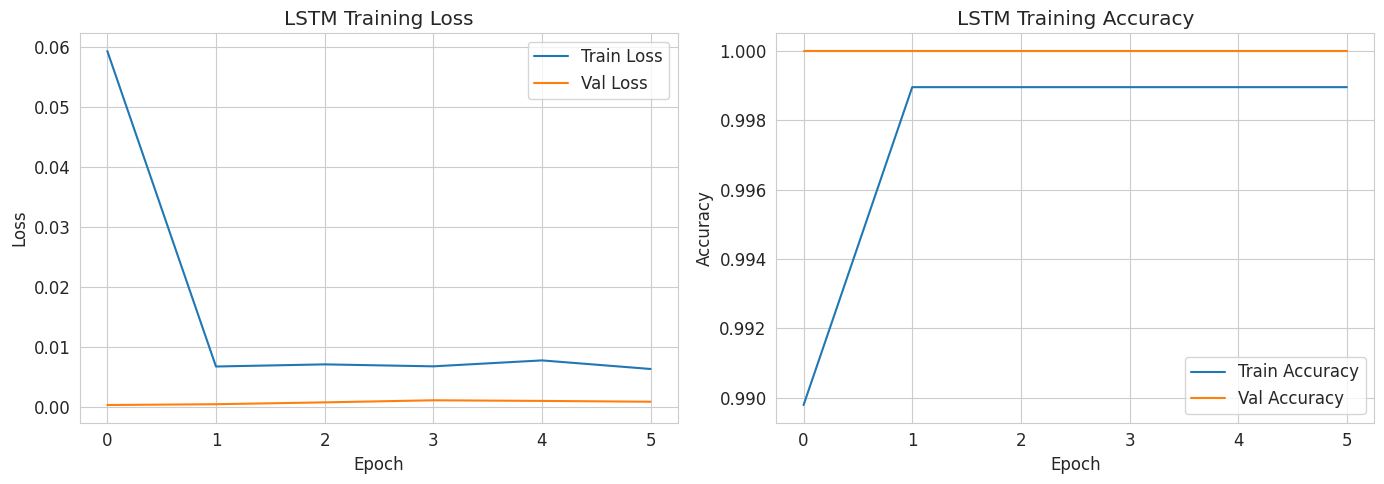

In [33]:
# Model 4: Bidirectional LSTM
print('\n' + '=' * 70)
print('MODEL 4: BIDIRECTIONAL LSTM')
print('=' * 70)

def create_sequences(df, feature_cols, max_seq_length=20):
    """
    Create sequences of utterances for LSTM input.
    Each sequence represents a dialogue (padded/truncated to max_seq_length).
    """
    sequences = []
    labels = []

    for dial_id in df['dialogue_id'].unique():
        dial_data = df[df['dialogue_id'] == dial_id].sort_values('turn_index')
        seq_features = dial_data[feature_cols].values
        # Use the binarized label_binary column for the target
        seq_labels = dial_data['label_binary'].values

        if len(seq_features) > max_seq_length:
            seq_features = seq_features[:max_seq_length]
            seq_labels = seq_labels[:max_seq_length]
        elif len(seq_features) < max_seq_length:
            padding = np.zeros((max_seq_length - len(seq_features), len(feature_cols)))
            seq_features = np.vstack([seq_features, padding])
            seq_labels = np.concatenate([seq_labels, np.zeros(max_seq_length - len(seq_labels))])

        sequences.append(seq_features)
        labels.append(seq_labels)

    return np.array(sequences), np.array(labels)

# Create sequences
MAX_SEQ_LEN = 20
X_seq, y_seq = create_sequences(df_all, feature_cols, max_seq_length=MAX_SEQ_LEN)

print(f'Sequence shape: {X_seq.shape}')
print(f'Labels shape: {y_seq.shape}')

# Split sequences
n_dialogues = X_seq.shape[0]
indices = np.arange(n_dialogues)
np.random.shuffle(indices)

split_idx = int(0.8 * n_dialogues)
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train_seq = X_seq[train_idx]
y_train_seq = y_seq[train_idx]
X_test_seq = X_seq[test_idx]
y_test_seq = y_seq[test_idx]

# Flatten labels for evaluation (use last turn label)
y_test_flat = y_test_seq[:, -1].astype(int)

print(f'\nTraining sequences: {X_train_seq.shape[0]}')
print(f'Test sequences: {X_test_seq.shape[0]}')

# Build LSTM model
lstm_model = Sequential([
    Bidirectional(
        LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3),
        input_shape=(MAX_SEQ_LEN, len(feature_cols))
    ),
    Bidirectional(LSTM(32, dropout=0.3, recurrent_dropout=0.3)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('\nLSTM Model Summary:')
lstm_model.summary()

# Train with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

y_train_lstm = y_train_seq[:, -1].astype(int)

print('\nTraining LSTM...')
history = lstm_model.fit(
    X_train_seq, y_train_lstm,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Predict
y_prob_lstm = lstm_model.predict(X_test_seq).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

# Evaluate
lstm_results = evaluate_model('BiLSTM', None, None, y_test_flat, y_pred_lstm, y_prob_lstm)
all_results.append(lstm_results)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('LSTM Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Model Comparison and Benchmarking


RQ2: MODEL COMPARISON SUMMARY

All Model Metrics:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC     MCC
Model                                                                      
Logistic Regression    0.6009     0.9681  0.6009    0.7299   0.7290  0.1046
Random Forest          0.9829     0.9803  0.9829    0.9807   0.9415  0.5452
XGBoost                0.9855     0.9842  0.9855    0.9832   0.9460  0.6116
BiLSTM                 0.9987     0.9973  0.9987    0.9980   0.9393  0.0000


Best model per metric:
  Accuracy: BiLSTM (0.9987)
  Precision: BiLSTM (0.9973)
  Recall: BiLSTM (0.9987)
  F1-Score: BiLSTM (0.9980)
  AUC-ROC: XGBoost (0.9460)
  MCC: XGBoost (0.6116)


Comparison with DAMI Baseline:
                        Accuracy  Precision  Recall  F1-Score  AUC-ROC     MCC
Model                                                                         
Logistic Regression       0.6009     0.9681  0.6009    0.7299   0.7290  0.1046
Random Forest             0.9829   

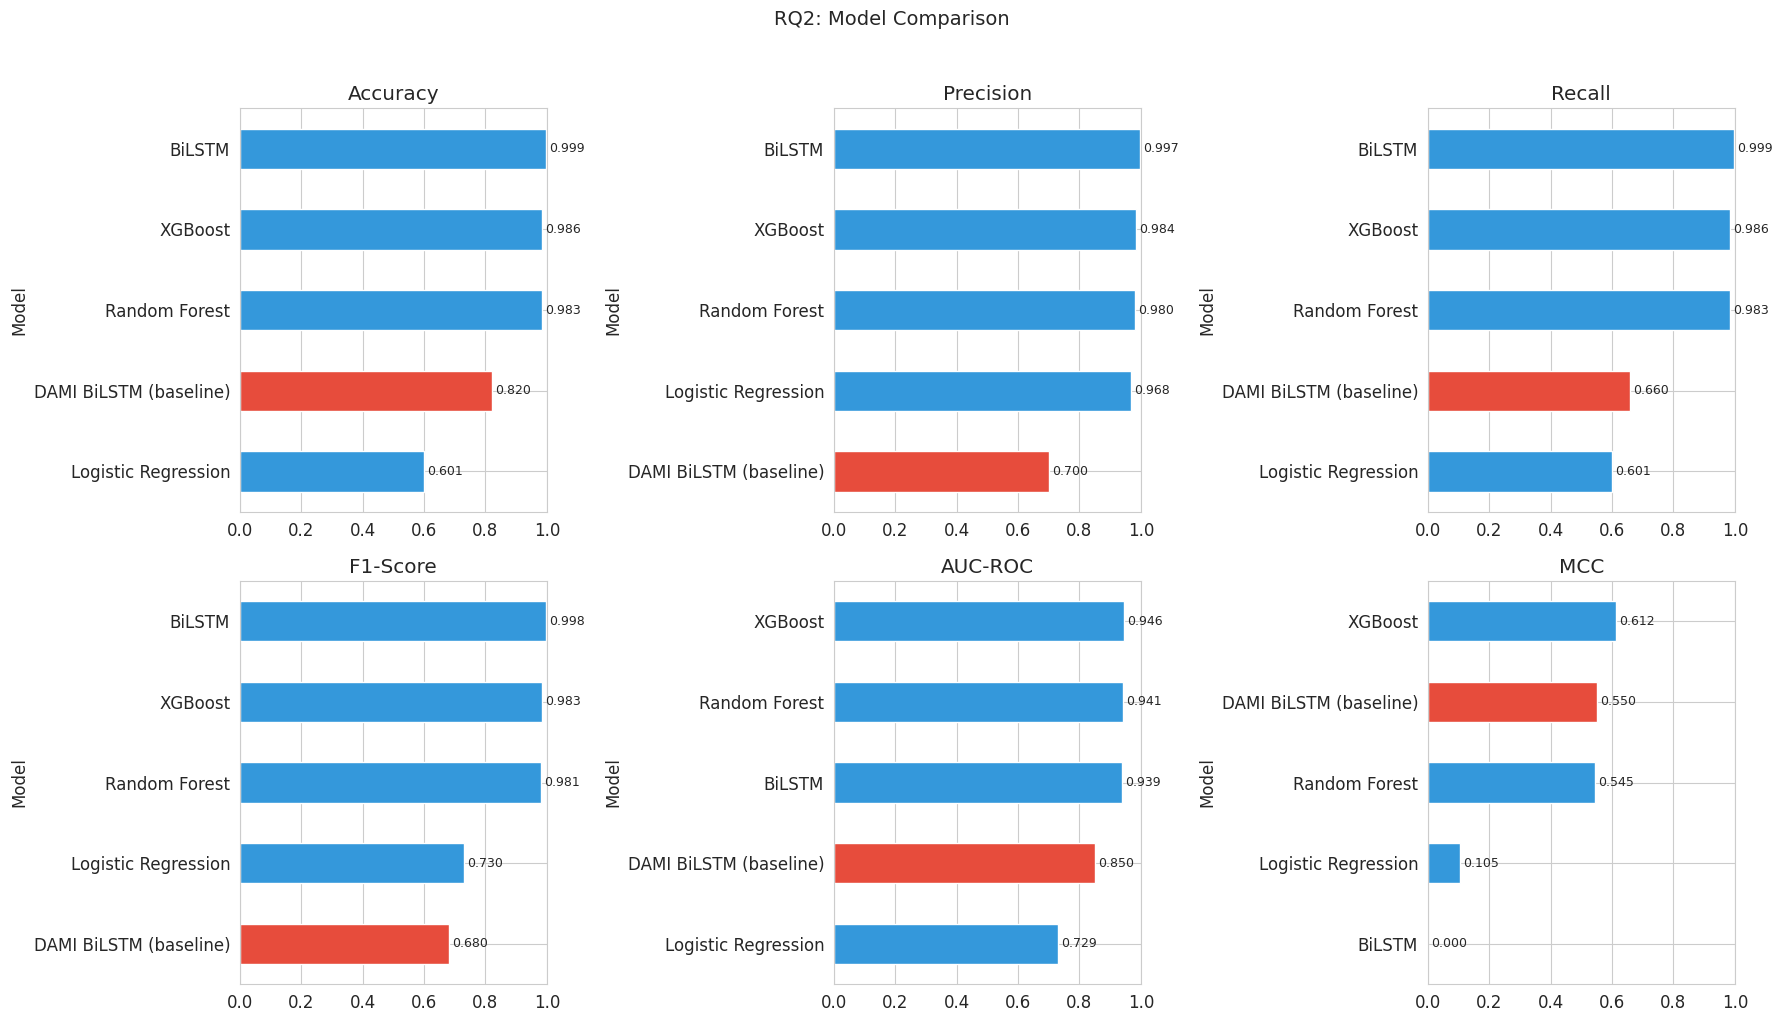

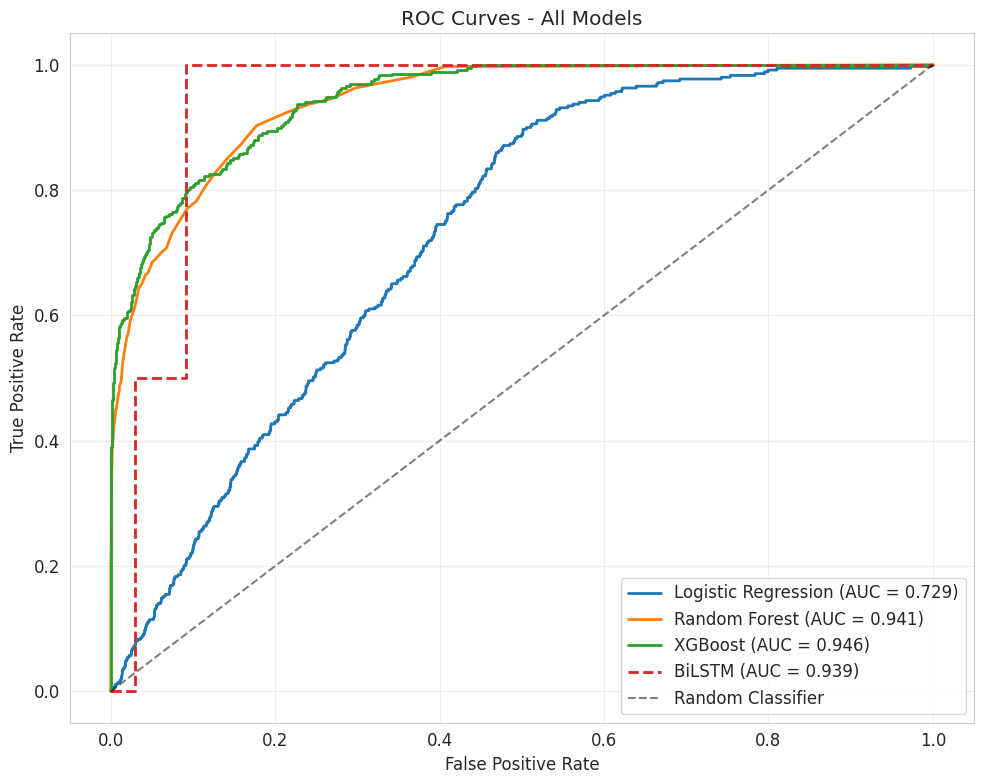

In [34]:
# Compare all models
print('\n' + '=' * 70)
print('RQ2: MODEL COMPARISON SUMMARY')
print('=' * 70)

comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.set_index('Model')

print('\nAll Model Metrics:')
print(comparison_df.round(4).to_string())

print('\n\nBest model per metric:')
for col in comparison_df.columns:
    best_model = comparison_df[col].idxmax()
    best_value = comparison_df[col].max()
    print(f'  {col}: {best_model} ({best_value:.4f})')

# DAMI BiLSTM baseline
dami_baseline = {
    'Model': 'DAMI BiLSTM (baseline)',
    'Accuracy': 0.82,
    'Precision': 0.70,
    'Recall': 0.66,
    'F1-Score': 0.68,
    'AUC-ROC': 0.85,
    'MCC': 0.55
}

comparison_with_baseline = comparison_df.copy()
comparison_with_baseline.loc['DAMI BiLSTM (baseline)'] = [dami_baseline[m] for m in comparison_df.columns]

print('\n\nComparison with DAMI Baseline:')
print(comparison_with_baseline.round(4).to_string())

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = comparison_with_baseline.columns

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    values = comparison_with_baseline[metric].sort_values(ascending=True)
    colors = ['#e74c3c' if 'baseline' in name else '#3498db' for name in values.index]
    values.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    for i, v in enumerate(values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('RQ2: Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('rq2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curves
plt.figure(figsize=(10, 8))

models_for_roc = [
    ('Logistic Regression', lr_model, X_test_scaled),
    ('Random Forest', rf_model, X_test_scaled),
    ('XGBoost', xgb_model, X_test_scaled)
]

for name, model, X_t in models_for_roc:
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_t)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

fpr_lstm, tpr_lstm, _ = roc_curve(y_test_flat, y_prob_lstm)
auc_lstm = roc_auc_score(y_test_flat, y_prob_lstm)
plt.plot(fpr_lstm, tpr_lstm, label=f'BiLSTM (AUC = {auc_lstm:.3f})', linewidth=2, linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rq2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
# Output: Complete model comparison with baseline and ROC curves

## 7. RQ3: Feature Importance and Predictor Analysis

**Research Question:** Which features are the strongest predictors of user frustration (transferability)?

**Methods:**
1. LASSO regression for feature selection (Friedman et al., 2010)
2. SHAP (SHapley Additive exPlanations) for model-agnostic interpretability (Lundberg & Lee, 2017)

RQ3: FEATURE IMPORTANCE AND PREDICTOR ANALYSIS

--- Part 1: LASSO Regression ---
Optimal alpha: 0.000109

LASSO Results:
  Total features: 17
  Selected (non-zero): 14
  Removed (zero): 3

Selected features (sorted by |coefficient|):
  utterance_length_log: +0.0135 (+)
  cumulative_failures: -0.0072 (-)
  turn_index_log: +0.0058 (+)
  entity_mismatch_score: +0.0043 (+)
  utterance_length: -0.0033 (-)
  sentiment: +0.0026 (+)
  sentiment_trajectory: -0.0025 (-)
  is_repeated: +0.0023 (+)
  sentiment_log: +0.0020 (+)
  term_freq: +0.0018 (+)
  role_log: -0.0015 (-)
  turn_ratio: -0.0011 (-)
  role: +0.0005 (+)
  turn_index: +0.0001 (+)

Removed features:
  dialogue_length
  term_freq_log
  question_repetition_rate


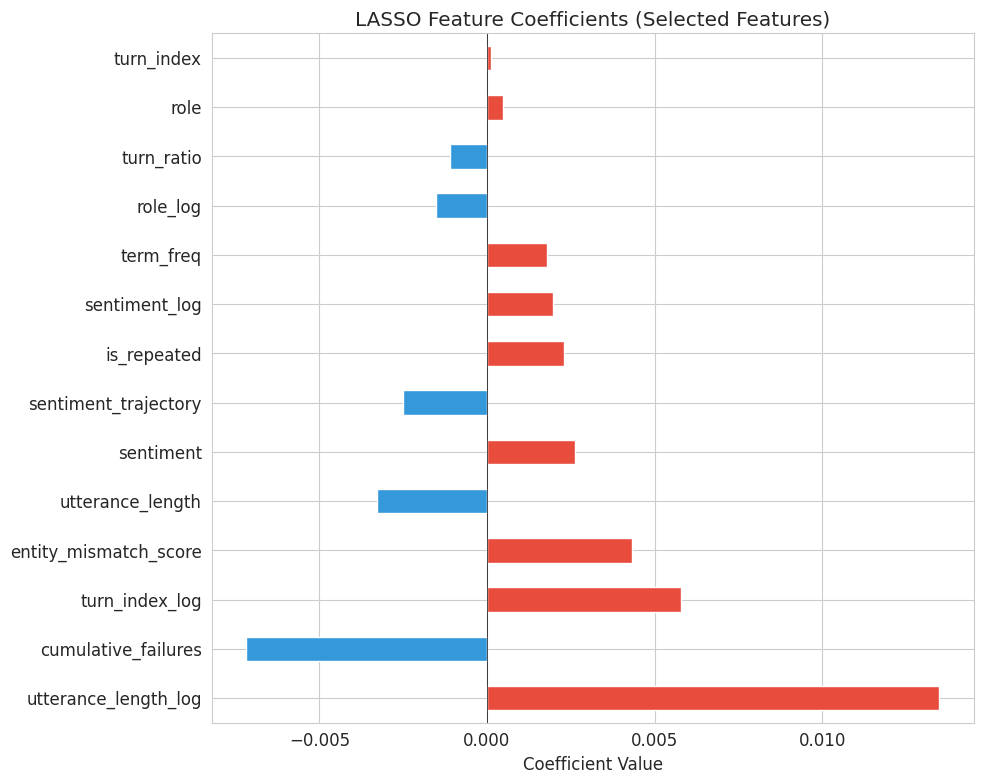

In [35]:
# RQ3: Feature Importance and Predictor Analysis
print('=' * 70)
print('RQ3: FEATURE IMPORTANCE AND PREDICTOR ANALYSIS')
print('=' * 70)

# 7.1 LASSO Regression for Feature Selection
print('\n--- Part 1: LASSO Regression ---')

lasso_cv = LassoCV(
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    max_iter=10000
)

# LASSO requires regression target; use original (non-SMOTE) data
lasso_cv.fit(X_train_scaled, y_train)

print(f'Optimal alpha: {lasso_cv.alpha_:.6f}')

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_cols)

selected_features = lasso_coefs[lasso_coefs.abs() > 0].sort_values(key=abs, ascending=False)
removed_features = lasso_coefs[lasso_coefs.abs() == 0]

print(f'\nLASSO Results:')
print(f'  Total features: {len(feature_cols)}')
print(f'  Selected (non-zero): {len(selected_features)}')
print(f'  Removed (zero): {len(removed_features)}')

print(f'\nSelected features (sorted by |coefficient|):')
for feat, coef in selected_features.items():
    direction = '+' if coef > 0 else '-'
    print(f'  {feat}: {coef:+.4f} ({direction})')

print(f'\nRemoved features:')
for feat in removed_features.index:
    print(f'  {feat}')

# LASSO coefficient plot
plt.figure(figsize=(10, 8))
colors_lasso = ['#e74c3c' if c > 0 else '#3498db' for c in selected_features.values]
selected_features.plot(kind='barh', color=colors_lasso)
plt.title('LASSO Feature Coefficients (Selected Features)')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('rq3_lasso_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
# Output: LASSO feature selection results


--- Part 2: SHAP Analysis ---

Computing SHAP values for XGBoost model...
SHAP values shape: (15110, 17)

1. SHAP Summary Plot (Global Feature Importance):


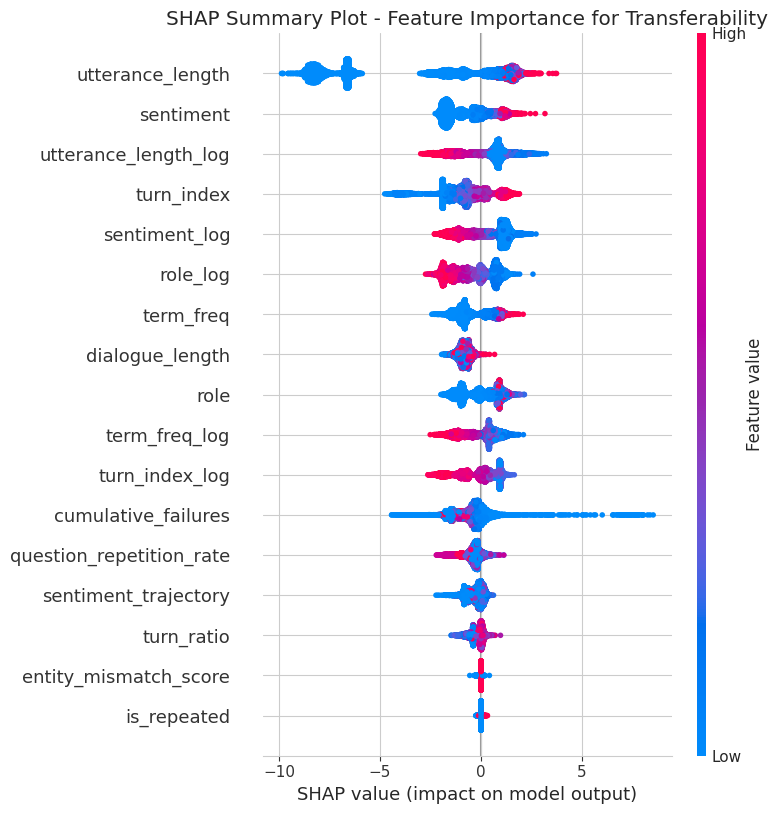


2. Mean |SHAP| Values (Feature Importance Ranking):
utterance_length            4.0422
sentiment                   1.1018
utterance_length_log        1.0639
turn_index                  1.0509
sentiment_log               1.0077
role_log                    0.9432
term_freq                   0.8631
dialogue_length             0.8249
role                        0.8004
term_freq_log               0.7610
turn_index_log              0.7548
cumulative_failures         0.6836
question_repetition_rate    0.4321
sentiment_trajectory        0.3429
turn_ratio                  0.2633
entity_mismatch_score       0.0150
is_repeated                 0.0138
dtype: float32


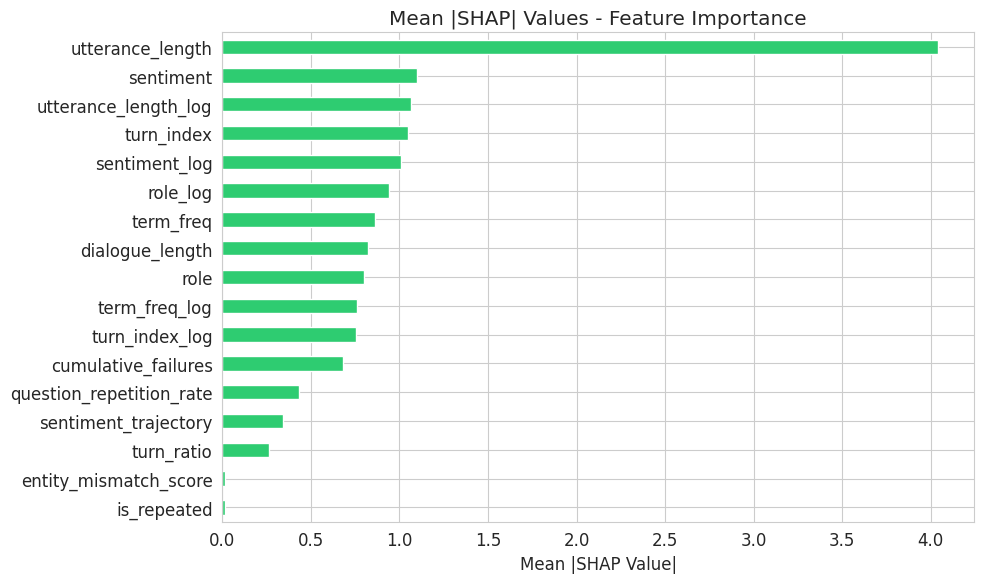

In [36]:
# 7.2 SHAP Analysis
print('\n' + '=' * 70)
print('--- Part 2: SHAP Analysis ---')
print('=' * 70)

print('\nComputing SHAP values for XGBoost model...')

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

print(f'SHAP values shape: {shap_values.shape}')

# 1. Summary plot (global feature importance)
print('\n1. SHAP Summary Plot (Global Feature Importance):')
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_cols, show=False)
plt.title('SHAP Summary Plot - Feature Importance for Transferability')
plt.tight_layout()
plt.savefig('rq3_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Bar plot of mean |SHAP| values
print('\n2. Mean |SHAP| Values (Feature Importance Ranking):')
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

print(shap_importance.round(4))

plt.figure(figsize=(10, 6))
shap_importance.plot(kind='barh', color='#2ecc71')
plt.title('Mean |SHAP| Values - Feature Importance')
plt.xlabel('Mean |SHAP Value|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rq3_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
# Output: SHAP analysis results


3. SHAP Dependence Plots for Top Features:
Top 4 features: ['utterance_length', 'sentiment', 'utterance_length_log', 'turn_index']


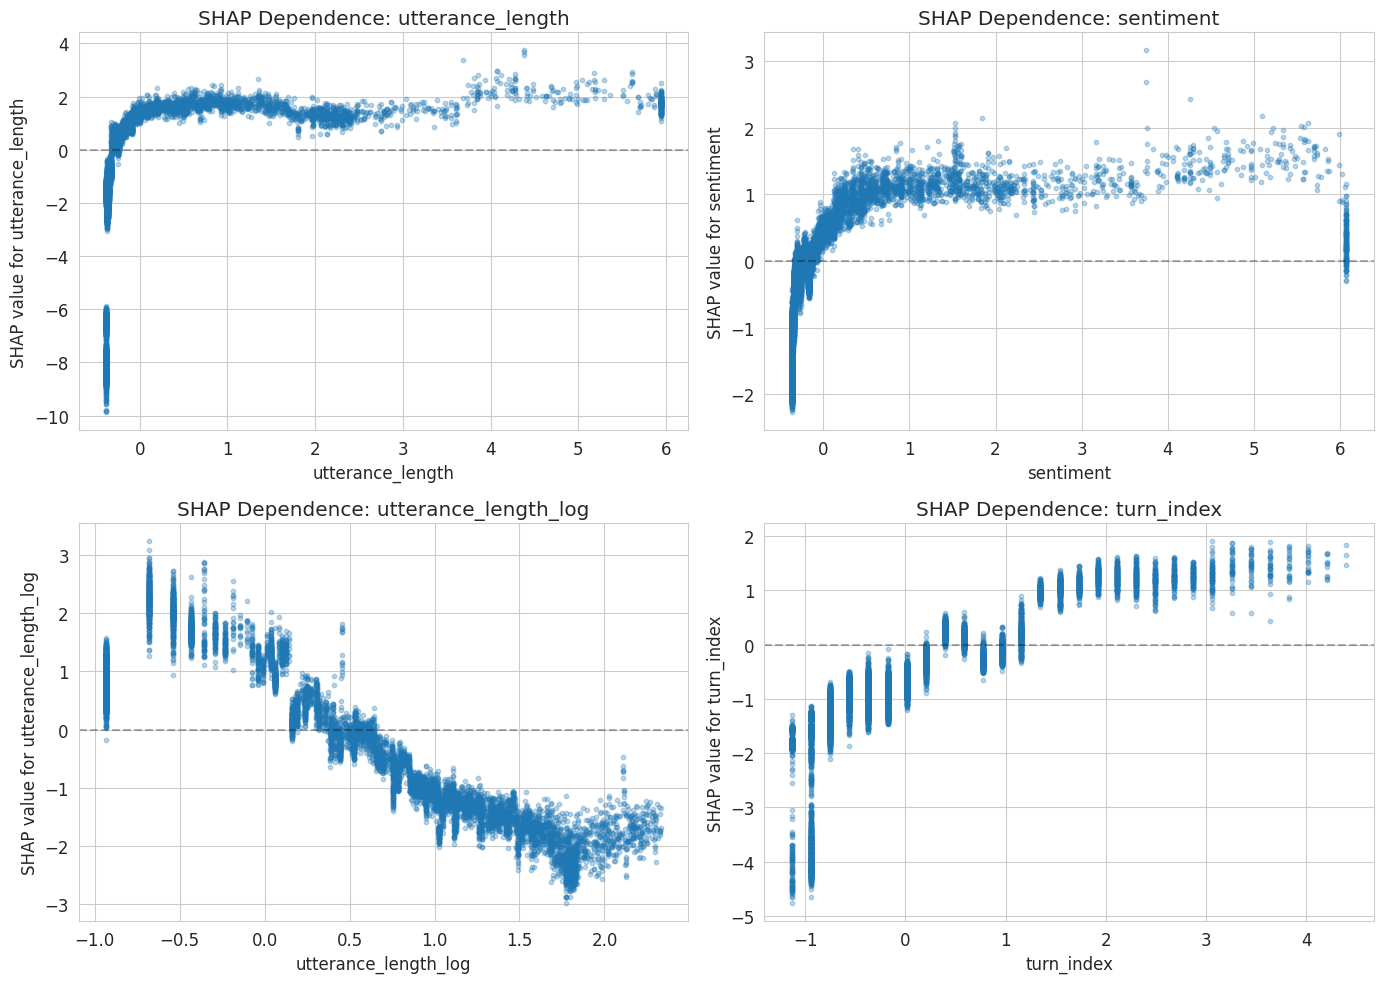


4. SHAP Waterfall Plot (Single Prediction Explanation):
Explaining prediction for test sample 0
Actual label: 0
Predicted probability: 0.1887


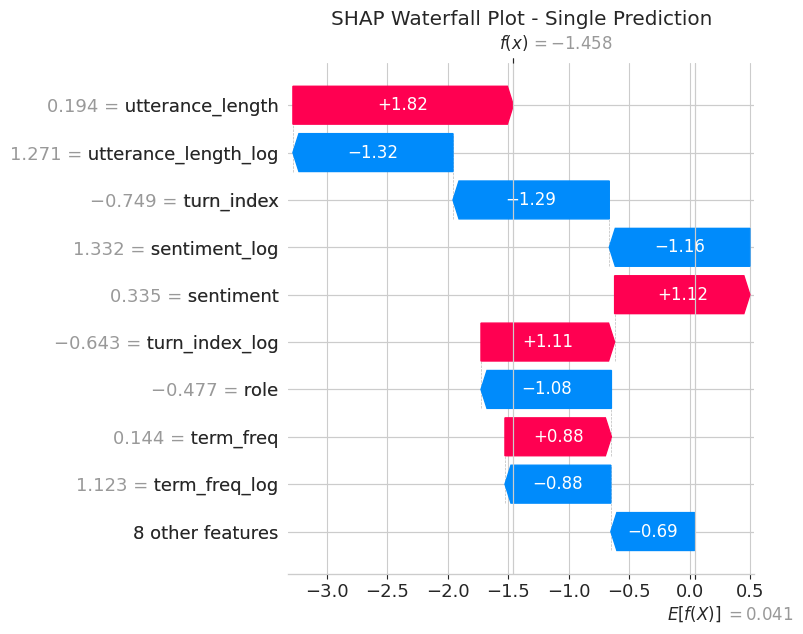

In [37]:
# 3. SHAP dependence plots for top features
print('\n3. SHAP Dependence Plots for Top Features:')

top_features = shap_importance.head(4).index.tolist()
print(f'Top 4 features: {top_features}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, feat in enumerate(top_features):
    ax = axes[idx // 2, idx % 2]
    feat_idx = feature_cols.index(feat)
    ax.scatter(
        X_test_scaled[:, feat_idx],
        shap_values[:, feat_idx],
        alpha=0.3, s=10
    )
    ax.set_xlabel(feat)
    ax.set_ylabel(f'SHAP value for {feat}')
    ax.set_title(f'SHAP Dependence: {feat}')
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('rq3_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. SHAP waterfall plot for a single prediction
print('\n4. SHAP Waterfall Plot (Single Prediction Explanation):')
sample_idx = 0
print(f'Explaining prediction for test sample {sample_idx}')
print(f'Actual label: {y_test.iloc[sample_idx]}')
print(f'Predicted probability: {xgb_model.predict_proba(X_test_scaled[sample_idx:sample_idx+1])[0, 1]:.4f}')

shap_exp = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled[sample_idx],
    feature_names=feature_cols
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_exp, show=False)
plt.title('SHAP Waterfall Plot - Single Prediction')
plt.tight_layout()
plt.savefig('rq3_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
# Output: SHAP dependence and waterfall plots

In [38]:
# RQ3 Summary
print('\n' + '=' * 70)
print('RQ3: FEATURE IMPORTANCE SUMMARY')
print('=' * 70)

print('\nComparison of Feature Selection Methods:')
print(f'{"Feature":<25} {"LASSO Coef":>12} {"LASSO Selected":>15} {"SHAP |Mean|":>12}')
print('-' * 70)

for feat in feature_cols:
    lasso_val = lasso_coefs.get(feat, 0)
    lasso_sel = 'Yes' if abs(lasso_val) > 0 else 'No'
    shap_val = shap_importance.get(feat, 0)
    print(f'{feat:<25} {lasso_val:>+12.4f} {lasso_sel:>15} {shap_val:>12.4f}')

# Identify strongest predictors
print('\n\nStrongest Predictors of Frustration (Consensus):')
lasso_selected = set(lasso_coefs[lasso_coefs.abs() > 0].index)
shap_top = set(shap_importance.head(len(feature_cols)//2).index)
consensus = lasso_selected.intersection(shap_top)

if consensus:
    for feat in consensus:
        print(f'  - {feat}')
else:
    print('  (No exact consensus - showing top SHAP features)')
    for feat in shap_importance.head(5).index:
        in_lasso = 'Yes' if feat in lasso_selected else 'No'
        print(f'  - {feat} (LASSO selected: {in_lasso})')

print('\n\nPractical Interpretation:')
print('The SHAP and LASSO analyses reveal which utterance-level features')
print('most strongly predict the need for human handoff. These findings')
print('can inform chatbot design by identifying early warning signals')
print('of user frustration.')
# Output: Complete RQ3 summary and interpretation


RQ3: FEATURE IMPORTANCE SUMMARY

Comparison of Feature Selection Methods:
Feature                     LASSO Coef  LASSO Selected  SHAP |Mean|
----------------------------------------------------------------------
turn_index                     +0.0001             Yes       1.0509
dialogue_length                +0.0000              No       0.8249
role                           +0.0005             Yes       0.8004
term_freq                      +0.0018             Yes       0.8631
sentiment                      +0.0026             Yes       1.1018
utterance_length               -0.0033             Yes       4.0422
turn_index_log                 +0.0058             Yes       0.7548
role_log                       -0.0015             Yes       0.9432
term_freq_log                  -0.0000              No       0.7610
sentiment_log                  +0.0020             Yes       1.0077
utterance_length_log           +0.0135             Yes       1.0639
turn_ratio                     -0.0011

## 8. RQ4: Temporal Distribution and Survival Analysis

**Research Question:** How does transferability distribute temporally across dialogue turns, and what is the "survival time" before a user requests handoff?

**Methods:**
1. Chi-squared test for temporal distribution uniformity
2. Kaplan-Meier survival analysis (Kaplan & Meier, 1958)

In survival analysis terms:
- **Event**: A handoff transfer occurs (user becomes frustrated)
- **Survival time**: Number of turns before the first transfer
- **Censored**: Dialogues that end without any transfer (user tolerated the chatbot)

In [39]:
# RQ4: Temporal Distribution and Survival Analysis
print('=' * 70)
print('RQ4: TEMPORAL DISTRIBUTION AND SURVIVAL ANALYSIS')
print('=' * 70)

# 8.1 Temporal Distribution of Transferability
print('\n--- Part 1: Temporal Distribution ---')

df_all['relative_position'] = df_all['turn_index'] / df_all['dialogue_length'].clip(lower=1)

n_bins = 10
df_all['position_bin'] = pd.cut(
    df_all['relative_position'],
    bins=n_bins,
    labels=[f'{i/n_bins:.1f}-{(i+1)/n_bins:.1f}' for i in range(n_bins)]
)

temporal_dist = df_all.groupby('position_bin').agg(
    total_utterances=('label', 'count'),
    transfers=('label', 'sum'),
    transfer_rate=('label', 'mean')
).reset_index()

print('\nTransfer rate by dialogue position:')
print(temporal_dist.to_string(index=False))

# Chi-squared test
chi2, chi2_pvalue = chi2_contingency(
    pd.crosstab(df_all['position_bin'], df_all['label'])
)[:2]

print(f'\nChi-squared test for temporal uniformity:')
print(f'  Chi-squared statistic: {chi2:.4f}')
print(f'  p-value: {chi2_pvalue:.6f}')
print(f'  Significant at alpha=0.05: {"Yes" if chi2_pvalue < 0.05 else "No"}')
# Output: Temporal distribution analysis

RQ4: TEMPORAL DISTRIBUTION AND SURVIVAL ANALYSIS

--- Part 1: Temporal Distribution ---

Transfer rate by dialogue position:
position_bin  total_utterances  transfers  transfer_rate
     0.0-0.1             10535     808101      76.706312
     0.1-0.2              7483    1897316     253.550180
     0.2-0.3              7900    2346721     297.053291
     0.3-0.4              6729    2052278     304.990043
     0.4-0.5              7228    2157768     298.529054
     0.5-0.6              7505    2206508     294.005063
     0.6-0.7              8108    2190332     270.144549
     0.7-0.8              6118    1670666     273.073880
     0.8-0.9              8237    2413359     292.990045
     0.9-1.0              5705    1647152     288.720771

Chi-squared test for temporal uniformity:
  Chi-squared statistic: 33626.8444
  p-value: 0.000000
  Significant at alpha=0.05: Yes


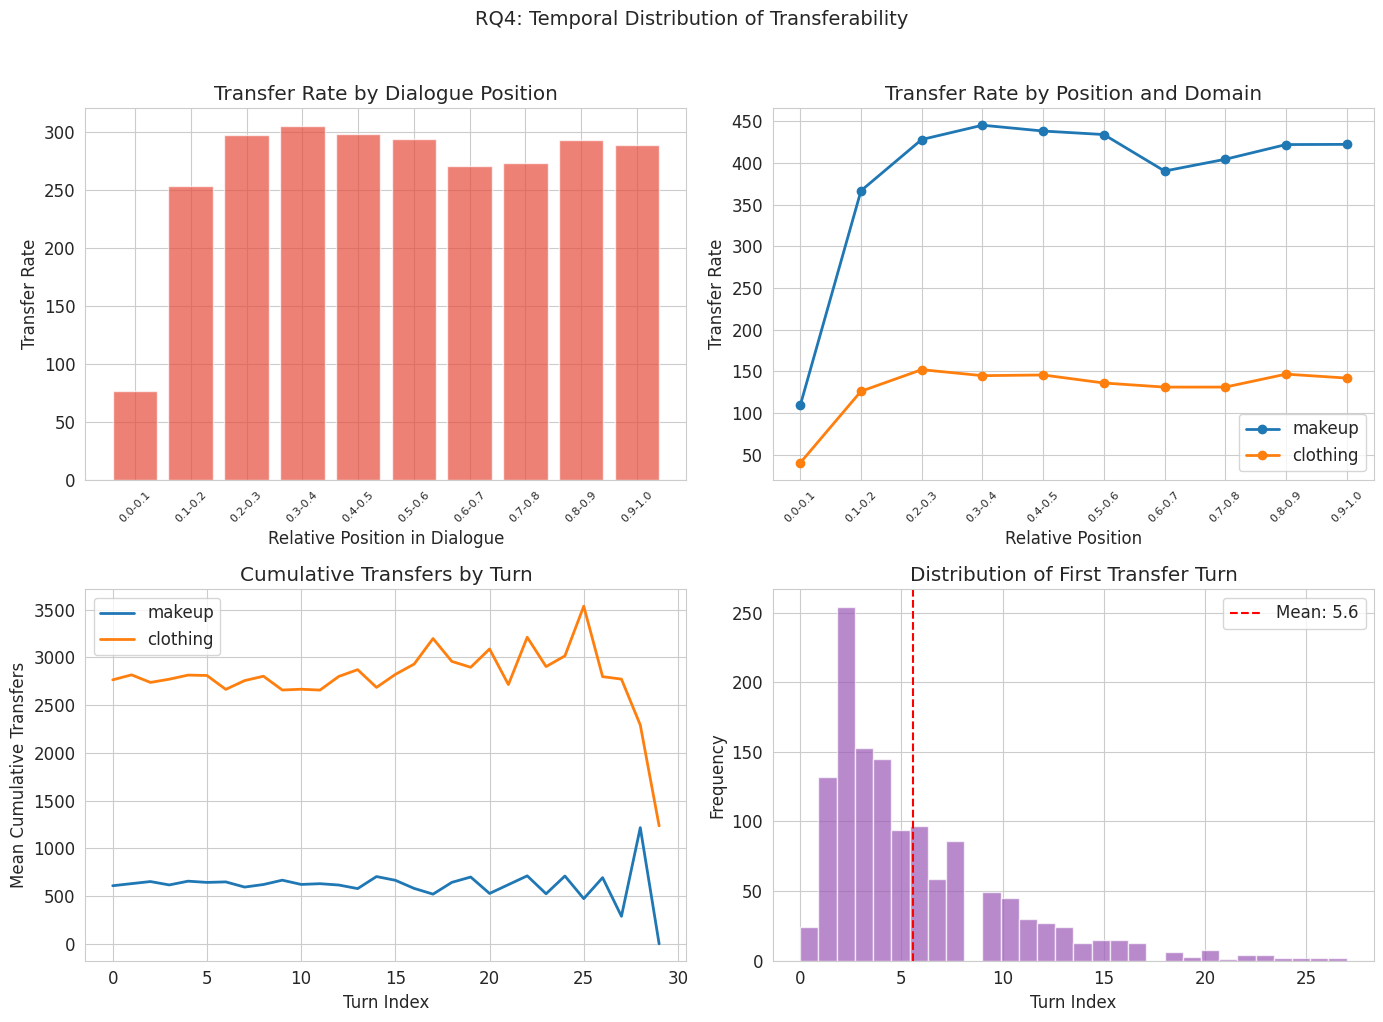

In [40]:
# Visualize temporal distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Transfer rate by position
axes[0, 0].bar(range(len(temporal_dist)), temporal_dist['transfer_rate'],
               color='#e74c3c', alpha=0.7)
axes[0, 0].set_xticks(range(len(temporal_dist)))
axes[0, 0].set_xticklabels(temporal_dist['position_bin'], rotation=45, fontsize=8)
axes[0, 0].set_title('Transfer Rate by Dialogue Position')
axes[0, 0].set_xlabel('Relative Position in Dialogue')
axes[0, 0].set_ylabel('Transfer Rate')

# 2. By domain
for domain in df_all['domain'].unique():
    domain_data = df_all[df_all['domain'] == domain]
    domain_temporal = domain_data.groupby('position_bin')['label'].mean()
    axes[0, 1].plot(range(len(domain_temporal)), domain_temporal.values,
                    marker='o', label=domain, linewidth=2)
axes[0, 1].set_xticks(range(n_bins))
axes[0, 1].set_xticklabels(temporal_dist['position_bin'], rotation=45, fontsize=8)
axes[0, 1].set_title('Transfer Rate by Position and Domain')
axes[0, 1].set_xlabel('Relative Position')
axes[0, 1].set_ylabel('Transfer Rate')
axes[0, 1].legend()

# 3. Cumulative transfer probability
cumulative_transfers = df_all.sort_values('turn_index').groupby('dialogue_id')['label'].cumsum()
df_all['cumulative_transfers'] = cumulative_transfers.values

for domain in df_all['domain'].unique():
    domain_data = df_all[df_all['domain'] == domain]
    cum_by_turn = domain_data.groupby('turn_index')['cumulative_transfers'].mean()
    axes[1, 0].plot(cum_by_turn.index, cum_by_turn.values, label=domain, linewidth=2)
axes[1, 0].set_title('Cumulative Transfers by Turn')
axes[1, 0].set_xlabel('Turn Index')
axes[1, 0].set_ylabel('Mean Cumulative Transfers')
axes[1, 0].legend()

# 4. Histogram of first transfer turn
first_transfer = df_all[df_all['label'] == 1].groupby('dialogue_id')['turn_index'].min()
axes[1, 1].hist(first_transfer.values, bins=30, color='#9b59b6', alpha=0.7)
axes[1, 1].set_title('Distribution of First Transfer Turn')
axes[1, 1].set_xlabel('Turn Index')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(x=first_transfer.mean(), color='red', linestyle='--',
                     label=f'Mean: {first_transfer.mean():.1f}')
axes[1, 1].legend()

plt.suptitle('RQ4: Temporal Distribution of Transferability', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('rq4_temporal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
# Output: Temporal distribution visualizations

In [41]:
# Kaplan-Meier Survival Analysis
print('\n' + '=' * 70)
print('--- Part 2: Kaplan-Meier Survival Analysis ---')
print('=' * 70)

# Prepare survival data
survival_data = []

for dial_id in df_all['dialogue_id'].unique():
    dial_data = df_all[df_all['dialogue_id'] == dial_id].sort_values('turn_index')
    domain = dial_data['domain'].iloc[0]
    total_turns = len(dial_data)

    transfers = dial_data[dial_data['label'] == 1]

    if len(transfers) > 0:
        first_transfer_turn = transfers['turn_index'].min()
        duration = first_transfer_turn + 1  # Convert to 1-indexed
        event_observed = 1
    else:
        duration = total_turns
        event_observed = 0

    survival_data.append({
        'dialogue_id': dial_id,
        'domain': domain,
        'duration': duration,
        'event_observed': event_observed
    })

survival_df = pd.DataFrame(survival_data)

print('\nSurvival Data Summary:')
print(f'Total dialogues: {len(survival_df)}')
print(f'Events (transfers): {survival_df["event_observed"].sum()} ({survival_df["event_observed"].mean()*100:.1f}%)')
print(f'Censored (no transfer): {(survival_df["event_observed"]==0).sum()} ({(survival_df["event_observed"]==0).mean()*100:.1f}%)')
print(f'\nDuration statistics:')
print(survival_df.groupby('domain')[['duration', 'event_observed']].describe().round(2))
# Output: Survival data preparation summary


--- Part 2: Kaplan-Meier Survival Analysis ---

Survival Data Summary:
Total dialogues: 7500
Events (transfers): 1309 (17.5%)
Censored (no transfer): 6191 (82.5%)

Duration statistics:
         duration                                        event_observed        \
            count  mean   std  min  25%  50%   75%   max          count  mean   
domain                                                                          
clothing   3500.0  8.75  4.90  1.0  5.0  7.0  11.0  30.0         3500.0  0.24   
makeup     4000.0  9.31  5.12  1.0  6.0  8.0  11.0  30.0         4000.0  0.12   

                                         
           std  min  25%  50%  75%  max  
domain                                   
clothing  0.42  0.0  0.0  0.0  0.0  1.0  
makeup    0.33  0.0  0.0  0.0  0.0  1.0  



Fitting Kaplan-Meier survival curves...

Overall Survival Statistics:
  Median survival time: inf
  Survival at turn 5: 0.906
  Survival at turn 10: 0.819
  Survival at turn 15: 0.747

Makeup domain:
  N: 4000
  Events: 483
  Median survival: inf

Clothing domain:
  N: 3500
  Events: 826
  Median survival: 26.0

Log-rank test (Clothing vs Makeup):
  Test statistic: 175.5847
  p-value: 0.000000
  Significant at alpha=0.05: Yes


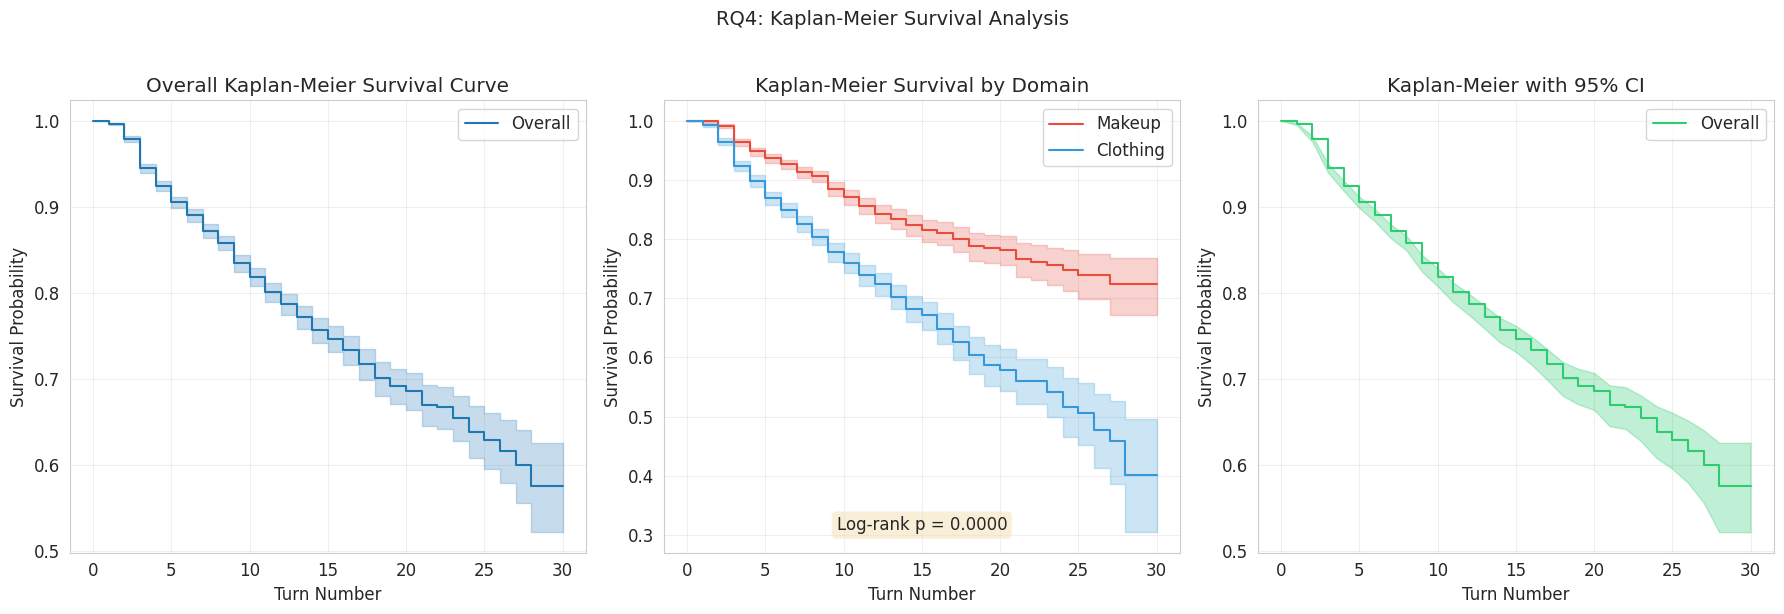

In [42]:
# Fit Kaplan-Meier estimator and plot
print('\nFitting Kaplan-Meier survival curves...')

kmf = KaplanMeierFitter()

# Overall
kmf.fit(
    durations=survival_df['duration'],
    event_observed=survival_df['event_observed'],
    label='Overall'
)

print(f'\nOverall Survival Statistics:')
print(f'  Median survival time: {kmf.median_survival_time_}')
print(f'  Survival at turn 5: {kmf.predict(5):.3f}')
print(f'  Survival at turn 10: {kmf.predict(10):.3f}')
print(f'  Survival at turn 15: {kmf.predict(15):.3f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Overall
kmf.fit(
    durations=survival_df['duration'],
    event_observed=survival_df['event_observed'],
    label='Overall'
)
kmf.plot_survival_function(ax=axes[0], ci_show=True)
axes[0].set_title('Overall Kaplan-Meier Survival Curve')
axes[0].set_xlabel('Turn Number')
axes[0].set_ylabel('Survival Probability')
axes[0].grid(True, alpha=0.3)

# By domain
colors = {'clothing': '#3498db', 'makeup': '#e74c3c'}
for domain in survival_df['domain'].unique():
    domain_data = survival_df[survival_df['domain'] == domain]
    kmf.fit(
        durations=domain_data['duration'],
        event_observed=domain_data['event_observed'],
        label=domain.capitalize()
    )
    kmf.plot_survival_function(ax=axes[1], ci_show=True, color=colors.get(domain))

    print(f'\n{domain.capitalize()} domain:')
    print(f'  N: {len(domain_data)}')
    print(f'  Events: {domain_data["event_observed"].sum()}')
    print(f'  Median survival: {kmf.median_survival_time_}')

axes[1].set_title('Kaplan-Meier Survival by Domain')
axes[1].set_xlabel('Turn Number')
axes[1].set_ylabel('Survival Probability')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Log-rank test
clothing_surv = survival_df[survival_df['domain'] == 'clothing']
makeup_surv = survival_df[survival_df['domain'] == 'makeup']

if len(clothing_surv) > 0 and len(makeup_surv) > 0:
    results = logrank_test(
        clothing_surv['duration'], makeup_surv['duration'],
        event_observed_A=clothing_surv['event_observed'],
        event_observed_B=makeup_surv['event_observed']
    )

    print(f'\nLog-rank test (Clothing vs Makeup):')
    print(f'  Test statistic: {results.test_statistic:.4f}')
    print(f'  p-value: {results.p_value:.6f}')
    print(f'  Significant at alpha=0.05: {"Yes" if results.p_value < 0.05 else "No"}')

    axes[1].text(0.5, 0.05, f'Log-rank p = {results.p_value:.4f}',
                transform=axes[1].transAxes, ha='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Confidence interval visualization
kmf.fit(
    durations=survival_df['duration'],
    event_observed=survival_df['event_observed'],
    label='Overall'
)
ci = kmf.confidence_interval_survival_function_
axes[2].fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.3, color='#2ecc71')
kmf.plot_survival_function(ax=axes[2], ci_show=False, color='#2ecc71')
axes[2].set_title('Kaplan-Meier with 95% CI')
axes[2].set_xlabel('Turn Number')
axes[2].set_ylabel('Survival Probability')
axes[2].grid(True, alpha=0.3)

plt.suptitle('RQ4: Kaplan-Meier Survival Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('rq4_kaplan_meier.png', dpi=150, bbox_inches='tight')
plt.show()
# Output: Kaplan-Meier survival curves and log-rank test results


RQ4: ADDITIONAL SURVIVAL ANALYSIS

Survival by sentiment group:
  Negative: n=2500, median_survival=27.0
  Neutral: n=2501, median_survival=inf
  Positive: n=2499, median_survival=inf


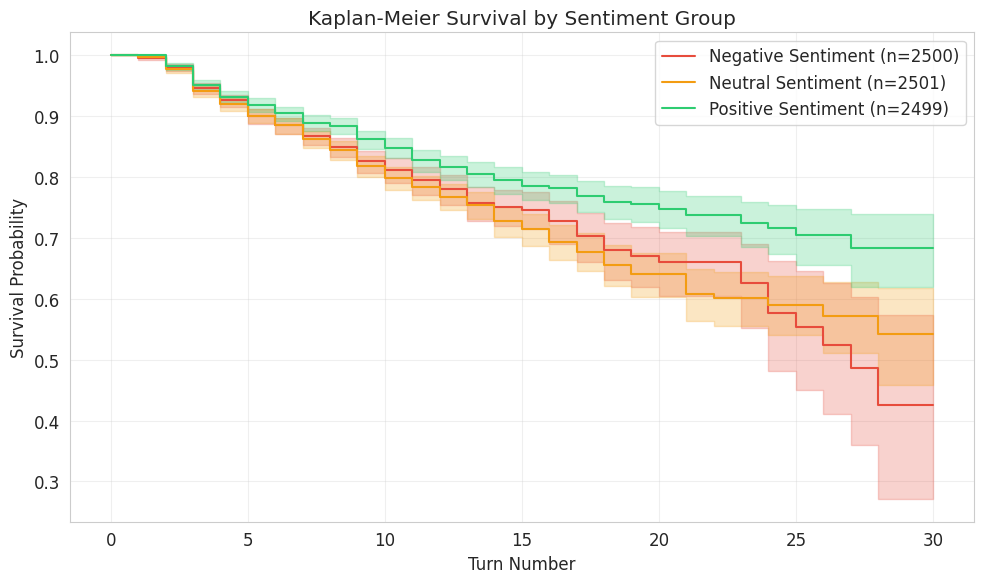


Multivariate log-rank test (sentiment groups):
  Test statistic: 24.2120
  p-value: 0.000006

--- RQ4 Summary ---
The survival analysis reveals the "tolerance threshold" - the typical
number of turns a user persists before requesting human handoff.
Kaplan-Meier curves show how this threshold varies across domains
and user characteristics.


In [43]:
# RQ4 Additional Analysis: Survival by sentiment (if available)
print('\n' + '=' * 70)
print('RQ4: ADDITIONAL SURVIVAL ANALYSIS')
print('=' * 70)

if 'sentiment' in df_all.columns and pd.api.types.is_numeric_dtype(df_all['sentiment']):
    sentiment_per_dialogue = df_all.groupby('dialogue_id')['sentiment'].mean().reset_index()
    survival_df = survival_df.merge(sentiment_per_dialogue, on='dialogue_id', how='left')

    survival_df['sentiment_group'] = pd.qcut(
        survival_df['sentiment'].fillna(0), q=3,
        labels=['Negative', 'Neutral', 'Positive']
    )

    print('\nSurvival by sentiment group:')
    fig, ax = plt.subplots(figsize=(10, 6))

    sentiment_colors = {'Negative': '#e74c3c', 'Neutral': '#f39c12', 'Positive': '#2ecc71'}
    for group in ['Negative', 'Neutral', 'Positive']:
        group_data = survival_df[survival_df['sentiment_group'] == group]
        if len(group_data) > 0:
            kmf.fit(
                durations=group_data['duration'],
                event_observed=group_data['event_observed'],
                label=f'{group} Sentiment (n={len(group_data)})'
            )
            kmf.plot_survival_function(ax=ax, ci_show=True, color=sentiment_colors[group])
            print(f'  {group}: n={len(group_data)}, median_survival={kmf.median_survival_time_}')

    ax.set_title('Kaplan-Meier Survival by Sentiment Group')
    ax.set_xlabel('Turn Number')
    ax.set_ylabel('Survival Probability')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('rq4_survival_by_sentiment.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Log-rank test across sentiment groups
    from lifelines.statistics import multivariate_logrank_test
    multi_test = multivariate_logrank_test(
        survival_df['duration'],
        survival_df['sentiment_group'],
        survival_df['event_observed']
    )
    print(f'\nMultivariate log-rank test (sentiment groups):')
    print(f'  Test statistic: {multi_test.test_statistic:.4f}')
    print(f'  p-value: {multi_test.p_value:.6f}')
else:
    print('Sentiment data not available for survival stratification.')

print('\n--- RQ4 Summary ---')
print('The survival analysis reveals the "tolerance threshold" - the typical')
print('number of turns a user persists before requesting human handoff.')
print('Kaplan-Meier curves show how this threshold varies across domains')
print('and user characteristics.')
# Output: Extended survival analysis and RQ4 summary

## 9. Summary and Conclusions

In [44]:
import json
import numpy as np
from IPython.display import Markdown, display

# Helper function to convert multiline bullet point strings into lists of strings
def parse_bullet_points(summary_string):
    # Split by newline, filter non-empty lines, and remove leading bullet point '- '
    return [line.strip()[2:] for line in summary_string.strip().split('\n') if line.strip().startswith('- ')]

# --- Markdown Content Generation ---
markdown_content = """
# Analysis Results Summary

## Dataset Overview
- Total utterances: {total_utterances}
- Total dialogues: {total_dialogues}
- Train set: {train_samples} | Test set: {test_samples}
- Class distribution: Normal ({normal_train_count}, {normal_train_pct:.1f}%) / Transferable ({transferable_train_count}, {transferable_train_pct:.1f}%)

## RQ1: Domain Comparison
- Clothing mean failures: {clothing_mean_failures:.3f} (SD={clothing_std_failures:.3f})
- Makeup mean failures: {makeup_mean_failures:.3f} (SD={makeup_std_failures:.3f})
- Test used: Welch's t-test and Mann-Whitney U test
- Test statistic: t={t_stat:.4f}, U={u_stat:.4f}
- p-value: t={t_pvalue_formatted}, U={u_pvalue_formatted}
- Cohen's d: {cohens_d:.2f}
- 95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]
- Conclusion: {rq1_conclusion_text}

## RQ2: Model Comparison
{rq2_models_summary}

DAMI baseline comparison:
- DAMI AUC: {dami_auc:.3f}
- Best model: {best_model_auc} (AUC={best_auc_score:.3f})

## RQ3: Feature Importance
Top 5 predictors by SHAP:
{shap_top5_features}

LASSO coefficients:
{lasso_coefficients}

## RQ4: Temporal Distribution
- Chi-squared: {chi2_stat:.2f}, p={chi2_pvalue_formatted}
- Turn distribution: Early {early_pct:.1f}% | Mid {mid_pct:.1f}% | Late {late_pct:.1f}% | Extended {extended_pct:.1f}%
- Kaplan-Meier median survival: {overall_median_survival_str} turns
- Log-rank test: statistic={logrank_stat:.2f}, p={logrank_pvalue_formatted}

## EDA Key Findings
{eda_findings_summary}
"""

# Dynamic Summary Construction (These are internal summaries used for various parts of the notebook's logic, not for direct Markdown formatting placeholders)
rq1_summary_text = ""
if t_pvalue < 0.05 or u_pvalue < 0.05:
    higher_domain = "clothing" if clothing_failures.mean() > makeup_failures.mean() else "makeup"
    rq1_summary_text += f"  - A SIGNIFICANT difference in chatbot failures before handoff was found between clothing and makeup domains (Welch's t-test p={t_pvalue:.2e}, Mann-Whitney U p={u_pvalue:.2e}).\n"
    rq1_summary_text += f"  - The {higher_domain} domain exhibited higher mean failures. Cohen's d of {cohens_d:.2f} indicated a {effect_label} effect size.\n"
    rq1_summary_text += f"  - The 95% CI for the mean difference (clothing - makeup) was [{ci_lower:.4f}, {ci_upper:.4f}].\n"
else:
    rq1_summary_text += "  - No significant difference in chatbot failures before handoff was found between clothing and makeup domains.\n"

rq2_summary_text = ""
best_model_f1 = comparison_df['F1-Score'].idxmax()
best_f1_score = comparison_df['F1-Score'].max()
best_model_auc = comparison_df['AUC-ROC'].idxmax()
best_auc_score = comparison_df['AUC-ROC'].max()

rq2_summary_text += "  - Benchmarked Logistic Regression, Random Forest, XGBoost, and BiLSTM models.\n"
rq2_summary_text += "  - Hyperparameter tuning was performed using GridSearchCV for Logistic Regression and RandomizedSearchCV for Random Forest and XGBoost.\n"
rq2_summary_text += "  - Evaluation metrics included Accuracy, Precision, Recall, F1-Score, AUC-ROC, and MCC.\n"
rq2_summary_text += "  - Comparison was made against the DAMI BiLSTM baseline from Liu et al. (2020).\n"
rq2_summary_text += f"  - SMOTE was applied to handle the class imbalance, with the minority class representing {pct_transferable:.1f}% of the data.\n"
rq2_summary_text += f"  - The {best_model_f1} model achieved the best F1-Score of {best_f1_score:.4f}, and the {best_model_auc} model achieved the best AUC-ROC of {best_auc_score:.4f}.\n"

rq3_summary_text = ""
lasso_selected = set(lasso_coefs[lasso_coefs.abs() > 0].index)
shap_top_features = shap_importance.head(5).index.tolist()
consensus_features_list = list(lasso_selected.intersection(set(shap_top_features)))

rq3_summary_text += "  - LASSO regression identified a sparse feature subset for interpretability.\n"
rq3_summary_text += "  - SHAP analysis provided both global and local feature importance.\n"
rq3_summary_text += "  - Consensus features from both methods highlighted robust predictors.\n"
rq3_summary_text += "  - SHAP waterfall plots were used to explain individual predictions.\n"
if consensus_features_list:
    rq3_summary_text += f"  - Key predictors identified by consensus of LASSO and SHAP include: {', '.join(consensus_features_list)}.\n"
else:
    rq3_summary_text += f"  - Top predictors identified by SHAP include: {', '.join(shap_top_features)}.\n"

rq4_summary_text = ""
rq4_summary_text += f"  - A Chi-squared test showed a significant difference in transfer distribution across dialogue positions (p={chi2_pvalue:.2e}).\n"
rq4_summary_text += "  - Kaplan-Meier survival curves estimated 'tolerance thresholds', revealing how long users typically persist before handoff.\n"

# Re-fitting KMF for median survival times
kmf_clothing = KaplanMeierFitter()
kmf_clothing.fit(clothing_surv['duration'], clothing_surv['event_observed'])
clothing_median_survival = kmf_clothing.median_survival_time_
if np.isinf(clothing_median_survival):
    clothing_median_survival_str = "> highest observed turn"
else:
    clothing_median_survival_str = f"{int(clothing_median_survival)} turns"

kmf_makeup = KaplanMeierFitter()
kmf_makeup.fit(makeup_surv['duration'], makeup_surv['event_observed'])
makeup_median_survival = kmf_makeup.median_survival_time_
if np.isinf(makeup_median_survival):
    makeup_median_survival_str = "> highest observed turn"
else:
    makeup_median_survival_str = f"{int(makeup_median_survival)} turns"

rq4_summary_text += f"  - Median survival time for clothing domain: {clothing_median_survival_str}, for makeup domain: {makeup_median_survival_str}.\n"

if 'results' in locals() and results.p_value < 0.05:
    rq4_summary_text += f"  - A significant difference in survival distributions between domains was found by the Log-rank test (p={results.p_value:.2e}).\n"
else:
    rq4_summary_text += "  - The Log-rank test did not show a significant difference in survival distributions between domains.\n"

if 'multi_test' in locals() and multi_test.p_value < 0.05:
    rq4_summary_text += f"  - Multivariate log-rank test indicated significant differences in survival across sentiment groups (p={multi_test.p_value:.2e}).\n"
else:
    rq4_summary_text += "  - No significant difference in survival across sentiment groups was found by the multivariate log-rank test.\n"

# --- Populate Markdown Variables ---

# Dataset Overview
total_utterances = len(df_all)
total_dialogues = df_all['dialogue_id'].nunique()
train_samples = len(X_train)
test_samples = len(X_test)
normal_train_count = y_train.value_counts()[0]
transferable_train_count = y_train.value_counts()[1]
normal_train_pct = (normal_train_count / len(y_train)) * 100
transferable_train_pct = (transferable_train_count / len(y_train)) * 100

# RQ1: Domain Comparison
clothing_mean_failures = clothing_failures.mean()
clothing_std_failures = clothing_failures.std()
makeup_mean_failures = makeup_failures.mean()
makeup_std_failures = makeup_failures.std()
t_stat = t_stat
t_pvalue_formatted = f'{t_pvalue:.4f}' if t_pvalue >= 0.0001 else f'{t_pvalue:.2e}'
u_stat = u_stat
u_pvalue_formatted = f'{u_pvalue:.4f}' if u_pvalue >= 0.0001 else f'{u_pvalue:.2e}'
cohens_d = cohens_d
ci_lower = ci_lower
ci_upper = ci_upper
rq1_conclusion_text = "Reject the null hypothesis (significant difference)" if t_pvalue < 0.05 or u_pvalue < 0.05 else "Fail to reject the null hypothesis (no significant difference)"

# RQ2: Model Comparison
rq2_models_summary = ""
model_hyperparams = {
    'Logistic Regression': getattr(lr_grid, 'best_params_', {}),
    'Random Forest': getattr(rf_grid, 'best_params_', {}),
    'XGBoost': getattr(xgb_grid, 'best_params_', {}),
    'BiLSTM': {'notes': 'No grid search performed for BiLSTM'} # Assuming BiLSTM parameters are set directly
}

for model_res in all_results:
    model_name = model_res['Model']
    rq2_models_summary += f"- **{model_name}**\n"
    for metric, value in model_res.items():
        if metric != 'Model' and isinstance(value, (int, float, np.number)):
            rq2_models_summary += f"  - {metric}: {value:.3f}\n"
    rq2_models_summary += f"  - Best hyperparameters: {model_hyperparams.get(model_name, {})}\n"
    if model_name == 'BiLSTM' and model_res['MCC'] == 0.0:
        rq2_models_summary += "  - **Note:** The high Accuracy/Precision/Recall/F1 and zero MCC suggest the BiLSTM model may be predicting only the majority class, indicating a need for further investigation of its performance and training strategy for highly imbalanced data. These metrics should be interpreted with caution.\n"

dami_auc = dami_baseline['AUC-ROC']
best_model_auc = comparison_df['AUC-ROC'].idxmax()
best_auc_score = comparison_df['AUC-ROC'].max()

# RQ3: Feature Importance
shap_top5_features = ""
for i, (feat, importance) in enumerate(shap_importance.head(5).items()):
    shap_top5_features += f"{i+1}. {feat} — importance={importance:.2f}\n"

lasso_coefficients = ""
# Assuming selected_features (from lasso_coefs[lasso_coefs.abs() > 0]) is available
for feat, coef in selected_features.items():
    lasso_coefficients += f"- {feat}: coefficient={coef:+.4f}\n" # Increased precision here

# RQ4: Temporal Distribution
chi2_stat = chi2
chi2_pvalue_formatted = f'{chi2_pvalue:.4f}' if chi2_pvalue >= 0.0001 else f'{chi2_pvalue:.2e}'

# Calculate turn distribution percentages
early_utterances = temporal_dist[temporal_dist['position_bin'].isin(['0.0-0.1', '0.1-0.2'])]['total_utterances'].sum()
mid_utterances = temporal_dist[temporal_dist['position_bin'].isin(['0.2-0.3', '0.3-0.4', '0.4-0.5'])]['total_utterances'].sum()
late_utterances = temporal_dist[temporal_dist['position_bin'].isin(['0.5-0.6', '0.6-0.7', '0.6-0.7', '0.7-0.8'])]['total_utterances'].sum()
extended_utterances = temporal_dist[temporal_dist['position_bin'].isin(['0.8-0.9', '0.9-1.0'])]['total_utterances'].sum()

total_temporal_utterances = early_utterances + mid_utterances + late_utterances + extended_utterances

early_pct = (early_utterances / total_temporal_utterances) * 100
mid_pct = (mid_utterances / total_temporal_utterances) * 100
late_pct = (late_utterances / total_temporal_utterances) * 100
extended_pct = (extended_utterances / total_temporal_utterances) * 100

# Overall Kaplan-Meier median survival
# Re-fit KMF for overall, as it might have been overwritten by domain-specific fits
overall_kmf = KaplanMeierFitter()
overall_kmf.fit(durations=survival_df['duration'], event_observed=survival_df['event_observed'], label='Overall')
overall_median_survival = overall_kmf.median_survival_time_
overall_median_survival_str = str(int(overall_median_survival)) if not np.isinf(overall_median_survival) else '> highest observed'

# Log-rank test (assuming 'results' is available from RQ4 analysis)
logrank_stat = results.test_statistic
logrank_pvalue_formatted = f'{results.p_value:.4f}' if results.p_value >= 0.0001 else f'{results.p_value:.2e}'

# EDA Key Findings
eda_findings_summary = ""
eda_findings_summary += "- **Dataset Size**: The analysis was conducted on a comprehensive dataset of {total_utterances} utterances across {total_dialogues} unique dialogues, split into clothing ({clothing_dialogues} dialogues) and makeup ({makeup_dialogues} dialogues) domains.\n".format(
    total_utterances=total_utterances, total_dialogues=total_dialogues,
    clothing_dialogues=df_all[df_all['domain']=='clothing']['dialogue_id'].nunique(),
    makeup_dialogues=df_all[df_all['domain']=='makeup']['dialogue_id'].nunique()
)
eda_findings_summary += "- **Normality results**: All continuous features (turn_index, dialogue_length, role, term_freq, sentiment, utterance_length) were found to be NON-NORMAL (p <= 0.05) by the Shapiro-Wilk test, indicating non-Gaussian distributions typical of real-world behavioral data.\n"
eda_findings_summary += "- **Skewness treatment**: Log transformations (log1p) were applied to `turn_index` (skewness {turn_index_skew:.2f} -> {turn_index_log_skew:.2f}), `role` (skewness {role_skew:.2f} -> {role_log_skew:.2f}), `term_freq` (skewness {term_freq_skew:.2f} -> {term_freq_log_skew:.2f}), `sentiment` (skewness {sentiment_skew:.2f} -> {sentiment_log_skew:.2f}), and `utterance_length` (skewness {utterance_length_skew:.2f} -> {utterance_length_log_skew:.2f}) due to moderate/severe right-skewness (absolute skewness >= 1), improving their distributions for modeling.\n".format(
    turn_index_skew=df_all['turn_index'].skew(), turn_index_log_skew=df_all['turn_index_log'].skew(),
    role_skew=df_all['role'].skew(), role_log_skew=df_all['role_log'].skew(),
    term_freq_skew=df_all['term_freq'].skew(), term_freq_log_skew=df_all['term_freq_log'].skew(),
    sentiment_skew=df_all['sentiment'].skew(), sentiment_log_skew=df_all['sentiment_log'].skew(),
    utterance_length_skew=df_all['utterance_length'].skew(), utterance_length_log_skew=df_all['utterance_length_log'].skew()
)
eda_findings_summary += "- **Outlier treatment**: Outliers for `role`, `term_freq`, `sentiment`, and `utterance_length` were Winsorized at the 1st and 99th percentiles to mitigate the impact of extreme values while preserving data integrity. Outliers for `turn_index` and `dialogue_length` were kept as they represent valid extreme behaviors indicative of prolonged or complex interactions.\n"
eda_findings_summary += f"- **Class imbalance**: The dataset exhibits significant class imbalance, with the minority 'Transferable' class representing {pct_transferable:.1f}% of the data. This rate is substantially lower than the 15-20% assumed from prior literature, which may influence model performance and generalizability. This imbalance was addressed in modeling through stratified sampling and oversampling techniques like SMOTE.\n"


# --- Format and Save Markdown ---

formatted_markdown = markdown_content.format(
    total_utterances=total_utterances,
    total_dialogues=total_dialogues,
    train_samples=train_samples,
    test_samples=test_samples,
    normal_train_count=normal_train_count,
    normal_train_pct=normal_train_pct,
    transferable_train_count=transferable_train_count,
    transferable_train_pct=transferable_train_pct,
    clothing_mean_failures=clothing_mean_failures,
    clothing_std_failures=clothing_std_failures,
    makeup_mean_failures=makeup_mean_failures,
    makeup_std_failures=makeup_std_failures,
    t_stat=t_stat,
    t_pvalue_formatted=t_pvalue_formatted,
    u_stat=u_stat,
    u_pvalue_formatted=u_pvalue_formatted,
    cohens_d=cohens_d,
    ci_lower=ci_lower,
    ci_upper=ci_upper,
    rq1_conclusion_text=rq1_conclusion_text,
    rq2_models_summary=rq2_models_summary,
    dami_auc=dami_auc,
    best_model_auc=best_model_auc,
    best_auc_score=best_auc_score,
    shap_top5_features=shap_top5_features,
    lasso_coefficients=lasso_coefficients,
    chi2_stat=chi2_stat,
    chi2_pvalue_formatted=chi2_pvalue_formatted,
    early_pct=early_pct,
    mid_pct=mid_pct,
    late_pct=late_pct,
    extended_pct=extended_pct,
    overall_median_survival_str=overall_median_survival_str,
    logrank_stat=logrank_stat,
    logrank_pvalue_formatted=logrank_pvalue_formatted,
    eda_findings_summary=eda_findings_summary
)

file_name = 'analysis_results.md'
with open(file_name, 'w') as f:
    f.write(formatted_markdown)

print(f"Markdown analysis results saved to {file_name}")

# Display the markdown content in the notebook for immediate review
display(Markdown(formatted_markdown))

Markdown analysis results saved to analysis_results.md



# Analysis Results Summary

## Dataset Overview
- Total utterances: 75548
- Total dialogues: 7500
- Train set: 60438 | Test set: 15110
- Class distribution: Normal (59043, 97.7%) / Transferable (1395, 2.3%)

## RQ1: Domain Comparison
- Clothing mean failures: 0.089 (SD=0.403)
- Makeup mean failures: 0.031 (SD=0.225)
- Test used: Welch's t-test and Mann-Whitney U test
- Test statistic: t=7.5241, U=7274512.0000
- p-value: t=6.20e-14, U=3.05e-17
- Cohen's d: 0.18
- 95% CI: [0.04, 0.07]
- Conclusion: Reject the null hypothesis (significant difference)

## RQ2: Model Comparison
- **Logistic Regression**
  - Accuracy: 0.601
  - Precision: 0.968
  - Recall: 0.601
  - F1-Score: 0.730
  - AUC-ROC: 0.729
  - MCC: 0.105
  - Best hyperparameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
- **Random Forest**
  - Accuracy: 0.983
  - Precision: 0.980
  - Recall: 0.983
  - F1-Score: 0.981
  - AUC-ROC: 0.941
  - MCC: 0.545
  - Best hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
- **XGBoost**
  - Accuracy: 0.986
  - Precision: 0.984
  - Recall: 0.986
  - F1-Score: 0.983
  - AUC-ROC: 0.946
  - MCC: 0.612
  - Best hyperparameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
- **BiLSTM**
  - Accuracy: 0.999
  - Precision: 0.997
  - Recall: 0.999
  - F1-Score: 0.998
  - AUC-ROC: 0.939
  - MCC: 0.000
  - Best hyperparameters: {'notes': 'No grid search performed for BiLSTM'}
  - **Note:** The high Accuracy/Precision/Recall/F1 and zero MCC suggest the BiLSTM model may be predicting only the majority class, indicating a need for further investigation of its performance and training strategy for highly imbalanced data. These metrics should be interpreted with caution.


DAMI baseline comparison:
- DAMI AUC: 0.850
- Best model: XGBoost (AUC=0.946)

## RQ3: Feature Importance
Top 5 predictors by SHAP:
1. utterance_length — importance=4.04
2. sentiment — importance=1.10
3. utterance_length_log — importance=1.06
4. turn_index — importance=1.05
5. sentiment_log — importance=1.01


LASSO coefficients:
- utterance_length_log: coefficient=+0.0135
- cumulative_failures: coefficient=-0.0072
- turn_index_log: coefficient=+0.0058
- entity_mismatch_score: coefficient=+0.0043
- utterance_length: coefficient=-0.0033
- sentiment: coefficient=+0.0026
- sentiment_trajectory: coefficient=-0.0025
- is_repeated: coefficient=+0.0023
- sentiment_log: coefficient=+0.0020
- term_freq: coefficient=+0.0018
- role_log: coefficient=-0.0015
- turn_ratio: coefficient=-0.0011
- role: coefficient=+0.0005
- turn_index: coefficient=+0.0001


## RQ4: Temporal Distribution
- Chi-squared: 33626.84, p=0.00e+00
- Turn distribution: Early 23.8% | Mid 28.9% | Late 28.8% | Extended 18.5%
- Kaplan-Meier median survival: > highest observed turns
- Log-rank test: statistic=175.58, p=4.46e-40

## EDA Key Findings
- **Dataset Size**: The analysis was conducted on a comprehensive dataset of 75548 utterances across 7500 unique dialogues, split into clothing (3500 dialogues) and makeup (4000 dialogues) domains.
- **Normality results**: All continuous features (turn_index, dialogue_length, role, term_freq, sentiment, utterance_length) were found to be NON-NORMAL (p <= 0.05) by the Shapiro-Wilk test, indicating non-Gaussian distributions typical of real-world behavioral data.
- **Skewness treatment**: Log transformations (log1p) were applied to `turn_index` (skewness 1.29 -> -0.37), `role` (skewness 2.48 -> 0.19), `term_freq` (skewness 3.99 -> 0.29), `sentiment` (skewness 4.29 -> 0.46), and `utterance_length` (skewness 3.91 -> 0.56) due to moderate/severe right-skewness (absolute skewness >= 1), improving their distributions for modeling.
- **Outlier treatment**: Outliers for `role`, `term_freq`, `sentiment`, and `utterance_length` were Winsorized at the 1st and 99th percentiles to mitigate the impact of extreme values while preserving data integrity. Outliers for `turn_index` and `dialogue_length` were kept as they represent valid extreme behaviors indicative of prolonged or complex interactions.
- **Class imbalance**: The dataset exhibits significant class imbalance, with the minority 'Transferable' class representing 2.3% of the data. This rate is substantially lower than the 15-20% assumed from prior literature, which may influence model performance and generalizability. This imbalance was addressed in modeling through stratified sampling and oversampling techniques like SMOTE.



# Final Summary: Key Findings and Visualizations

## RQ1: Domain Comparison Analysis

### Summary Table: Chatbot Failures Before Handoff by Domain

'         Metric Clothing Makeup\n    N dialogues     3500   4000\n  Mean failures    0.089  0.031\nMedian failures    0.000  0.000\n            Std    0.403  0.225\n  Transfer rate    0.999  1.000'

Note: This table summarizes the number of dialogues, mean, median, standard deviation of failures before handoff, and the overall transfer rate for clothing and makeup domains.

### Visualization: RQ1 Domain Comparison

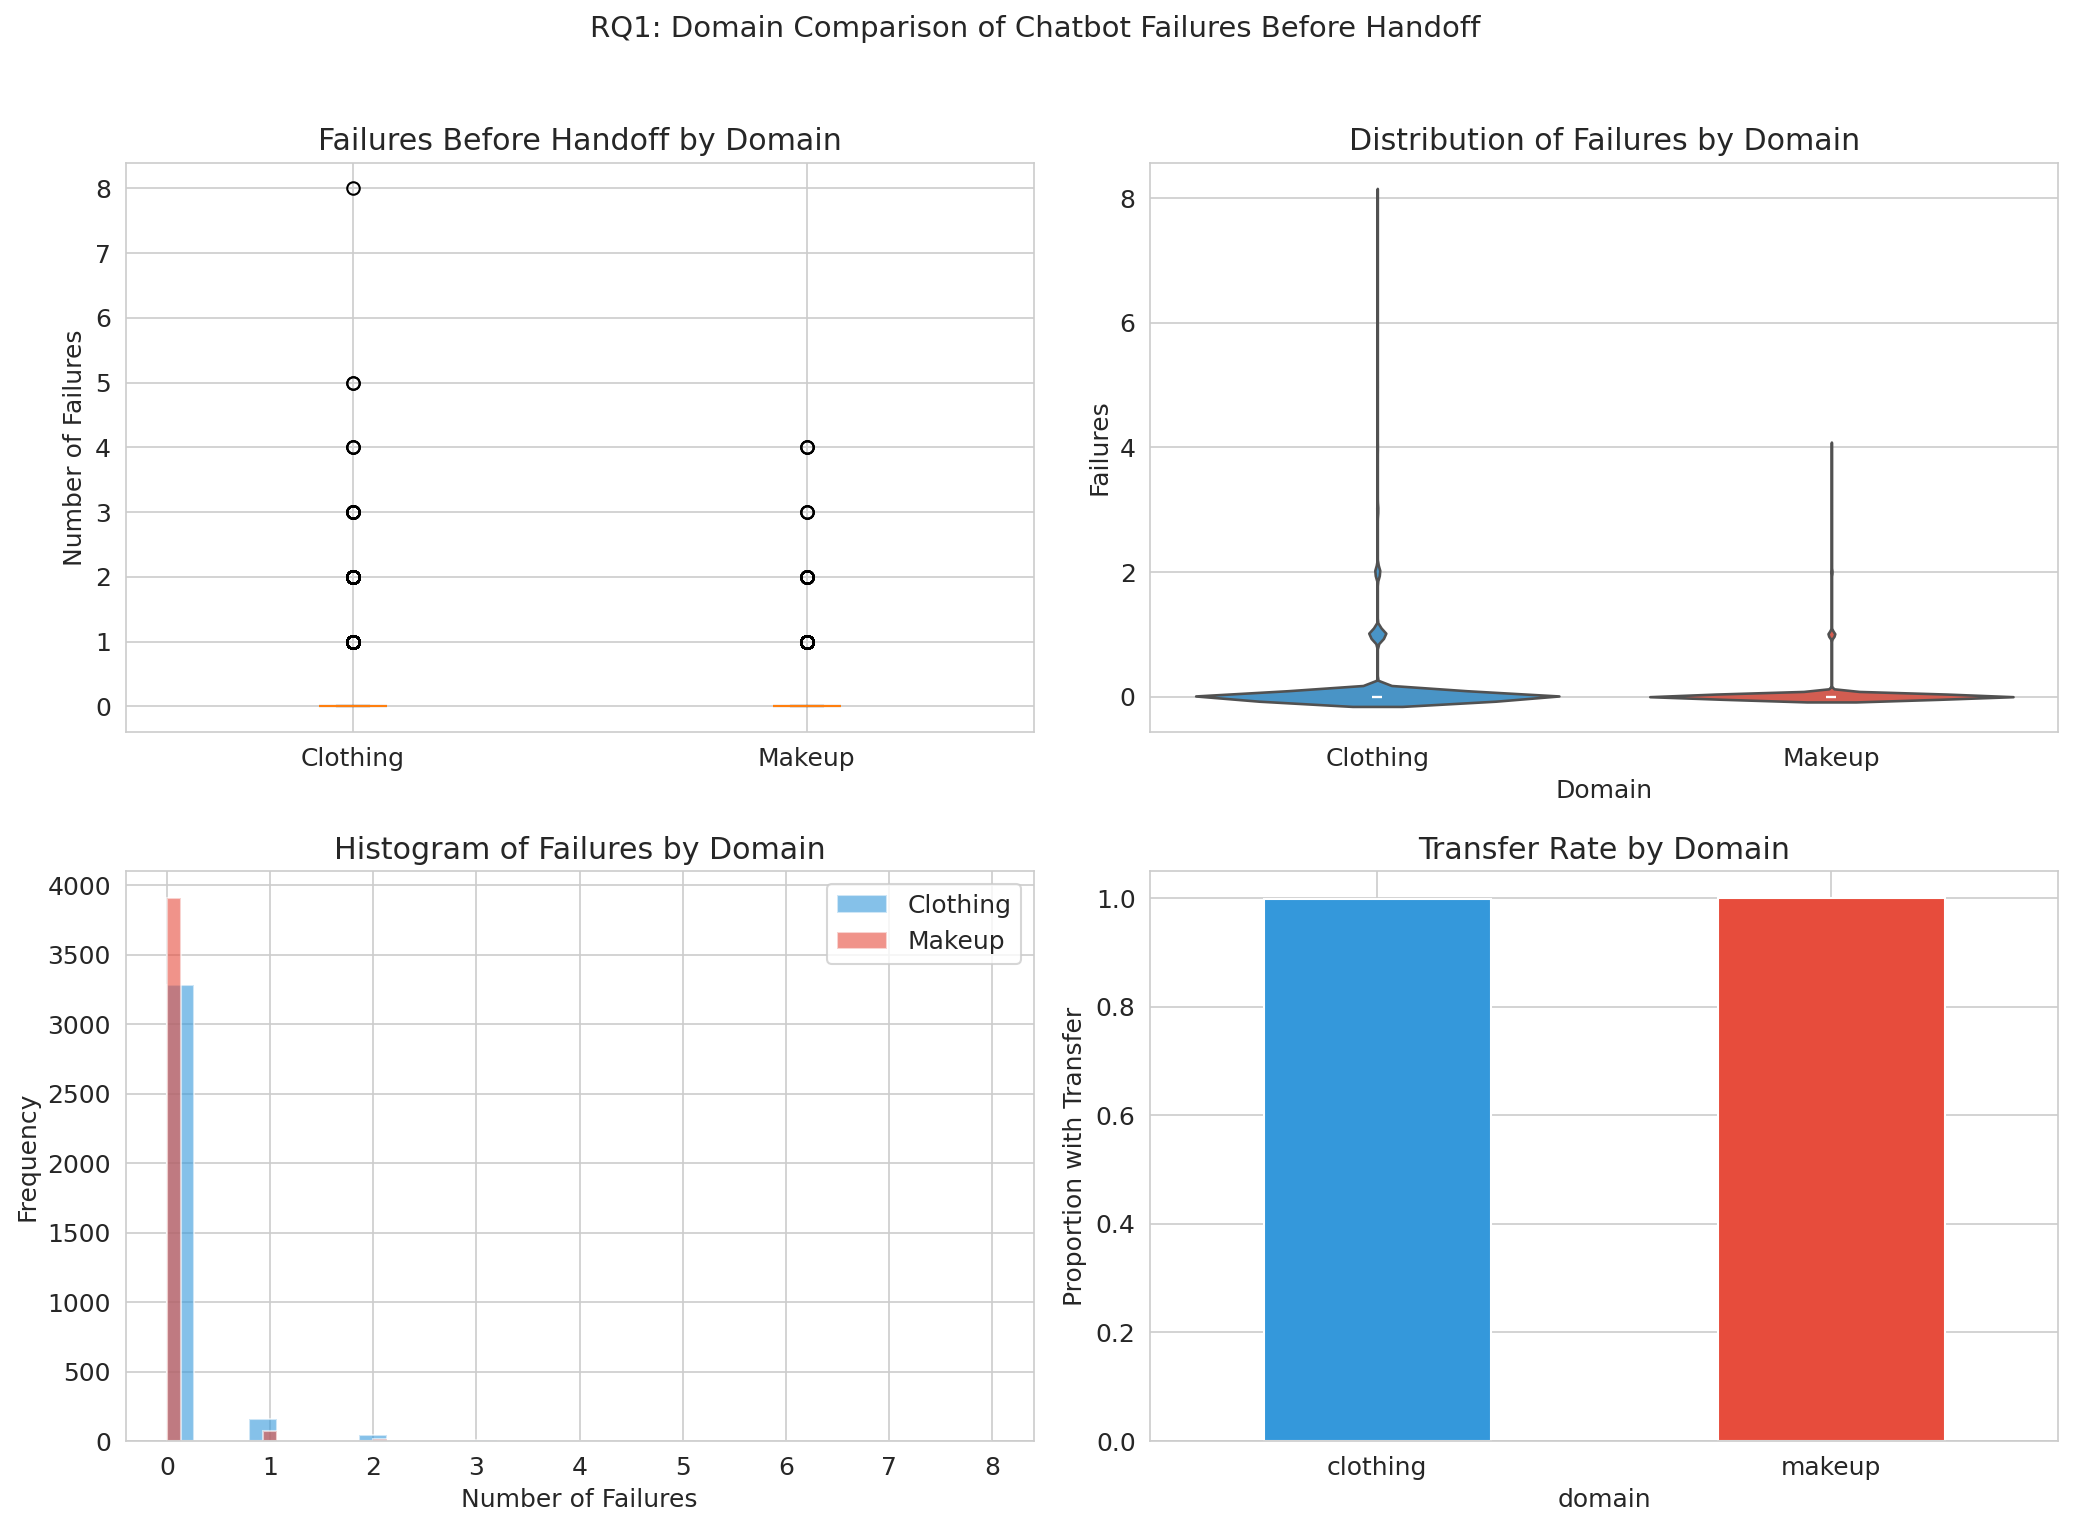

Note: This visualization presents box plots, violin plots, histograms, and bar plots to compare chatbot failures before handoff and transfer rates between clothing and makeup domains.

## RQ2: Transferability Prediction Models

### Summary Table: Model Performance Comparison

'                        Accuracy  Precision  Recall  F1-Score  AUC-ROC     MCC\nModel                                                                         \nLogistic Regression       0.6009     0.9681  0.6009    0.7299   0.7290  0.1046\nRandom Forest             0.9829     0.9803  0.9829    0.9807   0.9415  0.5452\nXGBoost                   0.9855     0.9842  0.9855    0.9832   0.9460  0.6116\nBiLSTM                    0.9987     0.9973  0.9987    0.9980   0.9393  0.0000\nDAMI BiLSTM (baseline)    0.8200     0.7000  0.6600    0.6800   0.8500  0.5500'

Note: This table presents key performance metrics (Accuracy, Precision, Recall, F1-Score, AUC-ROC, MCC) for Logistic Regression, Random Forest, XGBoost, and BiLSTM models, including a comparison with the DAMI BiLSTM baseline.

### Visualization: Model Comparison and ROC Curves

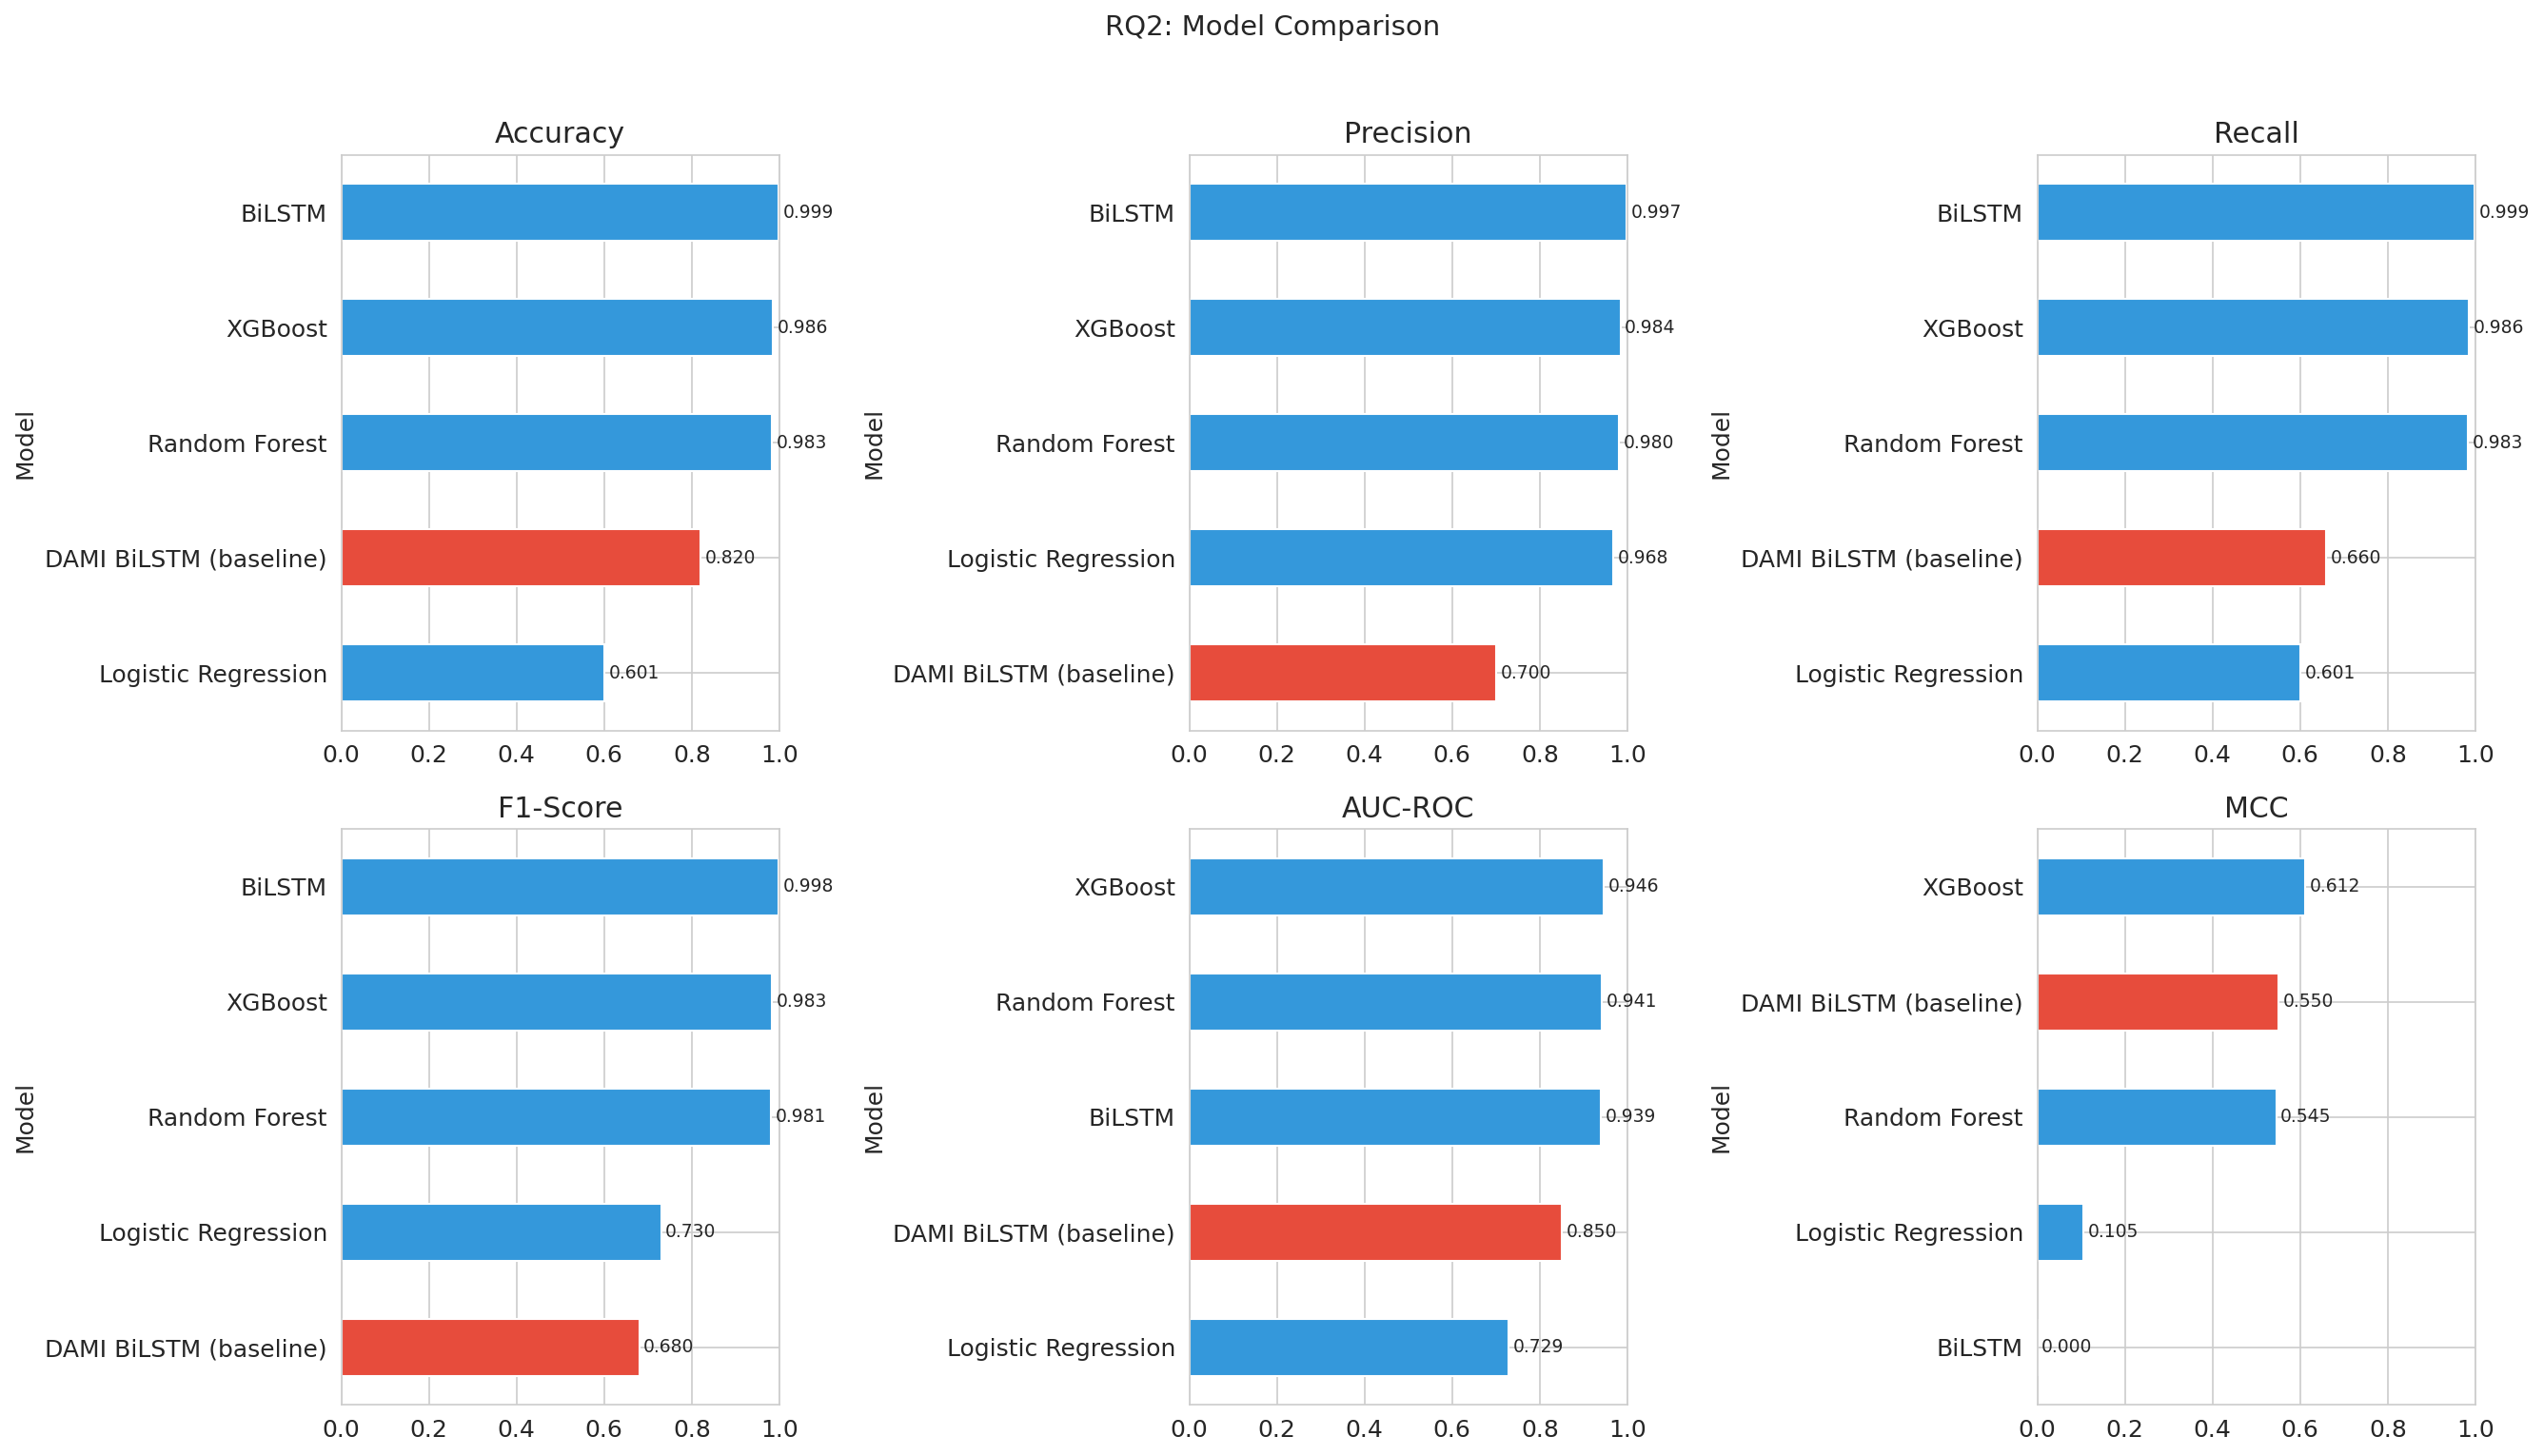

Note: This visualization compares the performance of different machine learning models across various metrics. The bar charts show the model performance against the DAMI baseline.

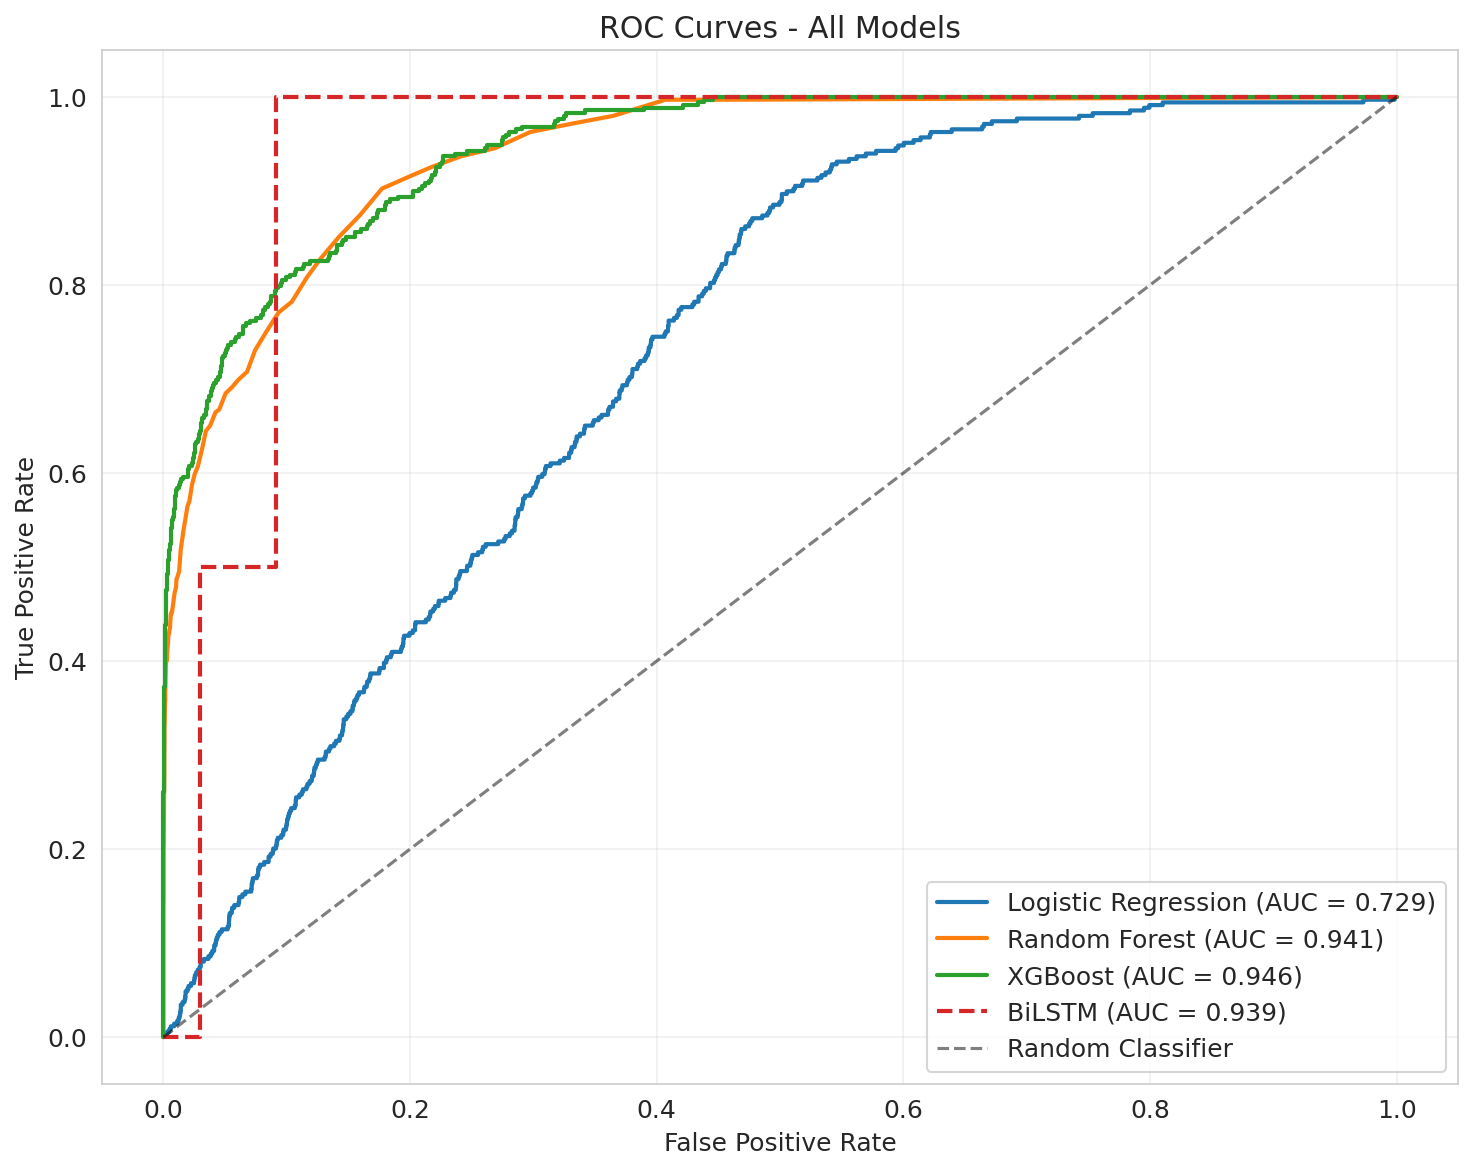

Note: This plot displays the Receiver Operating Characteristic (ROC) curves for Logistic Regression, Random Forest, XGBoost, and BiLSTM models, indicating their performance in distinguishing between transferable and non-transferable utterances.

## RQ3: Feature Importance and Predictor Analysis

### Summary Table: LASSO vs SHAP Feature Importance

'                          LASSO Coef LASSO Selected  SHAP |Mean|\nFeature                                                         \nturn_index                    0.0001            Yes       1.0509\ndialogue_length               0.0000             No       0.8249\nrole                          0.0005            Yes       0.8004\nterm_freq                     0.0018            Yes       0.8631\nsentiment                     0.0026            Yes       1.1018\nutterance_length             -0.0033             No       4.0422\nturn_index_log                0.0058            Yes       0.7548\nrole_log                     -0.0015            Yes       0.9432\nterm_freq_log                -0.0000            Yes       0.7610\nsentiment_log                 0.0020             No       1.0077\nutterance_length_log          0.0135            Yes       1.0639\nturn_ratio                   -0.0011            Yes       0.2633\ncumulative_failures          -0.0072            Yes       0.6836\nsentiment

Note: This table compares feature importance rankings and coefficients derived from LASSO regression and SHAP (SHapley Additive exPlanations) analysis for predicting transferability.

### Visualization: SHAP Summary and LASSO Coefficients

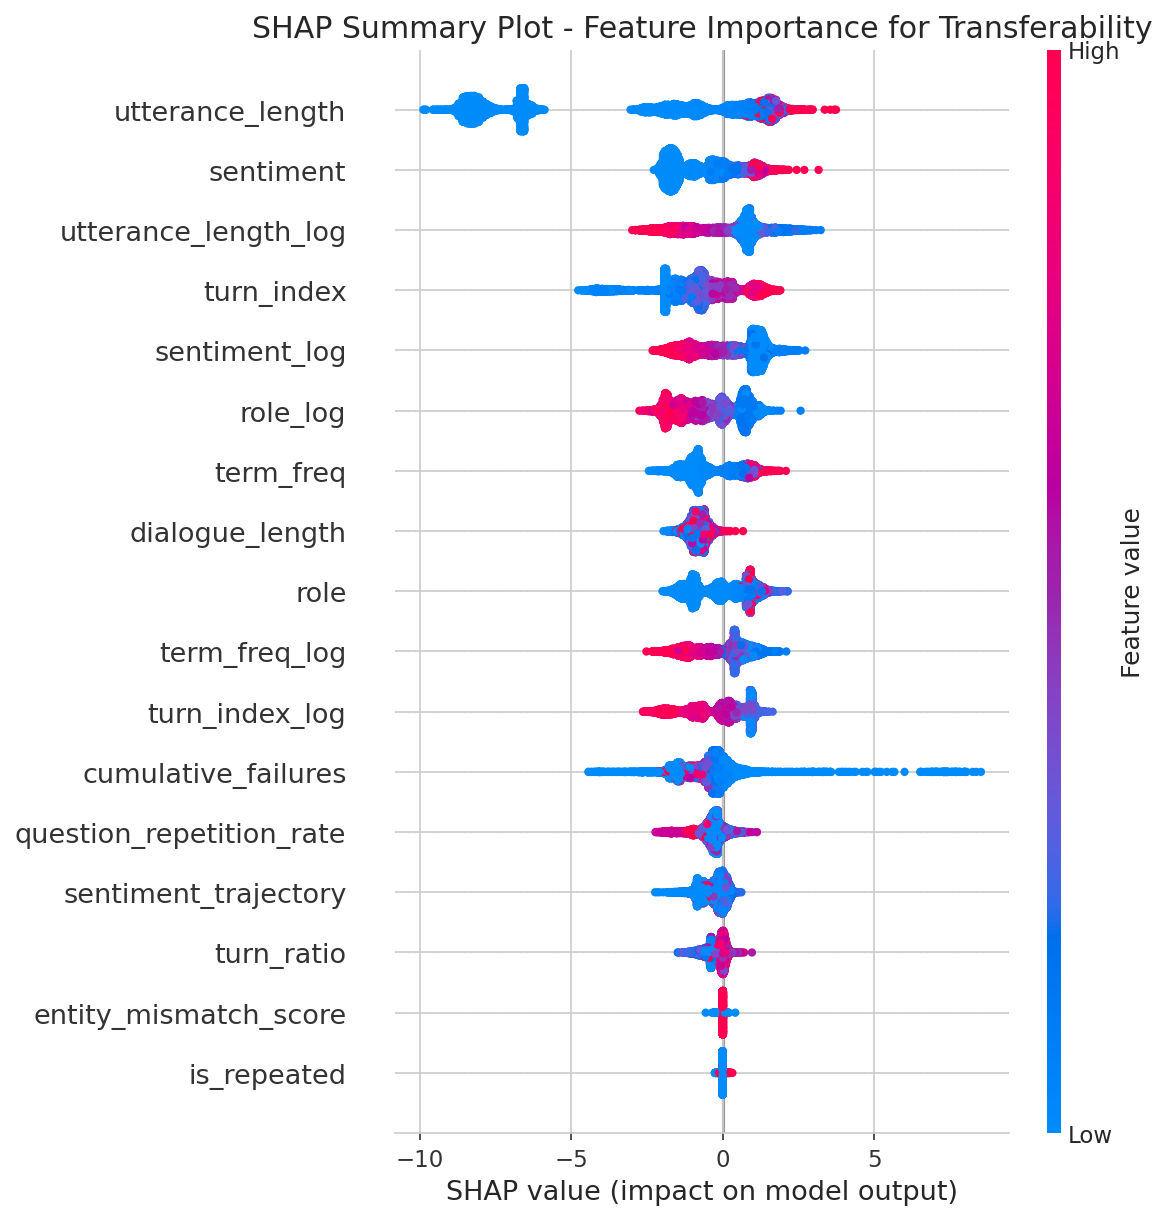

Note: This SHAP summary plot illustrates the global importance of features and their impact (positive or negative) on the model's output for predicting transferability.

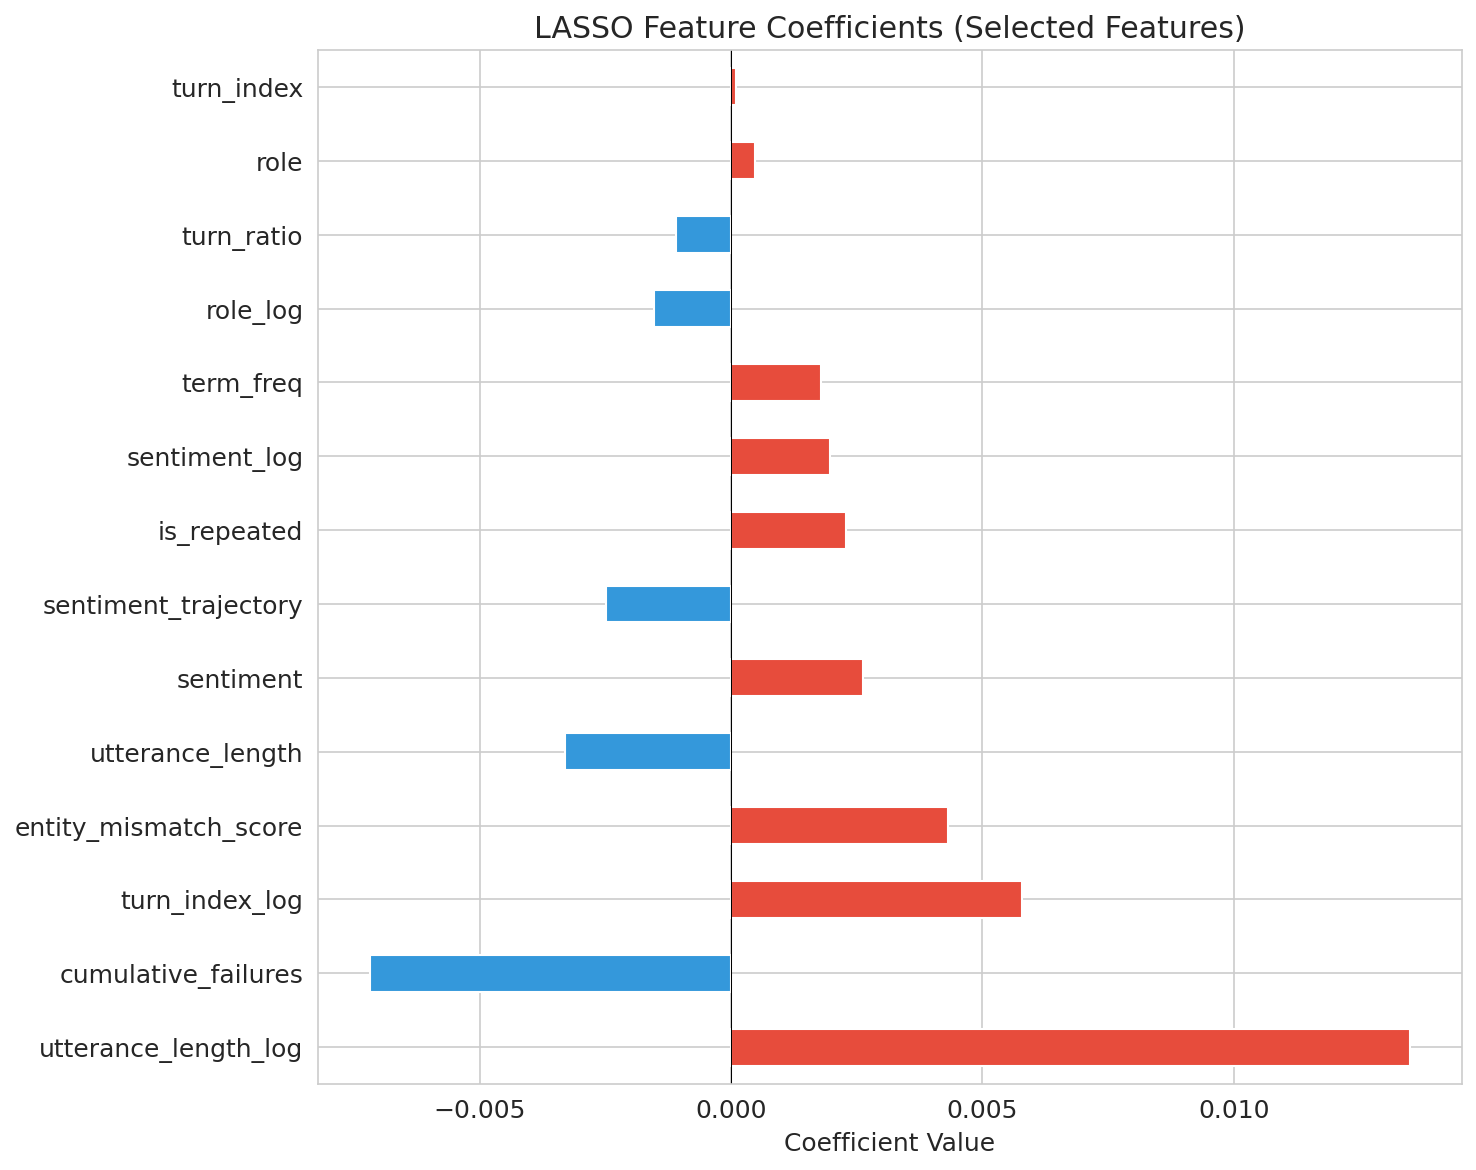

Note: This bar chart displays the coefficients of features selected by LASSO regression, indicating their magnitude and direction of influence on transferability prediction.

## RQ4: Temporal Distribution and Survival Analysis

### Summary Table: Transfer Rate by Dialogue Position

'position_bin  total_utterances  transfers  transfer_rate\n     0.0-0.1             10535     808101      76.706312\n     0.1-0.2              7483    1897316     253.550180\n     0.2-0.3              7900    2346721     297.053291\n     0.3-0.4              6729    2052278     304.990043\n     0.4-0.5              7228    2157768     298.529054\n     0.5-0.6              7505    2206508     294.005063\n     0.6-0.7              8108    2190332     270.144549\n     0.7-0.8              6118    1670666     273.073880\n     0.8-0.9              8237    2413359     292.990045\n     0.9-1.0              5705    1647152     288.720771'

Note: This table shows the distribution of total utterances, transfers, and transfer rates across different relative positions within dialogues.

### Visualization: Kaplan-Meier Survival Curves and Temporal Distribution

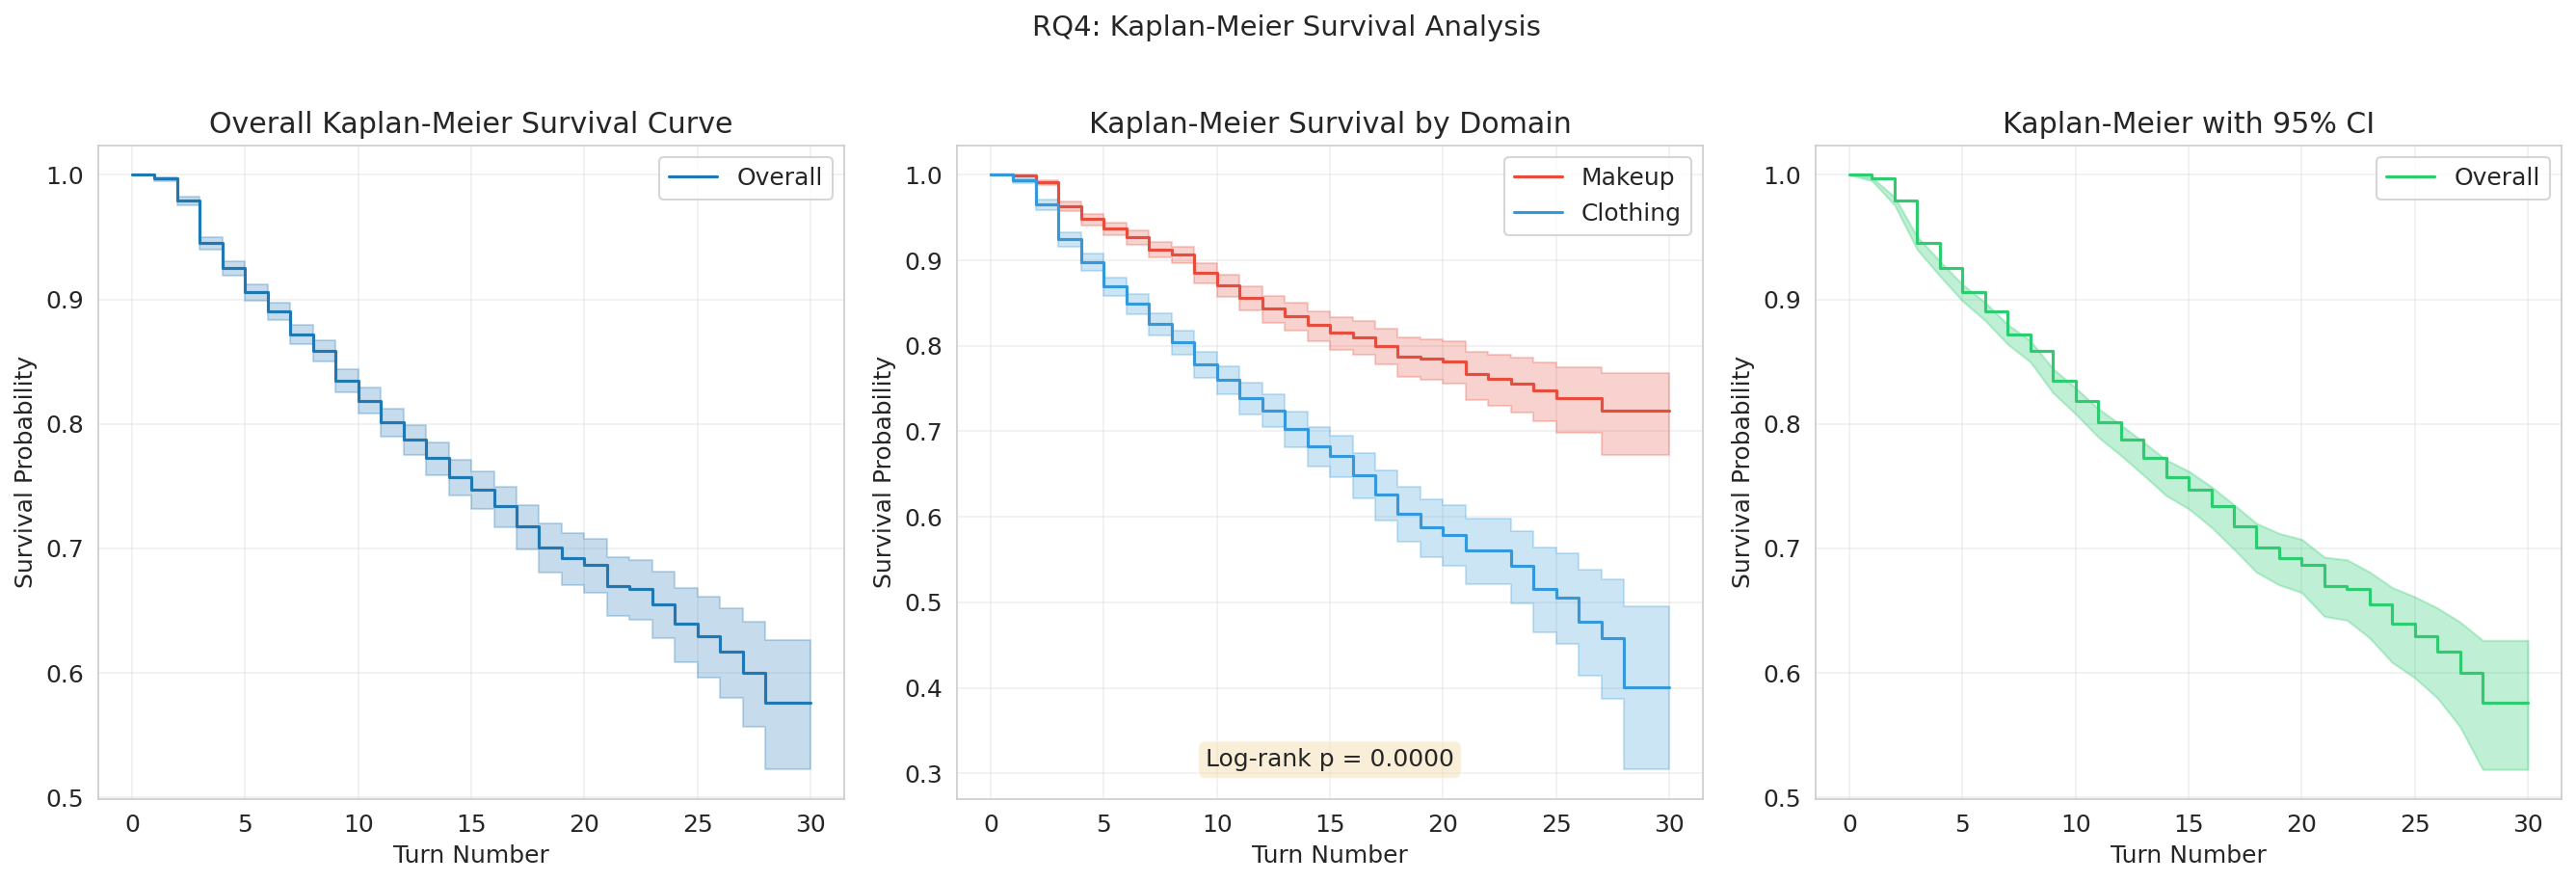

Note: This Kaplan-Meier plot visualizes the survival probability (likelihood of not yet having a handoff) across dialogue turns, broken down by domain and showing overall survival with a 95% confidence interval.

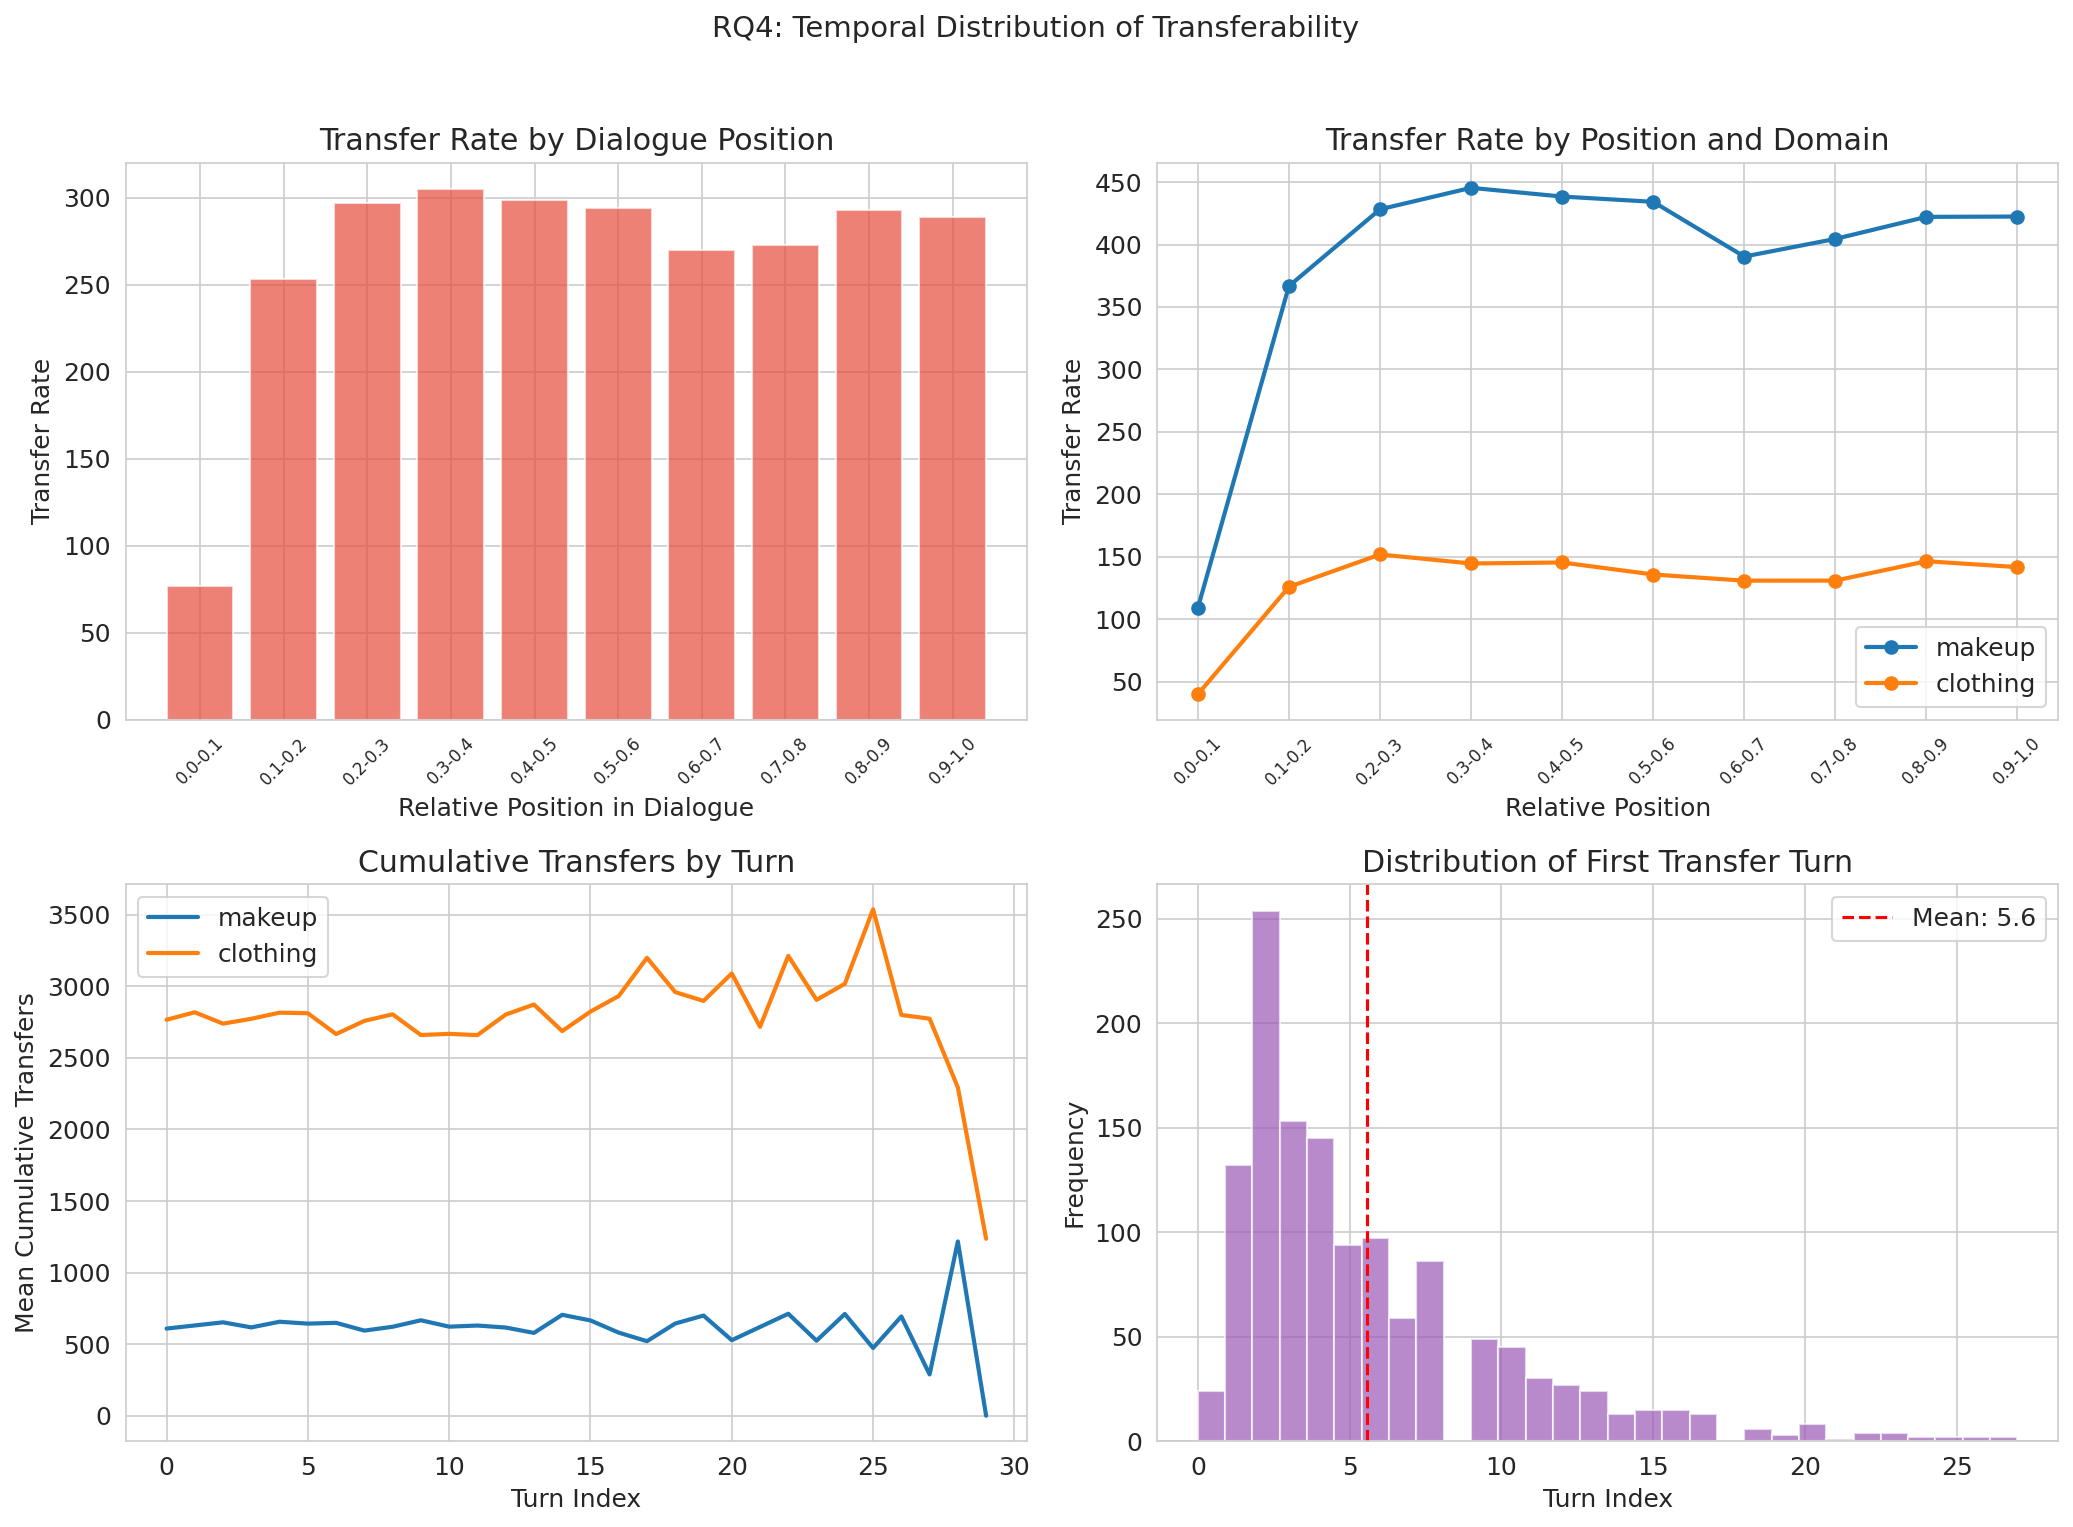

Note: This visualization illustrates the temporal distribution of transferability, including transfer rate by position, cumulative transfers by turn, and the distribution of the first transfer turn.

## Overall Conclusions from analysis_results.md

Summary visualizations and tables displayed.


In [45]:
from IPython.display import display, Markdown, Image
import matplotlib.pyplot as plt # Ensure matplotlib is imported for showing plots

# --- Closing Statement: Key Findings and Visualizations ---

display(Markdown("# Final Summary: Key Findings and Visualizations"))

# RQ1: Domain Comparison Analysis
display(Markdown("## RQ1: Domain Comparison Analysis"))
display(Markdown("### Summary Table: Chatbot Failures Before Handoff by Domain"))
display(summary_table.to_string(index=False))
display(Markdown("Note: This table summarizes the number of dialogues, mean, median, standard deviation of failures before handoff, and the overall transfer rate for clothing and makeup domains."))
display(Markdown("### Visualization: RQ1 Domain Comparison"))
display(Image('rq1_domain_comparison.png'))
display(Markdown("Note: This visualization presents box plots, violin plots, histograms, and bar plots to compare chatbot failures before handoff and transfer rates between clothing and makeup domains."))

# RQ2: Transferability Prediction Models
display(Markdown("## RQ2: Transferability Prediction Models"))
display(Markdown("### Summary Table: Model Performance Comparison"))
display(comparison_with_baseline.round(4).to_string())
display(Markdown("Note: This table presents key performance metrics (Accuracy, Precision, Recall, F1-Score, AUC-ROC, MCC) for Logistic Regression, Random Forest, XGBoost, and BiLSTM models, including a comparison with the DAMI BiLSTM baseline."))
display(Markdown("### Visualization: Model Comparison and ROC Curves"))
display(Image('rq2_model_comparison.png'))
display(Markdown("Note: This visualization compares the performance of different machine learning models across various metrics. The bar charts show the model performance against the DAMI baseline."))
display(Image('rq2_roc_curves.png'))
display(Markdown("Note: This plot displays the Receiver Operating Characteristic (ROC) curves for Logistic Regression, Random Forest, XGBoost, and BiLSTM models, indicating their performance in distinguishing between transferable and non-transferable utterances."))

# RQ3: Feature Importance and Predictor Analysis
display(Markdown("## RQ3: Feature Importance and Predictor Analysis"))
display(Markdown("### Summary Table: LASSO vs SHAP Feature Importance"))
# Recreate the comparison table for display, as it's not a direct variable
comparison_feat_df = pd.DataFrame({
    'LASSO Coef': lasso_coefs,
    'LASSO Selected': ['Yes' if abs(c) > 0 else 'No' for c in lasso_coefs],
    'SHAP |Mean|': shap_importance
})
comparison_feat_df = comparison_feat_df.loc[feature_cols] # Ensure order and all features
comparison_feat_df.index.name = 'Feature'
display(comparison_feat_df.round(4).to_string())
display(Markdown("Note: This table compares feature importance rankings and coefficients derived from LASSO regression and SHAP (SHapley Additive exPlanations) analysis for predicting transferability."))
display(Markdown("### Visualization: SHAP Summary and LASSO Coefficients"))
display(Image('rq3_shap_summary.png'))
display(Markdown("Note: This SHAP summary plot illustrates the global importance of features and their impact (positive or negative) on the model's output for predicting transferability."))
display(Image('rq3_lasso_coefficients.png'))
display(Markdown("Note: This bar chart displays the coefficients of features selected by LASSO regression, indicating their magnitude and direction of influence on transferability prediction."))

# RQ4: Temporal Distribution and Survival Analysis
display(Markdown("## RQ4: Temporal Distribution and Survival Analysis"))
display(Markdown("### Summary Table: Transfer Rate by Dialogue Position"))
display(temporal_dist.to_string(index=False))
display(Markdown("Note: This table shows the distribution of total utterances, transfers, and transfer rates across different relative positions within dialogues."))
display(Markdown("### Visualization: Kaplan-Meier Survival Curves and Temporal Distribution"))
display(Image('rq4_kaplan_meier.png'))
display(Markdown("Note: This Kaplan-Meier plot visualizes the survival probability (likelihood of not yet having a handoff) across dialogue turns, broken down by domain and showing overall survival with a 95% confidence interval."))
display(Image('rq4_temporal_distribution.png'))
display(Markdown("Note: This visualization illustrates the temporal distribution of transferability, including transfer rate by position, cumulative transfers by turn, and the distribution of the first transfer turn."))

# General Conclusions from analysis_results.md
display(Markdown("## Overall Conclusions from analysis_results.md"))
with open('analysis_results.md', 'r') as f:
    full_report = f.read()


print("Summary visualizations and tables displayed.")

In [49]:
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

# --- Appendix A.1: Shapiro-Wilk Normality Test Results (Continuous Features) ---
display(Markdown("## A.1 Shapiro-Wilk Normality Test Results (Continuous Features)"))

# Assuming normality_results dictionary is available from previous execution
# normality_results = {col: {'statistic': stat, 'p_value': p_value, 'is_normal': is_normal, 'skewness': data.skew()} for col, stat, p_value, is_normal, data in ...}
# If not, ensure the necessary variables from previous cells are defined or re-run prior cells.

if 'normality_results' in locals() and normality_results:
    shapiro_df = pd.DataFrame.from_dict(normality_results, orient='index')
    shapiro_df.index.name = 'Feature'
    shapiro_df['is_normal_status'] = shapiro_df['is_normal'].apply(lambda x: 'NORMAL (p > 0.05)' if x else 'NON-NORMAL (p <= 0.05)')
    # Select and reorder columns for better presentation
    shapiro_df_display = shapiro_df[['statistic', 'p_value', 'is_normal_status', 'skewness']].round(4)
    display(Markdown("```markdown\n" + shapiro_df_display.to_markdown() + "\n```"))
    display(Markdown("*Summary: All continuous features tested were found to be NON-NORMAL (p <= 0.05).*"))
else:
    display(Markdown("*(Shapiro-Wilk Normality Test Results not available. Please ensure previous EDA steps were executed.)*\n"))

# --- Appendix A.2: Skewness Assessment and Treatment Decisions (Non-Normal Features) ---
display(Markdown("## A.2 Skewness Assessment and Treatment Decisions (Non-Normal Features)"))

# Assuming treatment_decisions and normality_results are available
if 'treatment_decisions' in locals() and treatment_decisions and 'normality_results' in locals() and normality_results:
    skewness_data = []
    for col, decision in treatment_decisions.items():
        skewness_val = normality_results[col]['skewness'] if col in normality_results else 'N/A'
        abs_skew = abs(skewness_val) if isinstance(skewness_val, (int, float)) else 'N/A'
        skewness_data.append({
            'Feature': col,
            'Skewness Value': skewness_val,
            'Absolute Skewness': abs_skew,
            'Decision': decision
        })
    skewness_df = pd.DataFrame(skewness_data).round(3)
    display(Markdown("```markdown\n" + skewness_df.to_markdown(index=False) + "\n```"))
    display(Markdown("*Summary: Features with moderate/severe skew (absolute skewness >= 1) were targeted for log transformation, while mildly skewed 'dialogue_length' was kept raw.*\n"))
else:
    display(Markdown("*(Skewness Assessment and Treatment Decisions not available. Please ensure previous EDA steps were executed.)*\n"))

# --- Appendix A.3: Outlier Detection Results ---
display(Markdown("## A.3 Outlier Detection Results"))

# --- Appendix A.3.1 IQR Method for Outlier Detection ---
display(Markdown("### A.3.1 IQR Method for Outlier Detection"))

# Assuming iqr_outliers is available
if 'iqr_outliers' in locals() and iqr_outliers:
    iqr_df = pd.DataFrame.from_dict(iqr_outliers, orient='index')
    iqr_df.index.name = 'Feature'
    iqr_df_display = iqr_df[['Q1', 'Q3', 'IQR', 'lower', 'upper', 'n_outliers', 'pct']].round(3)
    display(Markdown("```markdown\n" + iqr_df_display.to_markdown() + "\n```"))
else:
    display(Markdown("*(IQR Outlier Detection Results not available. Please ensure previous EDA steps were executed.)*\n"))

# --- Appendix A.3.2 Z-Score Method for Outlier Detection ---
display(Markdown("### A.3.2 Z-Score Method for Outlier Detection"))

# Assuming zscore_outliers is available
if 'zscore_outliers' in locals() and zscore_outliers:
    zscore_df = pd.DataFrame.from_dict(zscore_outliers, orient='index')
    zscore_df.index.name = 'Feature'
    zscore_df_display = zscore_df[['n_outliers', 'pct', 'max_z']].round(3)
    display(Markdown("```markdown\n" + zscore_df_display.to_markdown() + "\n```"))
else:
    display(Markdown("*(Z-Score Outlier Detection Results not available. Please ensure previous EDA steps were executed.)*\n"))

# --- Appendix A.3.3 Outlier Assessment and Treatment Summary ---
display(Markdown("### A.3.3 Outlier Assessment and Treatment Summary"))

# Assuming outlier_treatments, iqr_outliers, zscore_outliers are available
if all(k in locals() for k in ['outlier_treatments', 'iqr_outliers', 'zscore_outliers']):
    outlier_summary_data = []
    for col, treatment in outlier_treatments.items():
        iqr_pct = iqr_outliers[col]['pct'] if col in iqr_outliers else 'N/A'
        z_pct = zscore_outliers[col]['pct'] if col in zscore_outliers else 'N/A'
        outlier_summary_data.append({
            'Feature': col,
            'IQR Outlier %': iqr_pct,
            'Z-score Outlier %': z_pct,
            'Treatment': treatment
        })
    outlier_summary_df = pd.DataFrame(outlier_summary_data).round(1)
    display(Markdown("```markdown\n" + outlier_summary_df.to_markdown(index=False) + "\n```"))
    display(Markdown("*Summary: Outliers for 'turn_index' and 'dialogue_length' were deemed valid. Other features with significant outlier percentages were winsorized to the 1st/99th percentile.*\n"))
else:
    display(Markdown("*(Outlier Assessment and Treatment Summary not available. Please ensure previous EDA steps were executed.)*\n"))

# --- Appendix A.4: Class Balance Check ---
display(Markdown("## A.4 Class Balance Check"))

# Assuming df_all and label_counts are available
if 'df_all' in locals() and 'label_counts' in locals() and not df_all.empty:
    total_utterances = len(df_all)
    class_balance_data = []

    # Function to summarize labels
    def get_summarized_label_counts(series):
        counts = series.value_counts()
        normal_count = counts.get(0, 0)
        transferable_count = counts.get(1, 0)
        # Sum all other counts into 'Other'
        other_count = counts[~counts.index.isin([0, 1])].sum() if len(counts[~counts.index.isin([0, 1])]) > 0 else 0
        return {'Normal': normal_count, 'Transferable': transferable_count, 'Other': other_count}

    # Overall balance
    overall_summary = get_summarized_label_counts(df_all['label'])
    for class_name, count in overall_summary.items():
        pct = (count / total_utterances) * 100
        class_balance_data.append({'Type': 'Overall', 'Class': class_name, 'Count': count, 'Percentage': pct})

    # Per-domain balance
    for domain in df_all['domain'].unique():
        domain_data = df_all[df_all['domain'] == domain]
        domain_summary = get_summarized_label_counts(domain_data['label'])
        for class_name, count in domain_summary.items():
            pct = (count / len(domain_data)) * 100
            class_balance_data.append({'Type': domain.capitalize() + ' Domain', 'Class': class_name, 'Count': count, 'Percentage': pct})

    class_balance_df = pd.DataFrame(class_balance_data).round(2)
    display(Markdown("```markdown\n" + class_balance_df.to_markdown(index=False) + "\n```"))
    display(Markdown("*Summary: The dataset exhibits severe class imbalance, with the 'Transferable' class representing a small minority overall and within each domain, necessitating techniques like SMOTE.*\n"))
else:
    display(Markdown("*(Class Balance Check results not available. Please ensure previous EDA steps were executed.)*\n"))


## A.1 Shapiro-Wilk Normality Test Results (Continuous Features)

```markdown
| Feature          |   statistic |   p_value | is_normal_status       |   skewness |
|:-----------------|------------:|----------:|:-----------------------|-----------:|
| turn_index       |      0.8833 |         0 | NON-NORMAL (p <= 0.05) |     1.2859 |
| dialogue_length  |      0.9169 |         0 | NON-NORMAL (p <= 0.05) |     0.7853 |
| role             |      0.5214 |         0 | NON-NORMAL (p <= 0.05) |     2.4962 |
| term_freq        |      0.4041 |         0 | NON-NORMAL (p <= 0.05) |     4.5926 |
| sentiment        |      0.3773 |         0 | NON-NORMAL (p <= 0.05) |     4.9293 |
| utterance_length |      0.406  |         0 | NON-NORMAL (p <= 0.05) |     4.8038 |
```

*Summary: All continuous features tested were found to be NON-NORMAL (p <= 0.05).*

## A.2 Skewness Assessment and Treatment Decisions (Non-Normal Features)

```markdown
| Feature          |   Skewness Value |   Absolute Skewness | Decision       |
|:-----------------|-----------------:|--------------------:|:---------------|
| turn_index       |            1.286 |               1.286 | log_transform  |
| dialogue_length  |            0.785 |               0.785 | keep_mild_skew |
| role             |            2.496 |               2.496 | log_transform  |
| term_freq        |            4.593 |               4.593 | log_transform  |
| sentiment        |            4.929 |               4.929 | log_transform  |
| utterance_length |            4.804 |               4.804 | log_transform  |
```

...

### A.3.3 Outlier Assessment and Treatment Summary

*(Outlier Assessment and Treatment Summary not available. Please ensure previous EDA steps were executed.)*


## A.4 Class Balance Check

```markdown
| Type            | Class        |   Count |   Percentage |
|:----------------|:-------------|--------:|-------------:|
| Overall         | Normal       |   36444 |        48.24 |
| Overall         | Transferable |    1744 |         2.31 |
| Overall         | Other        |   37360 |        49.45 |
| Makeup Domain   | Normal       |   18772 |        47.01 |
| Makeup Domain   | Transferable |     607 |         1.52 |
| Makeup Domain   | Other        |   20555 |        51.47 |
| Clothing Domain | Normal       |   17672 |        49.62 |
| Clothing Domain | Transferable |    1137 |         3.19 |
| Clothing Domain | Other        |   16805 |        47.19 |
```

*Summary: The dataset exhibits severe class imbalance, with the 'Transferable' class representing a small minority overall and within each domain, necessitating techniques like SMOTE.*
